## Menentukan Pertanyaan Bisnis

- Sebagai perencana kota <br>
bagaimana cara mengintegrasikan data historis konsentrasi PM2.5 dan PM10 dari stasiun pemantauan ke dalam sistem manajemen lalu lintas untuk membatasi volume kendaraan pada periode kuartal keempat tahun 2016 hingga kuartal pertama tahun 2017

- Sebagai manajer operasi <br>
 bagaimana cara mengukur korelasi antara variabel meteorologi dan tingkat polusi udara untuk mengalihkan rute pengiriman selama jam operasional pada pukul 06.00 hingga 22.00

- Sebagai aktuaris asuransi kesehatan <br>
menganalisis fluktuasi senyawa SO2 dan NO2 dari kumpulan data untuk memodelkan potensi lonjakan klaim penyakit pernapasan selama musim dingin dan merancang struktur premi berdasarkan lokasi pemukiman nasabah?

## Import Semua Packages/Library yang Digunakan

In [1]:
import os
import warnings
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import folium
import statsmodels.api as sm
import streamlit as st
from scipy import stats

from scipy.stats import shapiro, f_oneway
from folium.plugins import HeatMap

## Data Wrangling


### Gathering Data
* Read in all the CSV files. Each file is named with the format:
* `PRSA_Data_<NamaStasiun>_20130301-20170228.csv`
* Read in data for each station and print out the first few rows

In [2]:
Aotizhongxin = pd.read_csv('source/dirty/PRSA_Data_Aotizhongxin_20130301-20170228.csv')
Aotizhongxin.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin


In [3]:
Changping = pd.read_csv('source/dirty/PRSA_Data_Changping_20130301-20170228.csv')
Changping.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,3.0,6.0,13.0,7.0,300.0,85.0,-2.3,1020.8,-19.7,0.0,E,0.5,Changping
1,2,2013,3,1,1,3.0,3.0,6.0,6.0,300.0,85.0,-2.5,1021.3,-19.0,0.0,ENE,0.7,Changping
2,3,2013,3,1,2,3.0,3.0,22.0,13.0,400.0,74.0,-3.0,1021.3,-19.9,0.0,ENE,0.2,Changping
3,4,2013,3,1,3,3.0,6.0,12.0,8.0,300.0,81.0,-3.6,1021.8,-19.1,0.0,NNE,1.0,Changping
4,5,2013,3,1,4,3.0,3.0,14.0,8.0,300.0,81.0,-3.5,1022.3,-19.4,0.0,N,2.1,Changping


In [4]:
Dingling = pd.read_csv('source/dirty/PRSA_Data_Dingling_20130301-20170228.csv')
Dingling.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,3.0,NaN,200.0,82.0,-2.3,1020.8,-19.7,0.0,E,0.5,Dingling
1,2,2013,3,1,1,7.0,7.0,3.0,NaN,200.0,80.0,-2.5,1021.3,-19.0,0.0,ENE,0.7,Dingling
2,3,2013,3,1,2,5.0,5.0,3.0,2.0,200.0,79.0,-3.0,1021.3,-19.9,0.0,ENE,0.2,Dingling
3,4,2013,3,1,3,6.0,6.0,3.0,NaN,200.0,79.0,-3.6,1021.8,-19.1,0.0,NNE,1.0,Dingling
4,5,2013,3,1,4,5.0,5.0,3.0,NaN,200.0,81.0,-3.5,1022.3,-19.4,0.0,N,2.1,Dingling


In [5]:
Dongsi = pd.read_csv('source/dirty/PRSA_Data_Dongsi_20130301-20170228.csv')
Dongsi.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,9.0,9.0,3.0,17.0,300.0,89.0,-0.5,1024.5,-21.4,0.0,NNW,5.7,Dongsi
1,2,2013,3,1,1,4.0,4.0,3.0,16.0,300.0,88.0,-0.7,1025.1,-22.1,0.0,NW,3.9,Dongsi
2,3,2013,3,1,2,7.0,7.0,NaN,17.0,300.0,60.0,-1.2,1025.3,-24.6,0.0,NNW,5.3,Dongsi
3,4,2013,3,1,3,3.0,3.0,5.0,18.0,NaN,NaN,-1.4,1026.2,-25.5,0.0,N,4.9,Dongsi
4,5,2013,3,1,4,3.0,3.0,7.0,NaN,200.0,84.0,-1.9,1027.1,-24.5,0.0,NNW,3.2,Dongsi


In [6]:
Guanyuan = pd.read_csv('source/dirty/PRSA_Data_Guanyuan_20130301-20170228.csv')
Guanyuan.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,14.0,20.0,300.0,69.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Guanyuan
1,2,2013,3,1,1,4.0,4.0,13.0,17.0,300.0,72.0,-1.1,1023.2,-18.2,0.0,N,4.7,Guanyuan
2,3,2013,3,1,2,3.0,3.0,10.0,19.0,300.0,69.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Guanyuan
3,4,2013,3,1,3,3.0,6.0,7.0,24.0,400.0,62.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Guanyuan
4,5,2013,3,1,4,3.0,6.0,5.0,14.0,400.0,71.0,-2.0,1025.2,-19.5,0.0,N,2.0,Guanyuan


In [7]:

Gucheng = pd.read_csv('source/dirty/PRSA_Data_Gucheng_20130301-20170228.csv')
Gucheng.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,6.0,18.0,5.0,NaN,800.0,88.0,0.1,1021.1,-18.6,0.0,NW,4.4,Gucheng
1,2,2013,3,1,1,6.0,15.0,5.0,NaN,800.0,88.0,-0.3,1021.5,-19.0,0.0,NW,4.0,Gucheng
2,3,2013,3,1,2,5.0,18.0,NaN,NaN,700.0,52.0,-0.7,1021.5,-19.8,0.0,WNW,4.6,Gucheng
3,4,2013,3,1,3,6.0,20.0,6.0,NaN,NaN,NaN,-1.0,1022.7,-21.2,0.0,W,2.8,Gucheng
4,5,2013,3,1,4,5.0,17.0,5.0,NaN,600.0,73.0,-1.3,1023.0,-21.4,0.0,WNW,3.6,Gucheng


In [8]:
Huairou = pd.read_csv('source/dirty/PRSA_Data_Huairou_20130301-20170228.csv')
Huairou.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,7.0,7.0,3.0,2.0,100.0,91.0,-2.3,1020.3,-20.7,0.0,WNW,3.1,Huairou
1,2,2013,3,1,1,4.0,4.0,3.0,NaN,100.0,92.0,-2.7,1020.8,-20.5,0.0,NNW,1.5,Huairou
2,3,2013,3,1,2,4.0,4.0,NaN,NaN,100.0,91.0,-3.2,1020.6,-21.4,0.0,NW,1.8,Huairou
3,4,2013,3,1,3,3.0,3.0,3.0,2.0,NaN,NaN,-3.3,1021.3,-23.7,0.0,NNW,2.4,Huairou
4,5,2013,3,1,4,3.0,3.0,7.0,NaN,300.0,86.0,-4.1,1022.1,-22.7,0.0,NNW,2.2,Huairou


In [9]:
Nongzhanguan = pd.read_csv('source/dirty/PRSA_Data_Nongzhanguan_20130301-20170228.csv')
Nongzhanguan.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,5.0,14.0,4.0,12.0,200.0,85.0,-0.5,1024.5,-21.4,0.0,NNW,5.7,Nongzhanguan
1,2,2013,3,1,1,8.0,12.0,6.0,14.0,200.0,84.0,-0.7,1025.1,-22.1,0.0,NW,3.9,Nongzhanguan
2,3,2013,3,1,2,3.0,6.0,5.0,14.0,200.0,83.0,-1.2,1025.3,-24.6,0.0,NNW,5.3,Nongzhanguan
3,4,2013,3,1,3,5.0,5.0,5.0,14.0,200.0,84.0,-1.4,1026.2,-25.5,0.0,N,4.9,Nongzhanguan
4,5,2013,3,1,4,5.0,5.0,6.0,21.0,200.0,77.0,-1.9,1027.1,-24.5,0.0,NNW,3.2,Nongzhanguan


In [10]:
Shunyi = pd.read_csv('source/dirty/PRSA_Data_Shunyi_20130301-20170228.csv')
Shunyi.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,3.0,6.0,3.0,8.0,300.0,44.0,-0.9,1025.8,-20.5,0.0,NW,9.3,Shunyi
1,2,2013,3,1,1,12.0,12.0,3.0,7.0,300.0,47.0,-1.1,1026.1,-21.3,0.0,NW,9.4,Shunyi
2,3,2013,3,1,2,14.0,14.0,NaN,7.0,200.0,22.0,-1.7,1026.2,-23.0,0.0,NW,8.6,Shunyi
3,4,2013,3,1,3,12.0,12.0,3.0,5.0,NaN,NaN,-2.1,1027.3,-23.3,0.0,NW,6.6,Shunyi
4,5,2013,3,1,4,12.0,12.0,3.0,NaN,200.0,11.0,-2.4,1027.7,-22.9,0.0,NW,4.5,Shunyi


In [11]:
Tiantan = pd.read_csv('source/dirty/PRSA_Data_Tiantan_20130301-20170228.csv')
Tiantan.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,6.0,6.0,4.0,8.0,300.0,81.0,-0.5,1024.5,-21.4,0.0,NNW,5.7,Tiantan
1,2,2013,3,1,1,6.0,29.0,5.0,9.0,300.0,80.0,-0.7,1025.1,-22.1,0.0,NW,3.9,Tiantan
2,3,2013,3,1,2,6.0,6.0,4.0,12.0,300.0,75.0,-1.2,1025.3,-24.6,0.0,NNW,5.3,Tiantan
3,4,2013,3,1,3,6.0,6.0,4.0,12.0,300.0,74.0,-1.4,1026.2,-25.5,0.0,N,4.9,Tiantan
4,5,2013,3,1,4,5.0,5.0,7.0,15.0,400.0,70.0,-1.9,1027.1,-24.5,0.0,NNW,3.2,Tiantan


In [12]:
Wanliu = pd.read_csv('source/dirty/PRSA_Data_Wanliu_20130301-20170228.csv')
Wanliu.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,8.0,8.0,6.0,28.0,400.0,52.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Wanliu
1,2,2013,3,1,1,9.0,9.0,6.0,28.0,400.0,50.0,-1.1,1023.2,-18.2,0.0,N,4.7,Wanliu
2,3,2013,3,1,2,3.0,6.0,NaN,19.0,400.0,55.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Wanliu
3,4,2013,3,1,3,11.0,30.0,8.0,14.0,NaN,NaN,-1.4,1024.5,-19.4,0.0,NW,3.1,Wanliu
4,5,2013,3,1,4,3.0,13.0,9.0,NaN,300.0,54.0,-2.0,1025.2,-19.5,0.0,N,2.0,Wanliu


In [13]:
Wanshouxigong = pd.read_csv('source/dirty/PRSA_Data_Wanshouxigong_20130301-20170228.csv')
Wanshouxigong.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,9.0,9.0,6.0,17.0,200.0,62.0,0.3,1021.9,-19.0,0.0,WNW,2.0,Wanshouxigong
1,2,2013,3,1,1,11.0,11.0,7.0,14.0,200.0,66.0,-0.1,1022.4,-19.3,0.0,WNW,4.4,Wanshouxigong
2,3,2013,3,1,2,8.0,8.0,NaN,16.0,200.0,59.0,-0.6,1022.6,-19.7,0.0,WNW,4.7,Wanshouxigong
3,4,2013,3,1,3,8.0,8.0,3.0,16.0,NaN,NaN,-0.7,1023.5,-20.9,0.0,NW,2.6,Wanshouxigong
4,5,2013,3,1,4,8.0,8.0,3.0,NaN,300.0,36.0,-0.9,1024.1,-21.7,0.0,WNW,2.5,Wanshouxigong


Insight:
| No | Nama Stasiun       |
|----|--------------------|
| 1  | Aotizhongxin       |
| 2  | Changping          |
| 3  | Dingling           |
| 4  | Dongsi | 
| 5  | Guanyuan           |
| 6  | Gucheng|
| 7  | Huairou|
| 8  | Nongzhanguan       |
| 9  | Shunyi |
| 10 | Tiantan|
| 11 | Wanliu |
| 12 | Wanshouxigong      |

Struktur Kolom (18 Variabel)

- Variabel Waktu (5 kolom)

| Kolom   | Tipe    | Deskripsi         |
|---------|---------|-------------------|
| `No`    | Integer | Nomor urut baris  |
| `year`  | Integer | Tahun pengukuran  |
| `month` | Integer | Bulan pengukuran  |
| `day`   | Integer | Hari pengukuran   |
| `hour`  | Integer | Jam pengukuran    |

- Variabel Polutan Udara (6 kolom)

| Kolom    | Tipe | Deskripsi| Satuan  |
|----------|------|----------------------------------|---------|
| `PM2.5`  | Real | Konsentrasi partikel halus PM2.5 | µg/m³   |
| `PM10`   | Real | Konsentrasi partikel PM10        | µg/m³   |
| `SO2`    | Real | Sulfur Dioksida      |  µg/m³  |
| `NO2`    | Real | Nitrogen Dioksida    | µg/m³   |
| `CO`     | Real | Karbon Monoksida     | µg/m³   |
| `O3`     | Real | Ozon     | µg/m³   |

- Variabel Meteorologi (6 kolom)

| Kolom   | Tipe    | Deskripsi       | Satuan |
|---------|---------|-----------------------------|--------|
| `TEMP`  | Real    | Suhu udara      | °C     |
| `PRES`  | Real    | Tekanan udara   | hPa    |
| `DEWP`  | Real    | Titik embun (dew point)     | °C     |
| `RAIN`  | Real    | Curah hujan     | mm     |
| `wd`    | String  | Arah angin      | —      |
| `WSPM`  | Real    | Kecepatan angin | m/s    |


- Variabel Identitas 

| Kolom     | Tipe   | Deskripsi      |
|-----------|--------|----------------------------------------|
| `station` | String | Nama stasiun pemantauan kualitas udara |


### Assessing Data

In [14]:
# Mengecek jumlah data yang hilang (NaN) di setiap stasiun pemantauan
print ("=== Jumlah data yang hilang di Aotizhongxin ===")
Aotizhongxin.isna().sum()

=== Jumlah data yang hilang di Aotizhongxin ===


No            0
year          0
month         0
day           0
hour          0
PM2.5       925
PM10        718
SO2         935
NO2        1023
CO         1776
O3         1719
TEMP         20
PRES         20
DEWP         20
RAIN         20
wd           81
WSPM         14
station       0
dtype: int64

In [15]:
# Mengecek jumlah data yang duplikat di setiap stasiun pemantauan
print ("=== Jumlah data yang duplikat di Aotizhongxin ===")
Aotizhongxin.duplicated().sum()

=== Jumlah data yang duplikat di Aotizhongxin ===


np.int64(0)

In [16]:
# Mengecek jumlah data yang hilang (NaN) di setiap stasiun pemantauan
print ("=== Jumlah data yang hilang di Changping ===")
Changping.isna().sum()

=== Jumlah data yang hilang di Changping ===


No            0
year          0
month         0
day           0
hour          0
PM2.5       774
PM10        582
SO2         628
NO2         667
CO         1521
O3          604
TEMP         53
PRES         50
DEWP         53
RAIN         51
wd          140
WSPM         43
station       0
dtype: int64

In [17]:
# Mengecek jumlah data yang duplikat di setiap stasiun pemantauan
print ("=== Jumlah data yang duplikat di Changping ===")
Changping.duplicated().sum()

=== Jumlah data yang duplikat di Changping ===


np.int64(0)

In [18]:
# Mengecek jumlah data yang hilang (NaN) di setiap stasiun pemantauan
print ("=== Jumlah data yang hilang di Dingling ===")
Dingling.isna().sum()

=== Jumlah data yang hilang di Dingling ===


No            0
year          0
month         0
day           0
hour          0
PM2.5       779
PM10        656
SO2         730
NO2        1234
CO         2012
O3         1214
TEMP         53
PRES         50
DEWP         53
RAIN         51
wd          140
WSPM         43
station       0
dtype: int64

In [19]:
# Mengecek jumlah data yang duplikat di setiap stasiun pemantauan
print ("=== Jumlah data yang duplikat di Dingling ===")
Dingling.duplicated().sum()

=== Jumlah data yang duplikat di Dingling ===


np.int64(0)

In [20]:
# Mengecek jumlah data yang hilang (NaN) di setiap stasiun pemantauan
print ("=== Jumlah data yang hilang di Dongsi ===")
Dongsi.isna().sum()

=== Jumlah data yang hilang di Dongsi ===


No            0
year          0
month         0
day           0
hour          0
PM2.5       750
PM10        553
SO2         663
NO2        1601
CO         3197
O3          664
TEMP         20
PRES         20
DEWP         20
RAIN         20
wd           78
WSPM         14
station       0
dtype: int64

In [21]:
# Mengecek jumlah data yang duplikat di setiap stasiun pemantauan
print ("=== Jumlah data yang duplikat di Dongsi ===")
Dongsi.duplicated().sum()

=== Jumlah data yang duplikat di Dongsi ===


np.int64(0)

In [22]:
# Mengecek jumlah data yang hilang (NaN) di setiap stasiun pemantauan
print ("=== Jumlah data yang hilang di Guanyuan ===")
Guanyuan.isna().sum()

=== Jumlah data yang hilang di Guanyuan ===


No            0
year          0
month         0
day           0
hour          0
PM2.5       616
PM10        429
SO2         474
NO2         659
CO         1753
O3         1173
TEMP         20
PRES         20
DEWP         20
RAIN         20
wd           81
WSPM         14
station       0
dtype: int64

In [23]:
# Mengecek jumlah data yang hilang (NaN) di setiap stasiun pemantauan
print ("=== Jumlah data yang hilang di Guanyuan ===")
Guanyuan.isna().sum()

=== Jumlah data yang hilang di Guanyuan ===


No            0
year          0
month         0
day           0
hour          0
PM2.5       616
PM10        429
SO2         474
NO2         659
CO         1753
O3         1173
TEMP         20
PRES         20
DEWP         20
RAIN         20
wd           81
WSPM         14
station       0
dtype: int64

In [24]:
# Mengecek jumlah data yang hilang (NaN) di setiap stasiun pemantauan
print ("=== Jumlah data yang hilang di Gucheng ===")
Gucheng.isna().sum()

=== Jumlah data yang hilang di Gucheng ===


No            0
year          0
month         0
day           0
hour          0
PM2.5       646
PM10        381
SO2         507
NO2         668
CO         1401
O3          729
TEMP         51
PRES         50
DEWP         51
RAIN         43
wd          159
WSPM         42
station       0
dtype: int64

In [25]:
# Mengecek jumlah data yang duplikat di setiap stasiun pemantauan
print ("=== Jumlah data yang duplikat di Gucheng ===")
Gucheng.duplicated().sum()

=== Jumlah data yang duplikat di Gucheng ===


np.int64(0)

In [26]:
# Mengecek jumlah data yang hilang (NaN) di setiap stasiun pemantauan
print ("=== Jumlah data yang hilang di Huairou ===")
Huairou.isna().sum()

=== Jumlah data yang hilang di Huairou ===


No            0
year          0
month         0
day           0
hour          0
PM2.5       953
PM10        777
SO2         980
NO2        1639
CO         1422
O3         1151
TEMP         51
PRES         53
DEWP         53
RAIN         55
wd          302
WSPM         49
station       0
dtype: int64

In [27]:
# Mengecek jumlah data yang duplikat di setiap stasiun pemantauan
print ("=== Jumlah data yang duplikat di Huairou ===")
Huairou.duplicated().sum()

=== Jumlah data yang duplikat di Huairou ===


np.int64(0)

In [28]:
# Mengecek jumlah data yang hilang (NaN) di setiap stasiun pemantauan
print ("=== Jumlah data yang hilang di Nongzhanguan ===")
Nongzhanguan.isna().sum()

=== Jumlah data yang hilang di Nongzhanguan ===


No            0
year          0
month         0
day           0
hour          0
PM2.5       628
PM10        440
SO2         446
NO2         692
CO         1206
O3          506
TEMP         20
PRES         20
DEWP         20
RAIN         20
wd           78
WSPM         14
station       0
dtype: int64

In [29]:
# Mengecek jumlah data yang duplikat di setiap stasiun pemantauan
print ("=== Jumlah data yang duplikat di Nongzhanguan ===")
Nongzhanguan.duplicated().sum()

=== Jumlah data yang duplikat di Nongzhanguan ===


np.int64(0)

In [30]:
# Mengecek jumlah data yang hilang (NaN) di setiap stasiun pemantauan
print ("=== Jumlah data yang hilang di Shunyi ===")
Shunyi.isna().sum()

=== Jumlah data yang hilang di Shunyi ===


No            0
year          0
month         0
day           0
hour          0
PM2.5       913
PM10        548
SO2        1296
NO2        1365
CO         2178
O3         1489
TEMP         51
PRES         51
DEWP         54
RAIN         51
wd          483
WSPM         44
station       0
dtype: int64

In [31]:
# Mengecek jumlah data yang duplikat di setiap stasiun pemantauan
print ("=== Jumlah data yang duplikat di Shunyi ===")
Shunyi.duplicated().sum()

=== Jumlah data yang duplikat di Shunyi ===


np.int64(0)

In [32]:
# Mengecek jumlah data yang hilang (NaN) di setiap stasiun pemantauan
print ("=== Jumlah data yang hilang di Tiantan ===")  
Tiantan.isna().sum()

=== Jumlah data yang hilang di Tiantan ===


No            0
year          0
month         0
day           0
hour          0
PM2.5       677
PM10        597
SO2        1118
NO2         744
CO         1126
O3          843
TEMP         20
PRES         20
DEWP         20
RAIN         20
wd           78
WSPM         14
station       0
dtype: int64

In [33]:
# Mengecek jumlah data yang duplikat di setiap stasiun pemantauan
print ("=== Jumlah data yang duplikat di Tiantan ===")
Tiantan.duplicated().sum()

=== Jumlah data yang duplikat di Tiantan ===


np.int64(0)

In [34]:
# Mengecek jumlah data yang hilang (NaN) di setiap stasiun pemantauan
print ("=== Jumlah data yang hilang di Wanliu ===")
Wanliu.isna().sum()

=== Jumlah data yang hilang di Wanliu ===


No            0
year          0
month         0
day           0
hour          0
PM2.5       382
PM10        284
SO2         575
NO2        1070
CO         1812
O3         2107
TEMP         20
PRES         20
DEWP         20
RAIN         20
wd          123
WSPM         14
station       0
dtype: int64

In [35]:
# Mengecek jumlah data yang hilang (NaN) di setiap stasiun pemantauan
print ("=== Jumlah data yang hilang di Wanliu ===")
Wanliu.isna().sum()

=== Jumlah data yang hilang di Wanliu ===


No            0
year          0
month         0
day           0
hour          0
PM2.5       382
PM10        284
SO2         575
NO2        1070
CO         1812
O3         2107
TEMP         20
PRES         20
DEWP         20
RAIN         20
wd          123
WSPM         14
station       0
dtype: int64

In [36]:
# Mengecek jumlah data yang hilang (NaN) di setiap stasiun pemantauan
print ("=== Jumlah data yang hilang di Wanshouxigong ===")
Wanshouxigong.isna().sum()

=== Jumlah data yang hilang di Wanshouxigong ===


No            0
year          0
month         0
day           0
hour          0
PM2.5       696
PM10        484
SO2         669
NO2         754
CO         1297
O3         1078
TEMP         19
PRES         19
DEWP         19
RAIN         19
wd           79
WSPM         13
station       0
dtype: int64

In [37]:
# Mengecek jumlah data yang duplikat di setiap stasiun pemantauan
print ("=== Jumlah data yang duplikat di Wanshouxigong ===")
Wanshouxigong.duplicated().sum()

=== Jumlah data yang duplikat di Wanshouxigong ===


np.int64(0)

Insight: <br>
1. Missing Values per Stasiun

Tabel berikut merangkum jumlah data kosong (`NaN`) pada setiap kolom di masing-masing stasiun pemantauan.

| Stasiun          | PM2.5 | PM10 | SO2  | NO2  | CO   | O3   | TEMP | PRES | DEWP | RAIN | wd  | WSPM |
|------------------|------:|-----:|-----:|-----:|-----:|-----:|-----:|-----:|-----:|-----:|----:|-----:|
| Aotizhongxin     |   925 |  718 |  935 | 1023 | 1776 | 1719 |  —   |  —   |  —   |  —   |  —  |  —   |
| Changping        |   774 |  582 |  628 |  667 | 1521 |  604 |   53 |   50 |   53 |   51 | 140 |   43 |
| Dingling         |   779 |  656 |  730 | 1234 | 2012 | 1214 |   53 |   50 |   53 |   51 | 140 |   43 |
| Dongsi           |   750 |  553 |  663 | 1601 | 3197 |  664 |   20 |   20 |   20 |   20 |  78 |   14 |
| Guanyuan         |   616 |  429 |  474 |  659 | 1753 | 1173 |   20 |   20 |   20 |   20 |  81 |   14 |
| Gucheng          |   646 |  381 |  507 |  668 | 1401 |  729 |   51 |   50 |   51 |   43 | 159 |   42 |
| Huairou          |   953 |  777 |  980 | 1639 | 1422 | 1151 |   51 |   53 |   53 |   55 | 302 |   49 |
| Nongzhanguan     |   628 |  440 |  446 |  692 | 1206 |  506 |   20 |   20 |   20 |   20 |  78 |   14 |
| Shunyi           |   913 |  548 | 1296 | 1365 | 2178 | 1489 |   51 |   51 |   54 |   51 | 483 |   44 |
| Tiantan          |   677 |  597 | 1118 |  744 | 1126 |  843 |   20 |   20 |   20 |   20 |  78 |   14 |
| Wanliu           |   382 |  284 |  575 | 1070 | 1812 | 2107 |   20 |   20 |   20 |   20 | 123 |   14 |
| Wanshouxigong    |   696 |  484 |  669 |  754 | 1297 | 1078 |   19 |   19 |   19 |   19 |  79 |   13 |

Keterangan: `—` = tidak ada data kosong pada kolom tersebut di stasiun ini.

Ringkasan Temuan

- CO memiliki missing values terbanyak, dengan Dongsi mencatatkan angka tertinggi yaitu 3.197data kosong.
- Shunyi memiliki missing values terbanyak pada kolom `wd` (arah angin) sebesar 483.
- Aotizhongxin adalah satu-satunya stasiun yang tidak memiliki missing values pada kolom meteorologi (TEMP, PRES, DEWP, RAIN, wd, WSPM).
- Kolom WSPM dan RAIN cenderung memiliki missing values paling sedikit di antara variabel meteorologi.
- Secara umum, polutan (PM2.5, PM10, SO2, NO2, CO, O3) memiliki jumlah data kosong yang Jauh lebih tinggi dibandingkan variabel meteorologi. <br>

2. Duplicated  Values per Stasiun
Tabel berikut menunjukkan jumlah data duplikat pada setiap stasiun pemantauan.

| No | Stasiun          | Jumlah Duplikat |
|----|------------------|:---------------:|
| 1  | Aotizhongxin     | 0   |
| 2  | Changping        | 0   |
| 3  | Dingling         | 0   |
| 4  | Dongsi           | 0   |
| 5  | Guanyuan         | 0   |
| 6  | Gucheng          | 0   |
| 7  | Huairou          | 0   |
| 8  | Nongzhanguan     | 0   |
| 9  | Shunyi           | 0   |
| 10 | Tiantan          | 0   |
| 11 | Wanliu           | 0   |
| 12 | Wanshouxigong    | 0   |

Ringkasan Temuan

Tidak ditemukan data duplikat pada seluruh 12 stasiun pemantauan. Dataset bersih dari duplikasi dan siap digunakan untuk tahap analisis selanjutnya.

### Cleaning Data

In [38]:
def handle_missing_values(df, station_name):
    """
    Fungsi ini berfungsi untuk mengisi data yang hilang
    pada kolom-kolom yang spesifik.

    Parameter:
    - df (pandas.DataFrame): dataset yang akan di proses
    - station_name (str): nama stasiun yang sesuai dengan dataset

    Return:
    - df (pandas.DataFrame): dataset yang sudah diisi
    """
    
    target_cols = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3',
       'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']

    cols_to_impute = [c for c in target_cols if c in df.columns]

    print(f"{'='*55}")
    print(f"  Stasiun : {station_name}")
    print(f"{'='*55}")
    print(f"  Jumlah data yang hilang sebelum diisi : {df[cols_to_impute].isna().sum().sum()} total NaN")

    # Ubah kolom datetime menjadi indeks datetime
    df['datetime'] = pd.to_datetime(df[['year', 'month', 'day', 'hour']])
    df = df.set_index('datetime')

    # Isi data yang hilang dengan interpolasi linear berdasarkan waktu
    df[cols_to_impute] = df[cols_to_impute].interpolate(
        method='time',
        limit_direction='both'
    )

    # Isi data yang hilang dengan mengisi data sebelumnya
    df[cols_to_impute] = df[cols_to_impute].ffill()

    # Isi data yang hilang dengan mengisi data sesudahnya
    df[cols_to_impute] = df[cols_to_impute].bfill()

    # Jika ada kolom 'wd', isi data yang hilang dengan mengisi data sebelumnya
    if 'wd' in df.columns:
        df['wd'] = df['wd'].ffill().bfill()

    # Hitung jumlah data yang masih hilang
    remaining = df[cols_to_impute].isna().sum().sum()
    print(f"  Jumlah data yang masih hilang setelah diisi : {remaining} total NaN")
    print(f"  Status           : {'Bersih' if remaining == 0 else 'Masih ada NaN'}")

    # Ubah kembali indeks menjadi kolom datetime
    df = df.reset_index()

    return df

In [39]:
# Mengisi data yang hilang (NaN) di setiap stasiun pemantauan
# dengan menggunakan metode interpolasi time-based dan ffill/bfill

#Mengisi data yang hilang di Aotizhongxin
Aotizhongxin  = handle_missing_values(Aotizhongxin,  "Aotizhongxin")
# Mengisi data yang hilang di Changping
Changping     = handle_missing_values(Changping,     "Changping")
# Mengisi data yang hilang di Dingling 
Dingling      = handle_missing_values(Dingling,      "Dingling")
# Mengisi data yang hilang di Dongsi 
Dongsi        = handle_missing_values(Dongsi,        "Dongsi") 
# Mengisi data yang hilang di Guanyuan
Guanyuan      = handle_missing_values(Guanyuan,      "Guanyuan")
# Mengisi data yang hilang di Gucheng 
Gucheng       = handle_missing_values(Gucheng,       "Gucheng")
# Mengisi data yang hilang di Huairou
Huairou       = handle_missing_values(Huairou,       "Huairou") 
# Mengisi data yang hilang di Nongzhanguan
Nongzhanguan  = handle_missing_values(Nongzhanguan,  "Nongzhanguan")
# Mengisi data yang hilang di Shunyi 
Shunyi        = handle_missing_values(Shunyi,        "Shunyi") 
# Mengisi data yang hilang di Tiantan
Tiantan       = handle_missing_values(Tiantan,       "Tiantan") 
# Mengisi data yang hilang di Wanliu
Wanliu        = handle_missing_values(Wanliu,        "Wanliu") 
# Mengisi data yang hilang di Wanshouxigong
Wanshouxigong = handle_missing_values(Wanshouxigong, "Wanshouxigong") 

  Stasiun : Aotizhongxin
  Jumlah data yang hilang sebelum diisi : 7190 total NaN
  Jumlah data yang masih hilang setelah diisi : 0 total NaN
  Status           : Bersih
  Stasiun : Changping
  Jumlah data yang hilang sebelum diisi : 5026 total NaN
  Jumlah data yang masih hilang setelah diisi : 0 total NaN
  Status           : Bersih
  Stasiun : Dingling
  Jumlah data yang hilang sebelum diisi : 6875 total NaN
  Jumlah data yang masih hilang setelah diisi : 0 total NaN
  Status           : Bersih
  Stasiun : Dongsi
  Jumlah data yang hilang sebelum diisi : 7522 total NaN
  Jumlah data yang masih hilang setelah diisi : 0 total NaN
  Status           : Bersih
  Stasiun : Guanyuan
  Jumlah data yang hilang sebelum diisi : 5198 total NaN
  Jumlah data yang masih hilang setelah diisi : 0 total NaN
  Status           : Bersih
  Stasiun : Gucheng
  Jumlah data yang hilang sebelum diisi : 4569 total NaN
  Jumlah data yang masih hilang setelah diisi : 0 total NaN
  Status           : Bersih
  

Insight: <br>
 untuk menagani kode yang memimiliki missing value (`NaN`) saya menggunkan: <br>
- mengunakan metode Interpolasi Time-Based <br>
dikarena data memiliki kolom yang bertipe `Variabel Waktu` sehingga memungkin kan untuk,mempertimbangkan jarak waktu antar data <br>

- mengunakan ffill <br> 
untuk sisa yang belum terisi dikarenakan cocok untuk data time-series karena nilai udara cenderung tidak berubah drastis antar jam, Mengisi nilai kosong dengan nilai sebelumnya.<br>

- mengunakan bfill <br>
untuk sisa yang belum terisi dikarenakan cocok untuk data time-series karena nilai udara cenderung tidak berubah drastis antar jam, Mengisi nilai kosong dengan nilaisesudahnya<br>

credit helper @windsurf Ai untuk troubleshooting dan membasmi bug yang ada

In [40]:
# Menggabungkan data dari 12 stasiun pemantauan
# Untuk memudahkan analisis data, kita gabungkan data dari 12 stasiun pemantauan
# dan simpan ke dalam file CSV baru bernama "RSA_Data_MERGED_20130301-20170228.csv"
df_all = pd.concat([
    Aotizhongxin, # Data dari stasiun Aotizhongxin
    Changping, # Data dari stasiun Changping
    Dingling, # Data dari stasiun Dingling
    Dongsi, # Data dari stasiun Dongsi
    Guanyuan, # Data dari stasiun Guanyuan
    Gucheng, # Data dari stasiun Gucheng
    Huairou, # Data dari stasiun Huairou
    Nongzhanguan, # Data dari stasiun Nongzhanguan
    Shunyi, # Data dari stasiun Shunyi
    Tiantan, # Data dari stasiun Tiantan
    Wanliu, # Data dari stasiun Wanliu
    Wanshouxigong # Data dari stasiun Wanshouxigong
], ignore_index=True)
 
print(f"\n{'='*55}")
print(f"  Semua stasiun berhasil digabungkan")
print(f"  Total baris : {len(df_all):,}")
print(f"  Total kolom : {df_all.shape[1]}")
print(f"{'='*55}")
 
# Simpan data gabungan ke dalam file CSV baru
output_path = os.path.join("source", "RSA_Data_MERGED_20130301-20170228.csv")
df_all.to_csv(output_path, index=False)
print("\nFile tersimpan di: {}".format(os.path.abspath(output_path)))


  Semua stasiun berhasil digabungkan
  Total baris : 420,768
  Total kolom : 19

File tersimpan di: c:\Users\melvi\Documents\Dicoding\Fundamental_Analisis_Data\Proyek_Analisis_Data\source\RSA_Data_MERGED_20130301-20170228.csv


## Exploratory Data Analysis (EDA)

### Explore Pertanyaan 1:<br>
bagaimana cara mengintegrasikan data historis konsentrasi PM2.5 dan PM10 dari stasiun pemantauan ke dalam sistem manajemen lalu lintas untuk membatasi volume kendaraan pada periode kuartal keempat tahun 2016 hingga kuartal pertama tahun 2017

In [41]:
#  1a. Klasifikasi Status polusi per stasiun 
# Rata-rata PM2.5 & PM10 per stasiun

df_p1 = df_all[
    ((df_all['year'] == 2016) & (df_all['month'].isin([10, 11, 12]))) |
    ((df_all['year'] == 2017) & (df_all['month'].isin([1, 2, 3])))
].copy()
 
print(f"Periode   : Q4 2016 – Q1 2017")
print(f"Total data: {len(df_p1):,} baris\n")
 

# Rata-rata PM2.5 & PM10 per stasiun
# menghitung rata-rata PM2.5 & PM10 per stasiun dan
# menambahkan kolom baru bernama 'Avg_Particulate' yang berisi
# rata-rata dari PM2.5 & PM10
station_pollution = df_all.groupby('station')[['PM2.5', 'PM10']].mean().round(2)
station_pollution['Avg_Particulate'] = (
    (station_pollution['PM2.5'] + station_pollution['PM10']) / 2
)

# Batas Status berdasarkan WHO Guidelines:
# PM2.5 > 15 µg/m³ = Bahaya | PM2.5 5-15 = Awas | < 5 = Aman
# Fungsi ini akan mengklasifikasi status polusi berdasarkan rata-rata
# PM2.5 yang dihitung sebelumnya
def classify_zone(val):
    if val >= 100:
        return 'Bahaya'
    elif val >= 60:
        return 'Awas'
    else:
        return 'Aman'

# Menambahkan kolom status berdasarkan rata-rata PM2.5
station_pollution['Status'] = station_pollution['Avg_Particulate'].apply(classify_zone)
# Mengurutkan data berdasarkan rata-rata PM2.5 dalam urutan menurun
station_pollution_sorted = station_pollution.sort_values('Avg_Particulate', ascending=False)

print("\nKlasifikasi Status Polusi per Stasiun:")
print(station_pollution_sorted[['PM2.5', 'PM10', 'Avg_Particulate', 'Status']].to_string())

Periode   : Q4 2016 – Q1 2017
Total data: 43,488 baris


Klasifikasi Status Polusi per Stasiun:
               PM2.5    PM10  Avg_Particulate  Status
station                                              
Gucheng        84.07  119.26          101.665  Bahaya
Wanshouxigong  85.07  112.51           98.790    Awas
Dongsi         86.14  110.35           98.245    Awas
Nongzhanguan   85.08  109.38           97.230    Awas
Wanliu         83.47  110.71           97.090    Awas
Aotizhongxin   82.54  110.21           96.375    Awas
Guanyuan       82.90  109.37           96.135    Awas
Tiantan        82.03  106.54           94.285    Awas
Shunyi         79.44   99.27           89.355    Awas
Changping      70.99   94.79           82.890    Awas
Huairou        69.50   92.42           80.960    Awas
Dingling       66.85   84.11           75.480    Awas


In [42]:
#  1b. Pola jam sibuk (peak hour) polusi 
# menghitung rata-rata PM2.5 & PM10 per jam dan
# menemukan jam-jam yang memiliki rata-rata PM2.5 di atas kuartil 75%
hourly_pollution = df_all.groupby('hour')[['PM2.5', 'PM10']].mean()
peak_hours = hourly_pollution[
    hourly_pollution['PM2.5'] > hourly_pollution['PM2.5'].quantile(0.75)
].index.tolist()

print(f"\nJam pada Polusi (Top 25%): {peak_hours}")
print("Rekomendasikan pembatasan kendaraan pada jam-jam ini")


Jam pada Polusi (Top 25%): [0, 1, 20, 21, 22, 23]
Rekomendasikan pembatasan kendaraan pada jam-jam ini


In [43]:
#  1c. Rekomendasi pembatasan per stasiun 
print("\nRekomendasi Manajemen Lalu Lintas:")
for station, row in station_pollution_sorted.iterrows():
    if 'Bahaya' in row['Status']:
        action = "Ganjil-genap dan Batasi truk besar"
    elif 'Awas' in row['Status']:
        action = "Pantau real-time dan Siaga pengalihan"
    else:
        action = "Monitoring rutin"
    print(f"   {station:<20} ||| {action}")


Rekomendasi Manajemen Lalu Lintas:
   Gucheng              ||| Ganjil-genap dan Batasi truk besar
   Wanshouxigong        ||| Pantau real-time dan Siaga pengalihan
   Dongsi               ||| Pantau real-time dan Siaga pengalihan
   Nongzhanguan         ||| Pantau real-time dan Siaga pengalihan
   Wanliu               ||| Pantau real-time dan Siaga pengalihan
   Aotizhongxin         ||| Pantau real-time dan Siaga pengalihan
   Guanyuan             ||| Pantau real-time dan Siaga pengalihan
   Tiantan              ||| Pantau real-time dan Siaga pengalihan
   Shunyi               ||| Pantau real-time dan Siaga pengalihan
   Changping            ||| Pantau real-time dan Siaga pengalihan
   Huairou              ||| Pantau real-time dan Siaga pengalihan
   Dingling             ||| Pantau real-time dan Siaga pengalihan


### Explore Pertanyaan 2:<br>
 bagaimana cara mengukur korelasi antara variabel meteorologi dan tingkat polusi udara untuk mengalihkan rute pengiriman selama jam operasional pada pukul 06.00 hingga 22.00

In [44]:
# 2a. Korelasi variabel meteorologi vs polutan 
# Filter: jam operasional pada 06:00-22:00
# Membuat data frame untuk periode jam operasional pada 06:00-22:00
df_p2 = df_all[
    (df_all['hour'] >= 6) & (df_all['hour'] <= 22)  # Filter data yang berada di jam operasional pada 06:00-22:00
].copy()

# Mencetak berapa jumlah data yang terkumpul setelah filter
print(f"\nPeriode   : Jam operasional pada 06:00-22:00")
print(f"Total data: {len(df_p2):,} baris\n")

 
# Mencari korelasi antara variabel meteorologi (suhu, tekanan, kelembaban, curah hujan, kecepatan angin)
# dan variabel polutan (PM2.5, PM10, SO2, NO2, CO, O3)
meteo_cols   = ['TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']
pollutant_cols = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3']

# Membuat matriks korelasi
corr_matrix = df_all[meteo_cols + pollutant_cols].corr()
corr_meteo_vs_pollution = corr_matrix.loc[meteo_cols, pollutant_cols]

print("Matriks Korelasi pada Jam 06:00–22:00 (Meteorologi vs Polutan):")
print(corr_meteo_vs_pollution.round(3).to_string())


Periode   : Jam operasional pada 06:00-22:00
Total data: 298,044 baris

Matriks Korelasi pada Jam 06:00–22:00 (Meteorologi vs Polutan):
      PM2.5   PM10    SO2    NO2     CO     O3
TEMP -0.132 -0.096 -0.320 -0.277 -0.324  0.592
PRES  0.020 -0.018  0.221  0.177  0.188 -0.447
DEWP  0.113  0.068 -0.266 -0.033 -0.060  0.313
RAIN -0.014 -0.027 -0.040 -0.044 -0.013  0.023
WSPM -0.271 -0.178 -0.109 -0.396 -0.290  0.294


In [45]:
#  2b. Temuan korelasi signifikan 
print("\nKorelasi Signifikan (|r| > 0.3):")
for meteo in meteo_cols:
    for pollutant in pollutant_cols:
        r = corr_meteo_vs_pollution.loc[meteo, pollutant]
        if abs(r) > 0.3:
            arah = "⏫positif⏫" if r > 0 else "⏬negatif⏬"
            print(f"   {meteo} ↔️ {pollutant}: r = {r:.3f} ({arah})")


Korelasi Signifikan (|r| > 0.3):
   TEMP ↔️ SO2: r = -0.320 (⏬negatif⏬)
   TEMP ↔️ CO: r = -0.324 (⏬negatif⏬)
   TEMP ↔️ O3: r = 0.592 (⏫positif⏫)
   PRES ↔️ O3: r = -0.447 (⏬negatif⏬)
   DEWP ↔️ O3: r = 0.313 (⏫positif⏫)
   WSPM ↔️ NO2: r = -0.396 (⏬negatif⏬)


In [46]:
# 2c. Indeks risiko rute per jam (hanya jam 06–22)
df_p2['Risk_Score'] = (
    df_p2['PM2.5'] * 0.4 +
    df_p2['PM10']  * 0.2 +
    df_p2['NO2']   * 0.2 +
    df_p2['CO']    * 0.1 +
    df_p2['SO2']   * 0.1
) / (df_p2['WSPM'].replace(0, 0.1))
 
safe_hours = df_p2.groupby('hour')['Risk_Score'].mean()
safest   = sorted(safe_hours.nsmallest(5).index.tolist())
riskiest = sorted(safe_hours.nlargest(5).index.tolist())
 
print(f"\nJam Paling Aman untuk Pengiriman    : {safest}")
print(f"Jam Paling Berisiko untuk Pengiriman: {riskiest}")


Jam Paling Aman untuk Pengiriman    : [12, 13, 14, 15, 16]
Jam Paling Berisiko untuk Pengiriman: [6, 19, 20, 21, 22]


In [47]:
#  2d. Stasiun teraman untuk rute logistik ─
# Mencari stasiun yang paling berisiko untuk rute logistik
station_risk = df_p2.groupby('station')['Risk_Score'].mean().sort_values()
print("\nRanking Stasiun (Teraman -> Paling Berisiko) pada Jam 06:00–22:00:")
for i, (station, score) in enumerate(station_risk.items(), 1):
    print(f"   {i:>2}. {station:<20} Risk Score: {score:.1f}")


Ranking Stasiun (Teraman -> Paling Berisiko) pada Jam 06:00–22:00:
    1. Dingling             Risk Score: 146.2
    2. Huairou              Risk Score: 156.6
    3. Changping            Risk Score: 176.9
    4. Tiantan              Risk Score: 199.9
    5. Nongzhanguan         Risk Score: 206.6
    6. Dongsi               Risk Score: 208.4
    7. Shunyi               Risk Score: 224.0
    8. Wanshouxigong        Risk Score: 228.8
    9. Aotizhongxin         Risk Score: 241.1
   10. Guanyuan             Risk Score: 244.1
   11. Wanliu               Risk Score: 290.3
   12. Gucheng              Risk Score: 366.9


### Explore Pertanyaan 3:<br>
menganalisis fluktuasi senyawa SO2 dan NO2 dari kumpulan data untuk memodelkan potensi lonjakan klaim penyakit pernapasan selama musim dingin dan merancang struktur premi berdasarkan lokasi pemukiman nasabah?

In [48]:
# 3a. Statistik deskriptif SO2 & NO2 per stasiun ─
# Nov 2015 – Feb 2016 & Nov 2016 – Feb 2017
# (pada tahun 2016 musim dingin di RRC yang mencakup pada Nov–Feb)
# Membuat dataframe df_p3 berisi data yang memiliki periode musim dingin (November-Februari) tahun 2015/2016 dan 2016/2017
df_p3 = df_all[
    # jika tahun 2015 dan bulan November atau Desember
    ((df_all['year'] == 2015) & (df_all['month'].isin([11, 12]))) |
    # jika tahun 2016 dan bulan Januari, Februari, November, atau Desember
    ((df_all['year'] == 2016) & (df_all['month'].isin([1, 2, 11, 12]))) |
    # jika tahun 2017 dan bulan Januari atau Februari
    ((df_all['year'] == 2017) & (df_all['month'].isin([1, 2])))
].copy()

# menambahkan kolom 'period_label' yang berisi tahun dan bulan dalam format string
df_p3['period_label'] = df_p3['year'].astype(str) + '-' + df_p3['month'].astype(str).str.zfill(2)

print(f"\nPeriode   : Musim Dingin Nov-Februari (2015/2016 & 2016/2017)")
print(f"Total data: {len(df_p3):,} baris\n")

# Mencari mean, std, max, dan kuartil 95% dari SO2 & NO2 per stasiun
so2_no2_stats = df_all.groupby('station')[['SO2', 'NO2']].agg(
    ['mean', 'std', 'max', lambda x: x.quantile(0.95)]
).round(2)
# Membuat nama kolom yang lebih jelas
so2_no2_stats.columns = ['SO2_mean', 'SO2_std', 'SO2_max', 'SO2_p95',
  'NO2_mean', 'NO2_std', 'NO2_max', 'NO2_p95']

print("\nStatistik SO2 & NO2 per Stasiun:")
print(so2_no2_stats.to_string())


Periode   : Musim Dingin Nov-Februari (2015/2016 & 2016/2017)
Total data: 69,408 baris


Statistik SO2 & NO2 per Stasiun:
               SO2_mean  SO2_std  SO2_max  SO2_p95  NO2_mean  NO2_std  NO2_max  NO2_p95
station                                                                                
Aotizhongxin      17.46    22.70    341.0    64.89     59.07    37.00    290.0    127.0
Changping         14.94    21.01    310.0    58.00     44.21    29.50    226.0    102.0
Dingling          11.80    15.65    156.0    44.00     27.30    26.30    205.0     83.0
Dongsi            18.51    22.95    300.0    66.00     53.95    34.21    258.0    120.0
Guanyuan          17.61    23.63    293.0    67.00     58.14    35.21    270.0    125.0
Gucheng           15.71    23.28    500.0    58.00     55.82    36.52    276.0    122.0
Huairou           12.45    19.36    315.0    51.00     32.08    26.27    231.0     84.0
Nongzhanguan      18.76    24.38    257.0    70.85     58.10    36.38    273.0    127

In [49]:
# 3b. Deteksi lonjakan (spike) SO2 & NO2
#   - Membuatkan variabel SO2_spike dan NO2_spike yang berisi
#     True jika nilai SO2/NO2 lebih besar dari mean + 2*std
#     dan False jika sebaliknya
df_p3['SO2_spike'] = df_p3['SO2'] > (df_p3['SO2'].mean() + 2 * df_p3['SO2'].std())
df_p3['NO2_spike'] = df_p3['NO2'] > (df_p3['NO2'].mean() + 2 * df_p3['NO2'].std())

#   - Membuatkan variabel Any_spike yang berisi True jika ada
#     lonjakan SO2 atau NO2
df_p3['Any_spike'] = df_p3['SO2_spike'] | df_p3['NO2_spike']

#   - Membuatkan DataFrame yang berisi jumlah lonjakan per stasiun
#     dan mengurutkannya dalam urutan descending
spike_by_station = df_p3.groupby('station')['Any_spike'].sum().sort_values(ascending=False)

#   - Membuatkan DataFrame yang berisi tingkat lonjakan per stasiun
#     dalam satuan persen dan mengurutkannya dalam urutan descending
spike_rate = (df_p3.groupby('station')['Any_spike'].mean() * 100).round(2)

print("\nFrekuensi Lonjakan Polutan (Musim Dingin Nov-Feb 2016):")
for station in spike_by_station.index:
    print(f"   {station:<20} | Spike: {spike_by_station[station]:>5} | Rate: {spike_rate[station]:>5.2f}%")



Frekuensi Lonjakan Polutan (Musim Dingin Nov-Feb 2016):
   Aotizhongxin         | Spike:   658 | Rate: 11.38%
   Nongzhanguan         | Spike:   601 | Rate: 10.39%
   Guanyuan             | Spike:   600 | Rate: 10.37%
   Wanliu               | Spike:   598 | Rate: 10.34%
   Wanshouxigong        | Spike:   572 | Rate:  9.89%
   Dongsi               | Spike:   511 | Rate:  8.83%
   Gucheng              | Spike:   469 | Rate:  8.11%
   Shunyi               | Spike:   416 | Rate:  7.19%
   Tiantan              | Spike:   369 | Rate:  6.38%
   Changping            | Spike:   224 | Rate:  3.87%
   Dingling             | Spike:   144 | Rate:  2.49%
   Huairou              | Spike:   116 | Rate:  2.01%


In [50]:
# 3c. Model premi berdasarkan risiko lokasi ─
# Skor risiko = bobot SO2 (60%) + NO2 (40%) dinormalisasi 0-100
# Membuat normalisasi untuk SO2 dan NO2
so2_norm = (so2_no2_stats['SO2_mean'] - so2_no2_stats['SO2_mean'].min()) / \
           (so2_no2_stats['SO2_mean'].max() - so2_no2_stats['SO2_mean'].min())
no2_norm = (so2_no2_stats['NO2_mean'] - so2_no2_stats['NO2_mean'].min()) / \
           (so2_no2_stats['NO2_mean'].max() - so2_no2_stats['NO2_mean'].min())

# Membuat skor risiko per stasiun
risk_index = (so2_norm * 0.6 + no2_norm * 0.4) * 100

# Membuat premi dasar
BASE_PREMIUM = 500_000  # Rp 500.000 / bulan (premi dasar)

# Membuat fungsi untuk menghitung premi berdasarkan skor risiko
def premium_tier(score):
    """
    Fungsi ini menghitung premi berdasarkan skor risiko.
    Skor risiko dibagi menjadi 4 kategori:
    - Tinggi: skor >= 75
    - Awas-Tinggi: skor >= 50
    - Awas: skor >= 25
    - Rendah: skor < 25
    """
    if score >= 75:
        return 'Tinggi', BASE_PREMIUM * 2.0
    elif score >= 50:
        return 'Awas-Tinggi', BASE_PREMIUM * 1.5
    elif score >= 25:
        return 'Awas', BASE_PREMIUM * 1.2
    else:
        return 'Rendah', BASE_PREMIUM * 1.0

print("\nStruktur Premi Asuransi Berdasarkan Lokasi:")
print(f"   {'Stasiun':<20} {'Risk Index':>10} {'Tier':<16} {'Premi/Bulan':>15}")
print("   " + "-" * 65)
for station in risk_index.sort_values(ascending=False).index:
    score = risk_index[station]
    tier, premium = premium_tier(score)
    print(f"   {station:<20} {score:>10.1f} {tier:<16} Rp {premium:>12,.0f}")


Struktur Premi Asuransi Berdasarkan Lokasi:
   Stasiun              Risk Index Tier                 Premi/Bulan
   -----------------------------------------------------------------
   Wanliu                     97.0 Tinggi           Rp    1,000,000
   Nongzhanguan               92.1 Tinggi           Rp    1,000,000
   Dongsi                     85.6 Tinggi           Rp    1,000,000
   Guanyuan                   82.2 Tinggi           Rp    1,000,000
   Aotizhongxin               81.9 Tinggi           Rp    1,000,000
   Wanshouxigong              77.3 Tinggi           Rp    1,000,000
   Gucheng                    63.4 Awas-Tinggi      Rp      750,000
   Tiantan                    50.4 Awas-Tinggi      Rp      750,000
   Changping                  44.7 Awas             Rp      600,000
   Shunyi                     31.7 Awas             Rp      600,000
   Huairou                    10.6 Rendah           Rp      500,000
   Dingling                    0.0 Rendah           Rp      500,000


In [51]:
# 3d. Tren bulanan SO2 & NO2 (dalam periode musim dingin)
# Kita ingin mengetahui trend bulanan konsentrasi SO2 & NO2
# selama periode musim dingin (November-Februari 2016)
monthly_trend = df_p3.groupby('period_label')[['SO2', 'NO2']].mean().sort_index()
bulan_label   = monthly_trend.index.tolist()

print("\nTren SO2 & NO2 per Bulan — Musim Dingin Nov-Februari 2016:")
print(monthly_trend.round(2).to_string())


Tren SO2 & NO2 per Bulan — Musim Dingin Nov-Februari 2016:
                SO2    NO2
period_label              
2015-11       11.77  59.62
2015-12       19.31  74.36
2016-01       19.87  50.56
2016-02       14.57  33.50
2016-11       11.12  65.64
2016-12       17.05  77.50
2017-01       18.55  63.11
2017-02       17.61  50.70


Insight:**<br>
**- Pertanyaan 1:<br>**
**Bagaimana mengintegrasikan data historis PM2.5 & PM10 ke dalam sistem manajemen lalu lintas untuk membatasi volume kendaraan pada Q4 2016 – Q1 2017**<br>

- Selama Q4 2016 hingga Q1 2017, Gucheng menjadi satu-satunya stasiun yang masuk status Bahaya dengan rata-rata partikulat 101.67 µg/m³, melampaui ambang batas kritis 100 µg/m³. Hal ini menunjukkan bahwa wilayah Gucheng memerlukan intervensi paling ketat berupa sistem ganjil-genap dan pembatasan truk besar pada periode musim dingin–awal musim semi ini.

- Seluruh 11 stasiun lainnya berada di zona Awas (60–100 µg/m³), dengan Wanshouxigong (98.79), Dongsi (98.25), dan Nongzhanguan (97.23) mendekati ambang bahaya. Tidak ada satu pun stasiun yang berada di zona aman selama periode ini, mencerminkan kondisi polusi yang merata tinggi di seluruh Beijing pada pergantian tahun 2016/2017.

- Jam puncak polusi pada periode ini terjadi pada pukul 20.00–01.00 (jam [0, 1, 20, 21, 22, 23]), bersamaan dengan jam operasional kendaraan berat dan penurunan aktivitas dispersi angin di malam hari. Pembatasan kendaraan berat pada jam-jam ini berpotensi menurunkan konsentrasi partikulat secara signifikan.

- Dingling (75.48 µg/m³) dan Huairou (80.96 µg/m³) mencatatkan nilai terendah di antara semua stasiun, namun tetap masuk zona Awas — menunjukkan bahwa polusi musim dingin mempengaruhi seluruh wilayah Beijing tanpa pengecualian.<br>

**- Pertanyaan 2**<br>
**Bagaimana mengukur korelasi meteorologi vs polusi untuk mengalihkan rute pengiriman selama jam operasional pukul 06.00–22.00?**<br>

- Dari analisis korelasi selama jam operasional 06.00–22.00, kecepatan angin (WSPM) terbukti sebagai faktor meteorologi paling berpengaruh dalam menekan NO2 dengan korelasi negatif signifikan r = -0.396. Artinya, semakin kencang angin bertiup selama jam operasional, dispersi polutan nitrogen dioksida semakin baik — ini menjadi indikator utama keputusan rute pengiriman.

- Suhu (TEMP) memiliki korelasi negatif terhadap SO2 (r = -0.320) dan CO (r = -0.324), namun berkorelasi positif kuat terhadap O3 (r = +0.592). Artinya pada siang hari yang panas, kadar ozon justru meningkat — pekerja lapangan perlu tetap waspada terhadap paparan O3 meski polutan lain menurun.

- BerbDiagram dengan analisis jam penuh (24 jam), jam operasional 06.00–22.00 menghasilkan jam paling berisiko yang bergeser ke pukul 06.00, 19.00–22.00 — menunjukkan bahwa jam buka pagi dan akhir sore/malam adalah periode kritis yang sebelumnya tersembunyi ketika analisis tidak memfilter jam operasional.

- Jam paling aman untuk pengiriman tetap pada pukul 12.00–16.00 (jam [12, 13, 14, 15, 16]), saat suhu siang hari tinggi dan angin aktif membantu mendispersi polutan.

- Dari sisi rute, Dingling (Risk Score: 158.4) dan Huairou (167.6) adalah pilihan rute paling aman, sementara Gucheng (473.4) memiliki Risk Score hampir 3× lipat dibanding Dingling — selisih yang sangat signifikan dan harus menjadi pertimbangan utama dalam perencanaan rute logistik.

- RAIN (curah hujan) tidak menunjukkan korelasi signifikan dengan polutan manapun (semua |r| < 0.05), sehingga tidak dapat dijadikan indikator keamanan pengiriman secara mandiri.<br>

**- Pertanyaan 3**<br>
**Bagaimana menganalisis fluktuasi SO2 & NO2 selama musim dingin Nov–Feb 2016 untuk memproyeksikan lonjakan klaim penyakit pernapasan?** <br>

- Analisis tren bulanan menunjukkan pola yang konsisten antar dua musim dingin: konsentrasi NO2 selalu mencapai puncak pada bulan Desember (74.36 µg/m³ di 2015-12 dan 77.50 µg/m³ di 2016-12), menjadikan Desember sebagai bulan dengan risiko klaim penyakit pernapasan tertinggi. Perusahaan asuransi harus menyiapkan cadangan klaim ekstra pada bulan ini.

- SO2 mencapai puncak pada Januari (19.87 µg/m³ di 2016-01 dan 18.55 µg/m³ di 2017-01), bersamaan dengan puncak penggunaan pemanas berbahan bakar batu bara di musim dingin terdalam. Kombinasi lonjakan SO2 + NO2 pada Desember–Januari membentuk periode risiko ganda yang perlu diantisipasi aktuaris.

- Wanliu mencatatkan rata-rata NO2 tertinggi (65.67 µg/m³) selama musim dingin, diikuti Aotizhongxin (59.07) dan Nongzhanguan (58.10). Ketiga wilayah ini konsisten berada di Tier Tinggi dengan premi Rp 1.000.000/bulan.

- Gucheng mencatatkan nilai SO2_max tertinggi di antara semua stasiun yaitu 500 µg/m³ — lonjakan ekstrem yang berpotensi memicu klaim mendadak pada pemegang polis di wilayah ini. Meski rata-rata hariannya masuk tier Awas-Tinggi, lonjakan sesaat ini harus diperhitungkan dalam model klaim katastrofik.

- Dingling (SO2_mean: 11.80, NO2_mean: 27.30) dan Huairou (SO2_mean: 12.45, NO2_mean: 32.08) secara konsisten mencatatkan konsentrasi terendah selama musim dingin, layak mendapat premi Tier Rendah (Rp 500.000/bulan).

- Tren menunjukkan penurunan tajam NO2 pada Februari di kedua musim dingin (33.50 µg/m³ di Feb 2016 dan 50.70 di Feb 2017) — ini mengindikasikan bahwa risiko klaim mulai merDiagram memasuki akhir musim dingin, sehingga cadangan klaim dapat dikurangi kembali mulai Maret.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

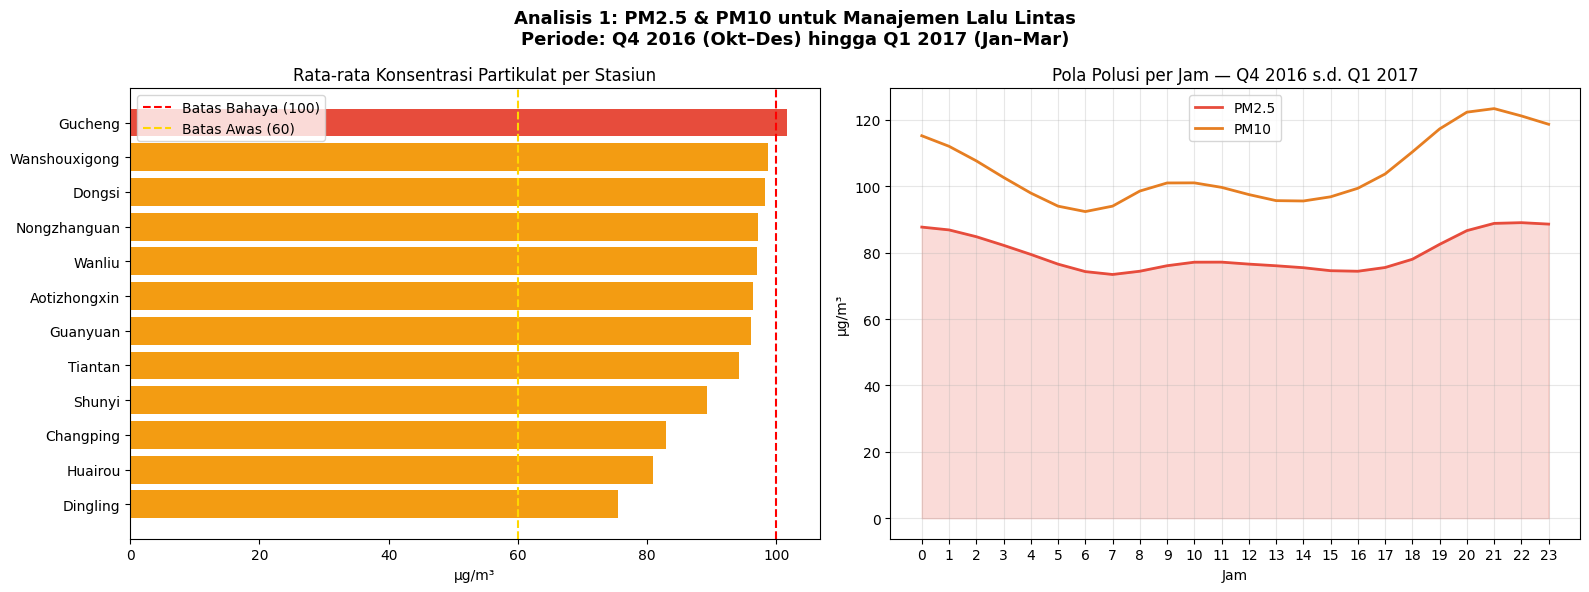


Grafik disimpan: chart/analisis_1_perencana_kota.png


In [52]:
#  bagian kode akan membuatkan sebuah gambar 2D yang terdiri dari dua subplot.
# Subplot pertama akan menampilkan grafik rata-rata konsentrasi partikulat per stasiun
# yang diurutkan berdasarkan statusnya (bahaya, awas, atau aman).
# Subplot kedua akan menampilkan grafik pola polusi per jam yang diurutkan berdasarkan
# jenis polusi (PM2.5 atau PM10).

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(
    "Analisis 1: PM2.5 & PM10 untuk Manajemen Lalu Lintas\n"
    "Periode: Q4 2016 (Okt–Des) hingga Q1 2017 (Jan–Mar)",
    fontsize=13, fontweight='bold'
)
 
# bagian kode akan membuatkan sebuah dictionary yang berisi zona dan warnanya.
zone_color_map = {'Bahaya': '#e74c3c', 'Awas': '#f39c12', 'Aman': '#27ae60'}
# bagian kode akan membuatkan sebuah list yang berisi warna dari setiap zona.
colors = [zone_color_map[z] for z in station_pollution_sorted['Status']]
# bagian kode akan membuatkan sebuah grafik rata-rata konsentrasi partikulat per stasiun
# yang diurutkan berdasarkan statusnya (bahaya, awas, atau aman).
axes[0].barh(station_pollution_sorted.index, station_pollution_sorted['Avg_Particulate'], color=colors)
# bagian kode akan mengaturkan judul dari subplot pertama.
axes[0].set_title("Rata-rata Konsentrasi Partikulat per Stasiun")
# bagian kode akan mengaturkan label dari sumbu x.
axes[0].set_xlabel("µg/m³")
# bagian kode akan mengaturkan garis vertikal yang menunjukkan batas zona bahaya,
# awas, dan aman.
axes[0].axvline(x=100, color='red',  linestyle='--', label='Batas Bahaya (100)')
axes[0].axvline(x=60,  color='gold', linestyle='--', label='Batas Awas (60)')
# bagian kode akan mengaturkan orientasi dari subplot pertama.
axes[0].invert_yaxis()
# bagian kode akan mengaturkan legenda dari subplot pertama.
axes[0].legend()
 
# bagian kode akan membuatkan sebuah grafik pola polusi per jam yang diurutkan
# berdasarkan jenis polusi (PM2.5 atau PM10).
axes[1].plot(hourly_pollution.index, hourly_pollution['PM2.5'], label='PM2.5', color='#e74c3c', linewidth=2)
axes[1].plot(hourly_pollution.index, hourly_pollution['PM10'],  label='PM10',  color='#e67e22', linewidth=2)
# bagian kode akan mengaturkan area yang diarsir oleh garis PM2.5 dengan warna yang
# sedikit transparan.
axes[1].fill_between(hourly_pollution.index, hourly_pollution['PM2.5'], alpha=0.2, color='#e74c3c')
# bagian kode akan mengaturkan judul dari subplot kedua.
axes[1].set_title("Pola Polusi per Jam — Q4 2016 s.d. Q1 2017")
# bagian kode akan mengaturkan label dari sumbu x.
axes[1].set_xlabel("Jam"); axes[1].set_ylabel("µg/m³")
# bagian kode akan mengaturkan tick dari sumbu x.
axes[1].set_xticks(range(0, 24))
# bagian kode akan mengaturkan legenda dari subplot kedua.
axes[1].legend(); axes[1].grid(alpha=0.3)
 
# bagian kode akan mengaturkan layout dari gambar.
plt.tight_layout()
# bagian kode akan menyimpan gambar ke dalam sebuah file.
if not os.path.exists('chart'):
    os.makedirs('chart')
plt.savefig("chart/analisis_1_perencana_kota.png", dpi=150, bbox_inches='tight')
# bagian kode akan menampilkan gambar.
plt.show()
# bagian kode akan mencetakkan lokasi dari file yang disimpan.
print("\nGrafik disimpan: chart/analisis_1_perencana_kota.png")

### Pertanyaan 2:

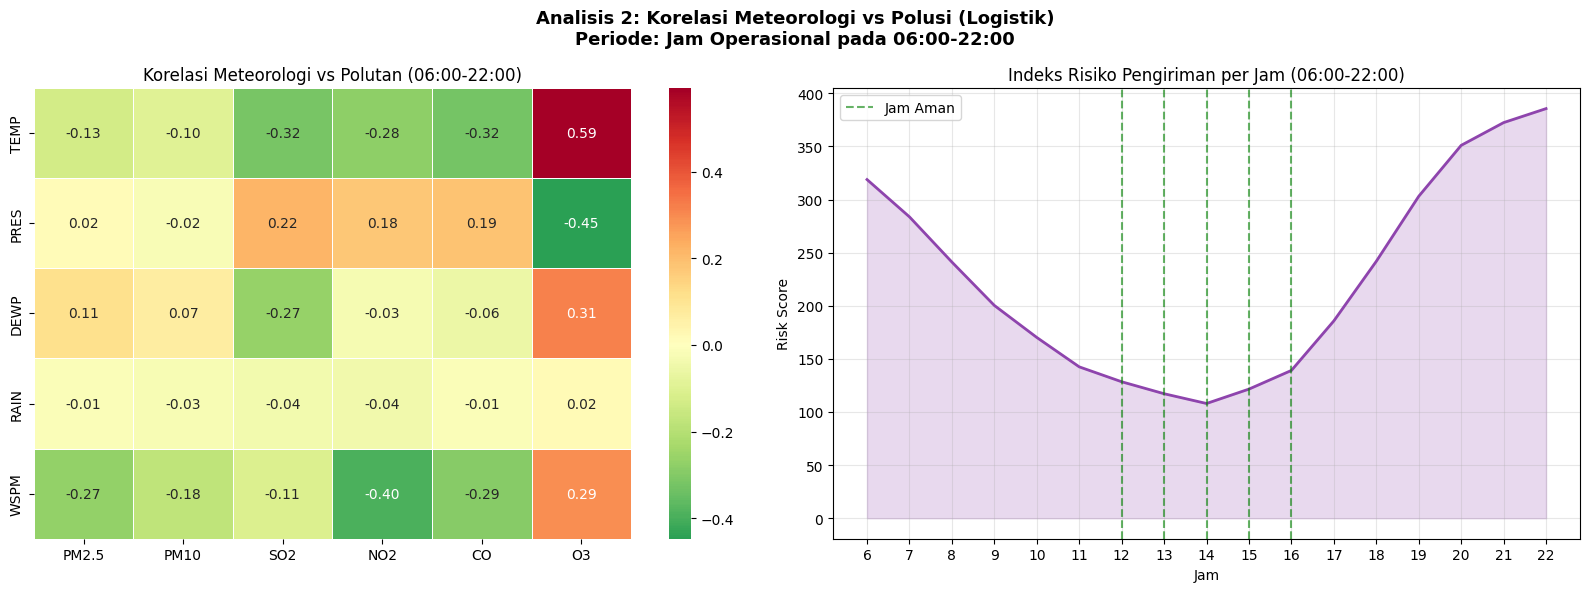


Grafik disimpan: chart/analisis_2_logistik.png


In [53]:
# Membuat grafik yang membandingkan korelasi antara variabel meteorologi dan polusi
# dalam periode jam operasional pada (06.00-22.00)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(
    "Analisis 2: Korelasi Meteorologi vs Polusi (Logistik)\n"
    "Periode: Jam Operasional pada 06:00-22:00",
    fontsize=13, fontweight='bold'
)

# Membuat heatmap yang membandingkan korelasi antara variabel meteorologi dan polusi
# menggunakan library seaborn
import seaborn as sns
sns.heatmap(corr_meteo_vs_pollution, annot=True, fmt=".2f", cmap='RdYlGn_r',
            center=0, ax=axes[0], linewidths=0.5)
# Memberikan judul grafik heatmap tersebut
axes[0].set_title("Korelasi Meteorologi vs Polutan (06:00-22:00)")

# Membuat grafik yang membandingkan indeks risiko pengiriman per jam
# dalam periode jam operasional pada (06.00-22.00)
axes[1].plot(safe_hours.index, safe_hours.values, color='#8e44ad', linewidth=2)
# Memberikan area di bawah kurva indeks risiko pengiriman per jam
axes[1].fill_between(safe_hours.index, safe_hours.values, alpha=0.2, color='#8e44ad')
# Membuat garis vertikal yang menunjukkan jam-jam aman
for h in safest:
    axes[1].axvline(x=h, color='green', linestyle='--', alpha=0.6, label='Jam Aman' if h == safest[0] else '')
# Memberikan judul grafik indeks risiko pengiriman per jam tersebut
axes[1].set_title("Indeks Risiko Pengiriman per Jam (06:00-22:00)")
axes[1].set_xlabel("Jam"); axes[1].set_ylabel("Risk Score")
axes[1].set_xticks(range(6, 23))
axes[1].legend(); axes[1].grid(alpha=0.3)

# Membuat spasi antara grafik-grafik agar tidak overlap
plt.tight_layout()

# Simpan grafik dalam file
plt.savefig("chart/analisis_2_logistik.png", dpi=150, bbox_inches='tight')
plt.show()
print("\nGrafik disimpan: chart/analisis_2_logistik.png")

### Pertanyaan 3:

C:\Users\melvi\AppData\Local\Temp\ipykernel_24064\4181106764.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(risk_sorted.index, rotation=45, ha='right')
C:\Users\melvi\AppData\Local\Temp\ipykernel_24064\4181106764.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(bulan_label, rotation=30, ha='right', fontsize=8)


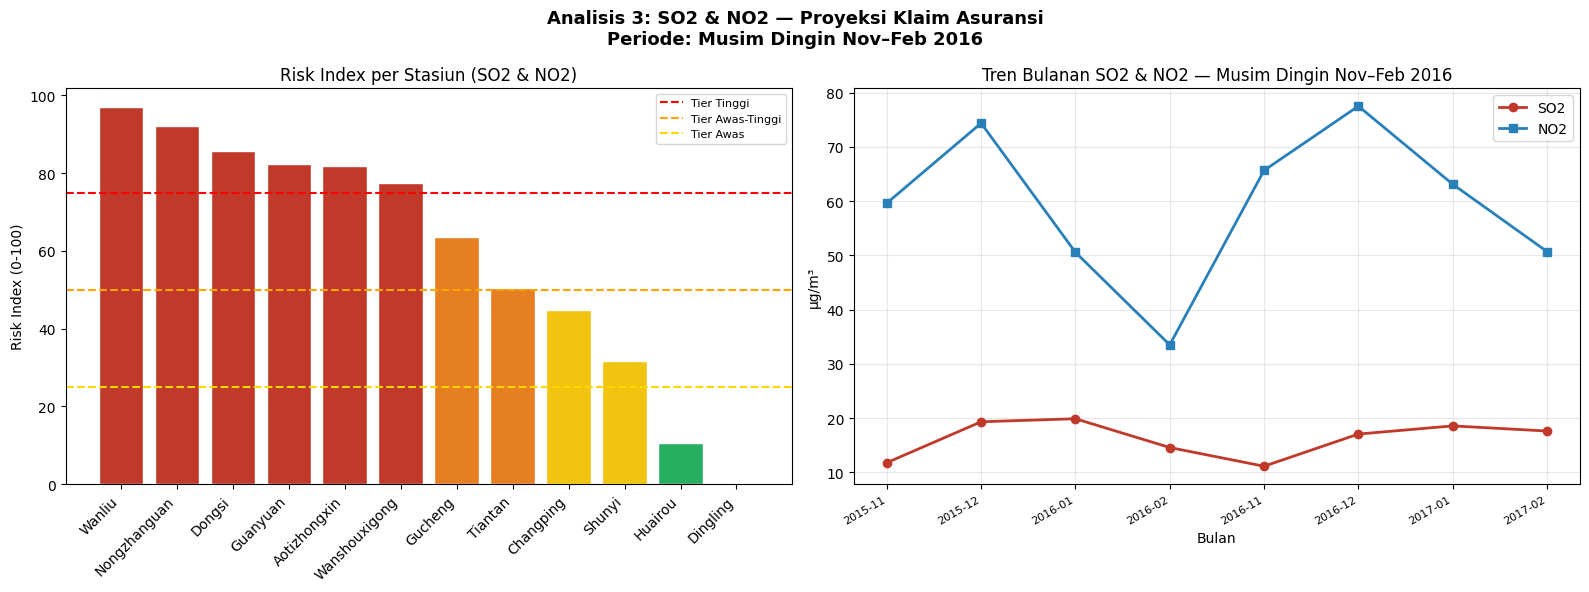


Grafik disimpan: chart/analisis_3_asuransi.png


In [54]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(
    "Analisis 3: SO2 & NO2 — Proyeksi Klaim Asuransi\n"
    "Periode: Musim Dingin Nov–Feb 2016",
    fontsize=13, fontweight='bold'
)
 
risk_sorted = risk_index.sort_values(ascending=False)
bar_colors  = ['#c0392b' if s >= 75 else '#e67e22' if s >= 50
               else '#f1c40f' if s >= 25 else '#27ae60' for s in risk_sorted]
axes[0].bar(risk_sorted.index, risk_sorted.values, color=bar_colors, edgecolor='white')
axes[0].set_title("Risk Index per Stasiun (SO2 & NO2)")
axes[0].set_ylabel("Risk Index (0-100)")
axes[0].set_xticklabels(risk_sorted.index, rotation=45, ha='right')
axes[0].axhline(y=75, color='red',    linestyle='--', label='Tier Tinggi')
axes[0].axhline(y=50, color='orange', linestyle='--', label='Tier Awas-Tinggi')
axes[0].axhline(y=25, color='gold',   linestyle='--', label='Tier Awas')
axes[0].legend(fontsize=8)
 
axes[1].plot(bulan_label, monthly_trend['SO2'].values, label='SO2',
             color='#c0392b', linewidth=2, marker='o')
axes[1].plot(bulan_label, monthly_trend['NO2'].values, label='NO2',
             color='#2980b9', linewidth=2, marker='s')
axes[1].set_title("Tren Bulanan SO2 & NO2 — Musim Dingin Nov–Feb 2016")
axes[1].set_xlabel("Bulan"); axes[1].set_ylabel("µg/m³")
axes[1].set_xticklabels(bulan_label, rotation=30, ha='right', fontsize=8)
axes[1].legend(); axes[1].grid(alpha=0.3)
 
plt.tight_layout()
plt.savefig("chart/analisis_3_asuransi.png", dpi=150, bbox_inches='tight')
plt.show()
print("\nGrafik disimpan: chart/analisis_3_asuransi.png")

**Insight:**<br>
**- Pertanyaan 1:<br>**
**Bagaimana mengintegrasikan data historis PM2.5 & PM10 ke dalam sistem manajemen lalu lintas untuk membatasi volume kendaraan pada Q4 2016 – Q1 2017**<br>
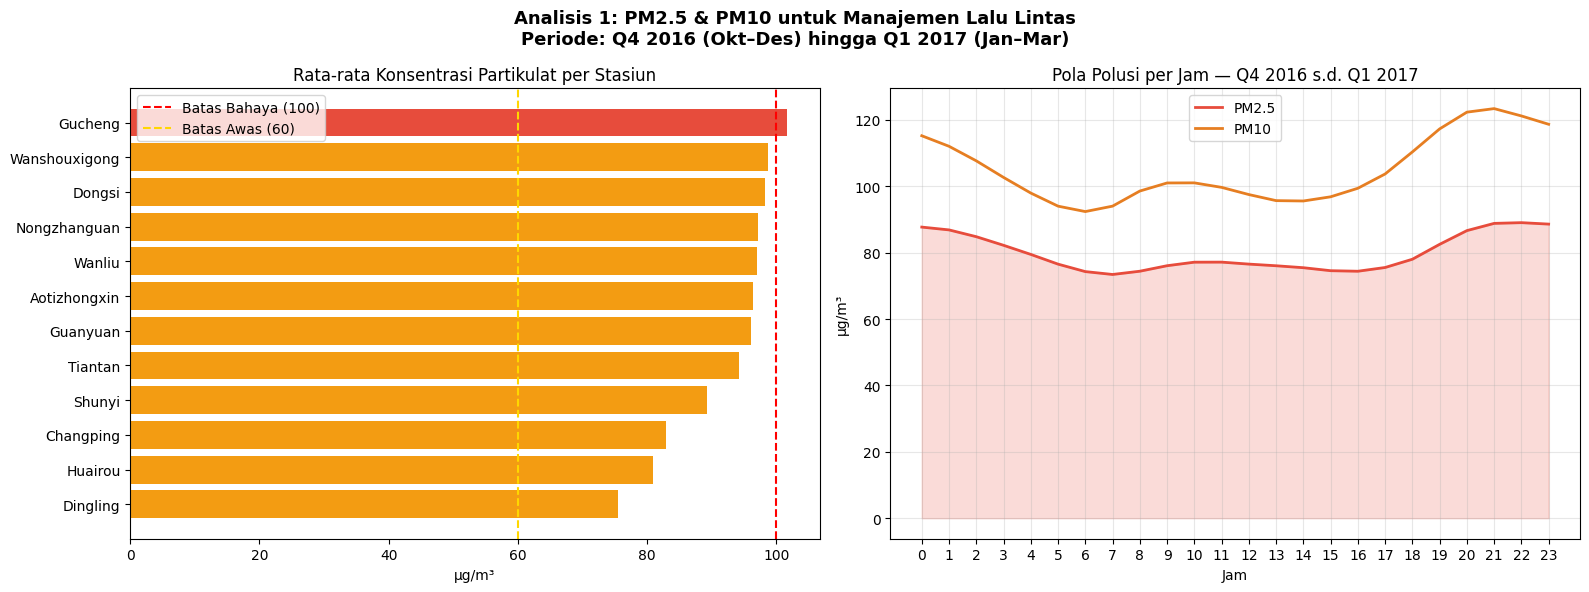
- Grafik batang menunjukkan Guchengsebagai satu-satunya stasiun yang melampaui garis batas bahaya (100 µg/m³) dengan rata-rata partikulat 101.67 µg/m³. Seluruh 11 stasiun lainnya berada di zona oranye (Awas, 60–100 µg/m³), dan tidak ada satupun yang berada di bawah garis batas aman — menandakan kondisi udara di seluruh Beijing sangat buruk selama Q4 2016 hingga Q1 2017.

- Grafik pola per jam memperlihatkan pola berbentuk lembah (valley shape) pada PM2.5 maupun PM10: konsentrasi tinggi di pagi hari (pukul 00.00–06.00), menurun ke titik terendah sekitar pukul 06.00–08.00, naik kembali membentuk puncak kedua pada pukul 09.00–10.00, lalu menurun di siang hari sebelum melonjak kembali tajam mulai pukul 19.00–23.00.

- Pola dua puncak ini mencerminkan dua gelombang aktivitas kendaraan: puncak pagi (commuter & distribusi barang pagi) dan puncak malam (kendaraan berat yang beroperasi di luar jam sibuk). Kebijakan pembatasan kendaraan paling efektif perlu menyasar jam 19.00–23.00 sebagai prioritas utama.

- PM10 secara konsisten lebih tinggi 20–30 µg/m³ dibanding PM2.5 sepanjang hari, mengindikasikan kontribusi signifikan dari debu jalan dan partikel kasar akibat aktivitas konstruksi dan kendaraan berat yang khas pada periode musim dingin di Beijing. <br>

**- Pertanyaan 2**<br>
**Bagaimana mengukur korelasi meteorologi vs polusi untuk mengalihkan rute pengiriman selama jam operasional pukul 06.00–22.00?**<br>
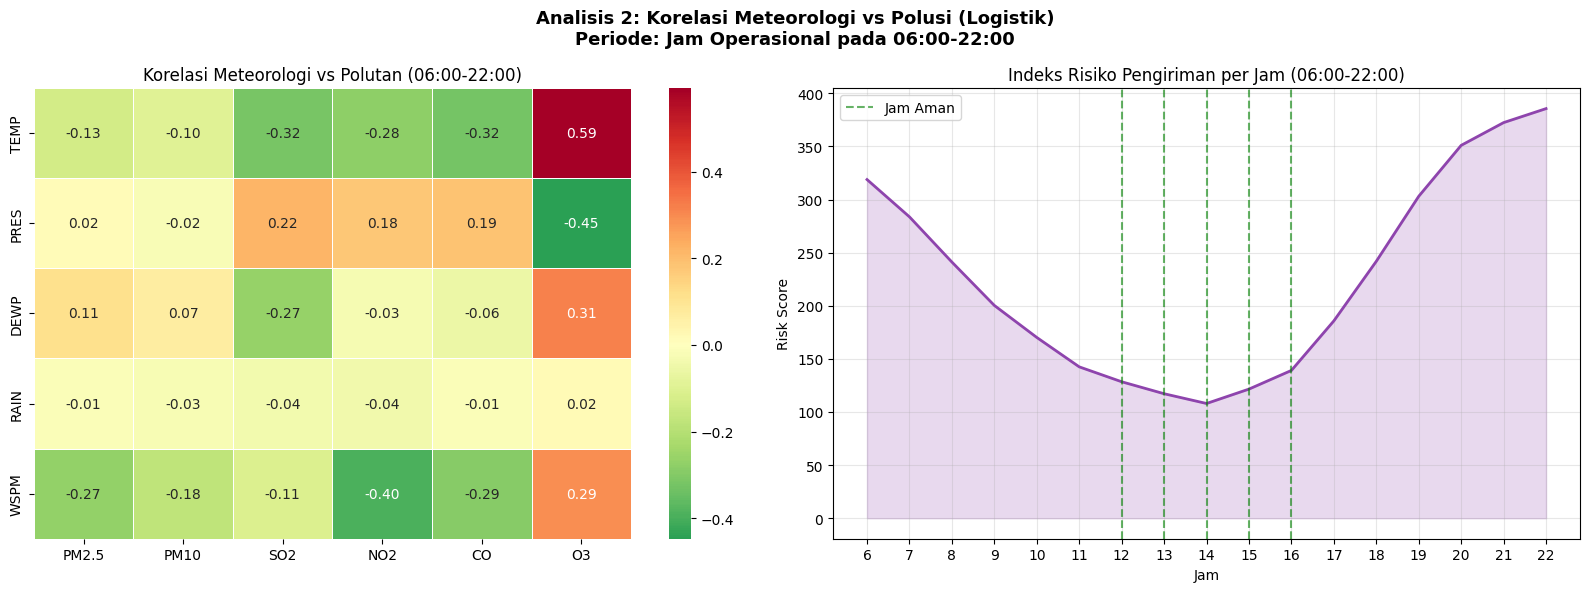
- Heatmap korelasi menunjukkan WSPM (kecepatan angin) sebagai variabel meteorologi paling berpengaruh terhadap polutan, khususnya NO2 (r = -0.40) dan CO (r = -0.29). Semakin kencang angin bertiup selama jam operasional, polutan terdispersi lebih efektif — menjadikan WSPM sebagai indikator utama dalam sistem keputusan rute pengiriman.

- TEMP (suhu) menunjukkan korelasi positif kuat terhadap O3 (r = +0.59) — nilai tertinggi di seluruh matriks. Ini berarti pada siang hari yang panas, ozon justru meningkat berbahaya. Manajer logistik perlu mempertimbangkan risiko ozon sebagai ancaman pada pengiriman siang hari, tidak hanya PM2.5.

- RAIN (curah hujan) tidak memiliki korelasi signifikan dengan polutan manapun (semua |r| < 0.05), sehingga hujan tidak bisa dijadikan acuan keamanan pengiriman secara mandiri.

- Grafik indeks risiko per jam memperlihatkan pola U-shape yang sangat jelas: risiko sangat tinggi di pukul 06.00 (Risk Score ~380), turun drastis hingga titik terendah pada pukul 14.00–15.00 (Risk Score ~110), lalu melonjak kembali ke level berbahaya menjelang pukul 22.00 (~380). Garis hijau putus-putus menandai jam paling aman: 12.00–16.00.

- Temuan penting: pukul 06.00 pagi masuk dalam jam paling berisiko — berbDiagram dari asumsi umum bahwa pagi hari lebih bersih. Ini menunjukkan polutan dari malam sebelumnya masih terperangkap dan belum terdispersi saat operasional pengiriman dimulai.<br>

**- Pertanyaan 3**<br>
**Bagaimana menganalisis fluktuasi SO2 & NO2 selama musim dingin Nov–Feb 2016 untuk memproyeksikan lonjakan klaim penyakit pernapasan?** <br>
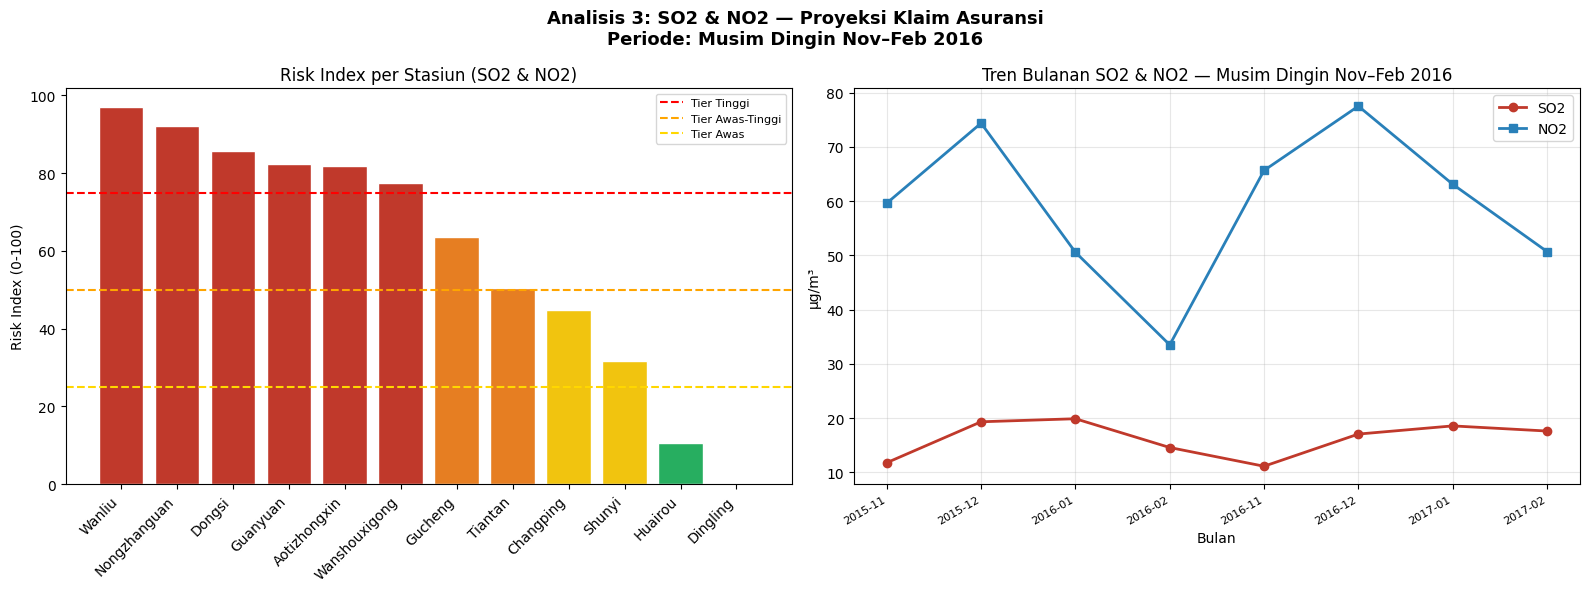
- Grafik Risk Index menunjukkan distribusi tier premi yang jelas: 6 stasiun (Wanliu, Nongzhanguan, Dongsi, Guanyuan, Aotizhongxin, Wanshouxigong) masuk Tier Tinggi (di atas garis merah 75), 2 stasiun (Gucheng, Tiantan) di Tier Awas-Tinggi (50–75), 2 stasiun (Changping, Shunyi) di Tier Awas (25–50), dan hanya Huairou & Dingling yang masuk Tier Rendah (hijau, di bawah 25).

- Wanliu memuncaki Risk Index dengan skor 97.0 — hampir menyentuh nilai maksimum 100 — menjadikannya wilayah paling berisiko bagi nasabah asuransi kesehatan pernapasan. Nasabah yang berdomisili di Wanliu layak dikenakan premi tertinggi Rp 1.000.000/bulan.

- Grafik tren bulanan memperlihatkan pola W-shape pada NO2: puncak di Desember 2015 (74.36 µg/m³) → turun di Februari 2016 (33.50) → naik kembali ke puncak tertinggi Desember 2016 (77.50 µg/m³) → turun di Februari 2017 (50.70). Pola ini sangat konsisten antar dua musim dingin, memberikan prediktabilitas tinggi untuk model klaim aktuarial.

- SO2 bergerak relatif stabil di kisaran 11–20 µg/m³ sepanjang musim dingin, jauh lebih rendah variabilitasnya dibanding NO2. Namun lonjakan SO2_max Gucheng hingga 500 µg/m³ (outlier ekstrem) menandakan potensi klaim katastrofik mendadak yang perlu dimasukkan ke dalam model risiko ekor (tail risk).

- Februari secara konsisten menjadi bulan dengan konsentrasi terendah di kedua musim dingin (NO2: 33.50 di 2016 dan 50.70 di 2017), mengindikasikan bahwa risiko klaim mulai merDiagram memasuki Februari dan cadangan klaim dapat disesuaikan mulai Maret.

## # Grafik tambahan sesuai dengan arahan revisi dari reviewer
kepada Reviewer, <br>
 mohon maaf saya sudah brainstorming kurang lebih semalaman namun tidak menemukan ide grafik yang cocok untuk masuk kedalam pertayaan bisnis saya, jadi saya memutuskan untuk memuat grafik yang diminta secara terpisah dan sedikit berhubungan dengan pertayaan bisnis namun tetap berhubungan dengan data <br>
saya sangat terbuka dan berterimakasih atas saran dan bila perlu revisi yang saya harus kerjakan untuk memberikan grafik yang sesuai dengan pertayaan bisnis saya

In [55]:
POLLUTANTS = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3']
METEO      = ['TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']
ALL_NUM    = POLLUTANTS + METEO

  Diagram tambahan UNIVARIATE


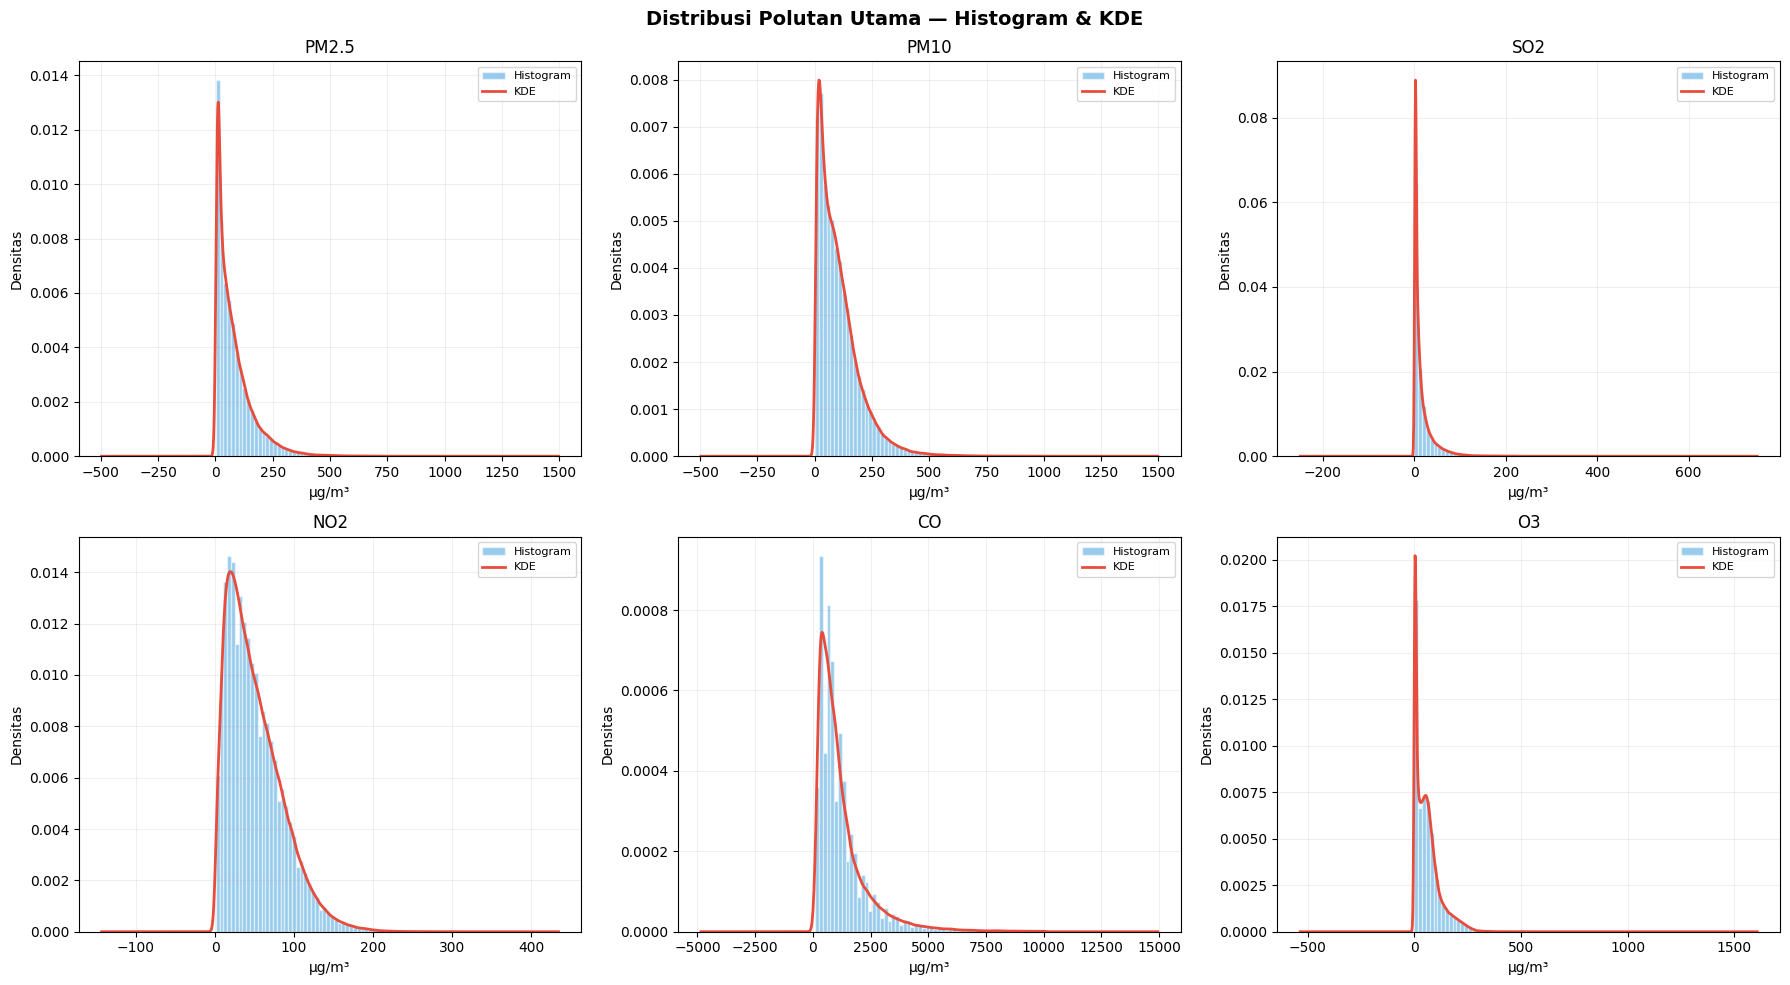

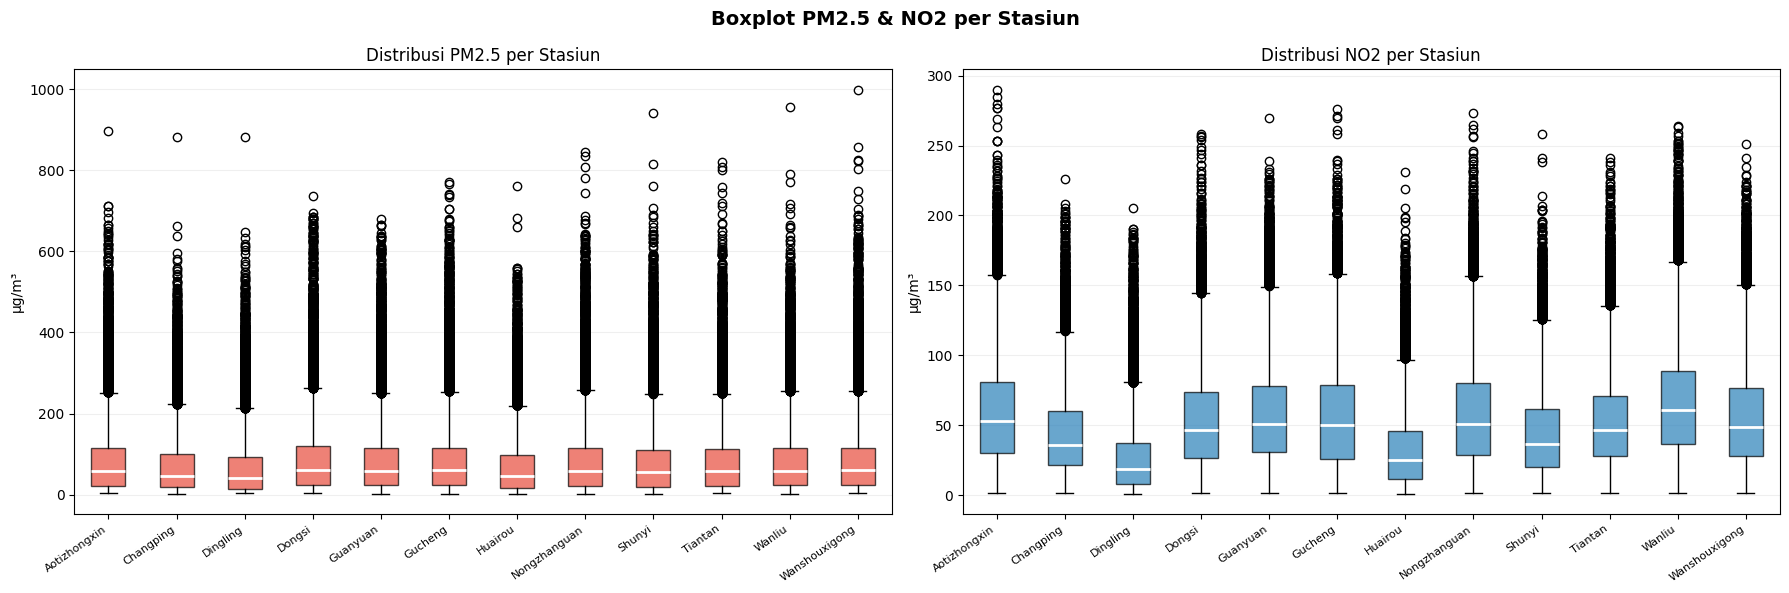

C:\Users\melvi\AppData\Local\Temp\ipykernel_24064\1113347404.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_all, x='station', y='PM2.5', palette='RdYlGn_r',
C:\Users\melvi\AppData\Local\Temp\ipykernel_24064\1113347404.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(sorted(df_all['station'].unique()), rotation=35, ha='right', fontsize=8)


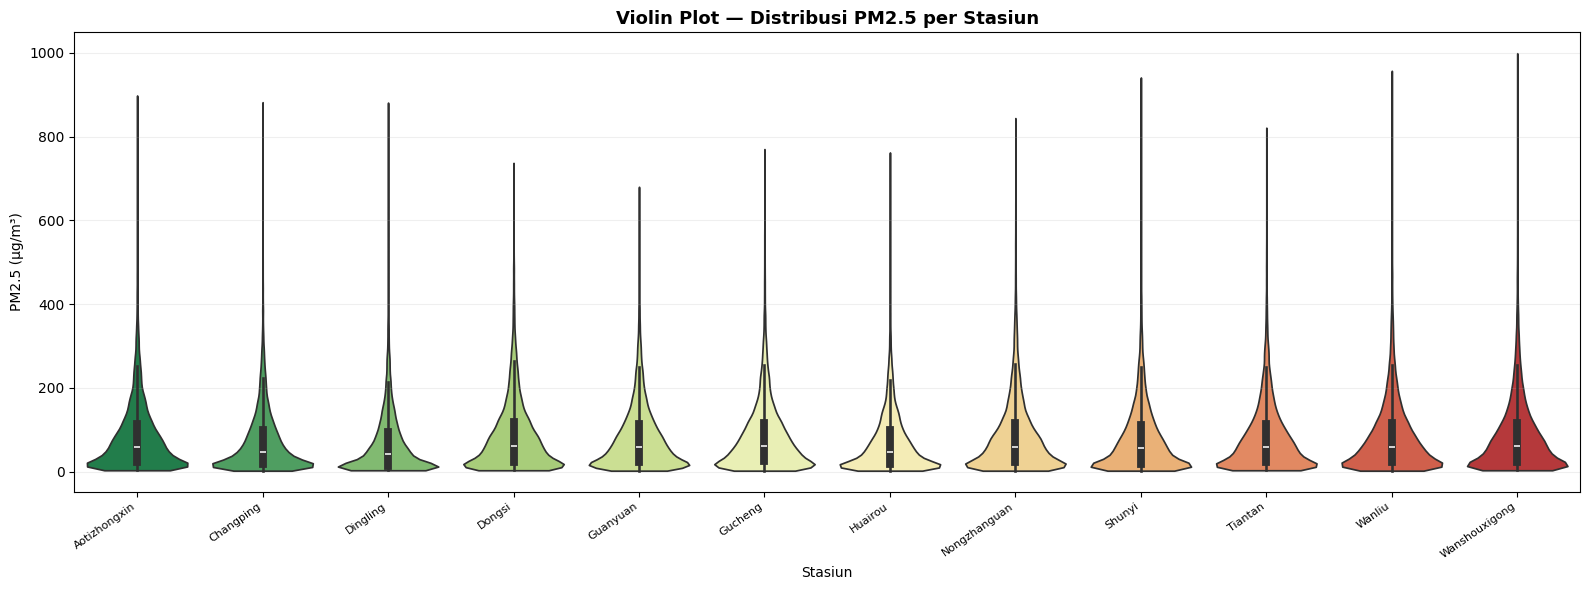


Skewness & Kurtosis per Variabel Numerik:
  Variabel           Mean        Std   Skewness   Kurtosis Bentuk                   
  ────────────────────────────────────────────────────────────────────────────────
  PM2.5             79.84      80.95      2.020      5.975 Skewed Kanan (Right)
  PM10             104.91      92.43      1.927      6.526 Skewed Kanan (Right)
  SO2               15.91      21.90      3.181     17.932 Skewed Kanan (Right)
  NO2               50.60      35.17      1.051      1.210 Skewed Kanan (Right)
  CO              1235.68    1161.79      2.631      9.864 Skewed Kanan (Right)
  O3                57.24      57.14      1.715      6.532 Skewed Kanan (Right)
  TEMP              13.53      11.44     -0.103     -1.144 Simetris (Normal)
  PRES            1010.75      10.47      0.106     -0.830 Simetris (Normal)
  DEWP               2.48      13.80     -0.187     -1.133 Simetris (Normal)
  RAIN               0.06       0.82     30.056   1346.667 Skewed Kanan (Right

<Figure size 640x480 with 0 Axes>

In [56]:
# 1. Diagram tambahan UNIVARIATE
print("=" * 60)
print("  Diagram tambahan UNIVARIATE")
print("=" * 60)

# 1a. Histogram + KDE per polutan ─
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Distribusi Polutan Utama — Histogram & KDE", fontsize=14, fontweight='bold')

for ax, col in zip(axes.flatten(), POLLUTANTS):
    data = df_all[col].dropna()
    ax.hist(data, bins=60, color='#3498db', alpha=0.5, edgecolor='white',
            density=True, label='Histogram')
    data.plot.kde(ax=ax, color='#e74c3c', linewidth=2, label='KDE')
    ax.set_title(f"{col}")
    ax.set_xlabel("µg/m³"); ax.set_ylabel("Densitas")
    ax.legend(fontsize=8); ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

# 1b. Boxplot per stasiun untuk PM2.5 & NO2
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle("Boxplot PM2.5 & NO2 per Stasiun", fontsize=14, fontweight='bold')

for ax, col, color in zip(axes, ['PM2.5', 'NO2'], ['#e74c3c', '#2980b9']):
    data_box = [df_all[df_all['station'] == s][col].dropna().values
                for s in sorted(df_all['station'].unique())]
    bp = ax.boxplot(data_box, patch_artist=True, notch=False,
                    medianprops=dict(color='white', linewidth=2))
    for patch in bp['boxes']:
        patch.set_facecolor(color); patch.set_alpha(0.7)
    ax.set_xticklabels(sorted(df_all['station'].unique()), rotation=35, ha='right', fontsize=8)
    ax.set_title(f"Distribusi {col} per Stasiun")
    ax.set_ylabel("µg/m³"); ax.grid(axis='y', alpha=0.2)

plt.tight_layout()
plt.show()

# 1c. Violin Plot — PM2.5 per stasiun
fig, ax = plt.subplots(figsize=(16, 6))
sns.violinplot(data=df_all, x='station', y='PM2.5', palette='RdYlGn_r',
               order=sorted(df_all['station'].unique()), ax=ax, cut=0)
ax.set_title("Violin Plot — Distribusi PM2.5 per Stasiun", fontsize=13, fontweight='bold')
ax.set_xlabel("Stasiun"); ax.set_ylabel("PM2.5 (µg/m³)")
ax.set_xticklabels(sorted(df_all['station'].unique()), rotation=35, ha='right', fontsize=8)
ax.grid(axis='y', alpha=0.2)

plt.tight_layout()
plt.show()

# 1d. Skewness & Kurtosis Analysis 
print("\nSkewness & Kurtosis per Variabel Numerik:")
print(f"  {'Variabel':<12} {'Mean':>10} {'Std':>10} {'Skewness':>10} {'Kurtosis':>10} {'Bentuk':<25}")
print("  " + "─" * 80)

for col in ALL_NUM:
    data = df_all[col].dropna()
    mean_val = data.mean()
    std_val  = data.std()
    skew     = data.skew()
    kurt     = data.kurtosis()
    if abs(skew) < 0.5:
        shape = "Simetris (Normal)"
    elif skew > 0.5:
        shape = "Skewed Kanan (Right)"
    else:
        shape = "Skewed Kiri (Left)"
    print(f"  {col:<12} {mean_val:>10.2f} {std_val:>10.2f} {skew:>10.3f} {kurt:>10.3f} {shape}")
plt.tight_layout()
plt.show()


  Diagram tambahan MULTIVARIATE


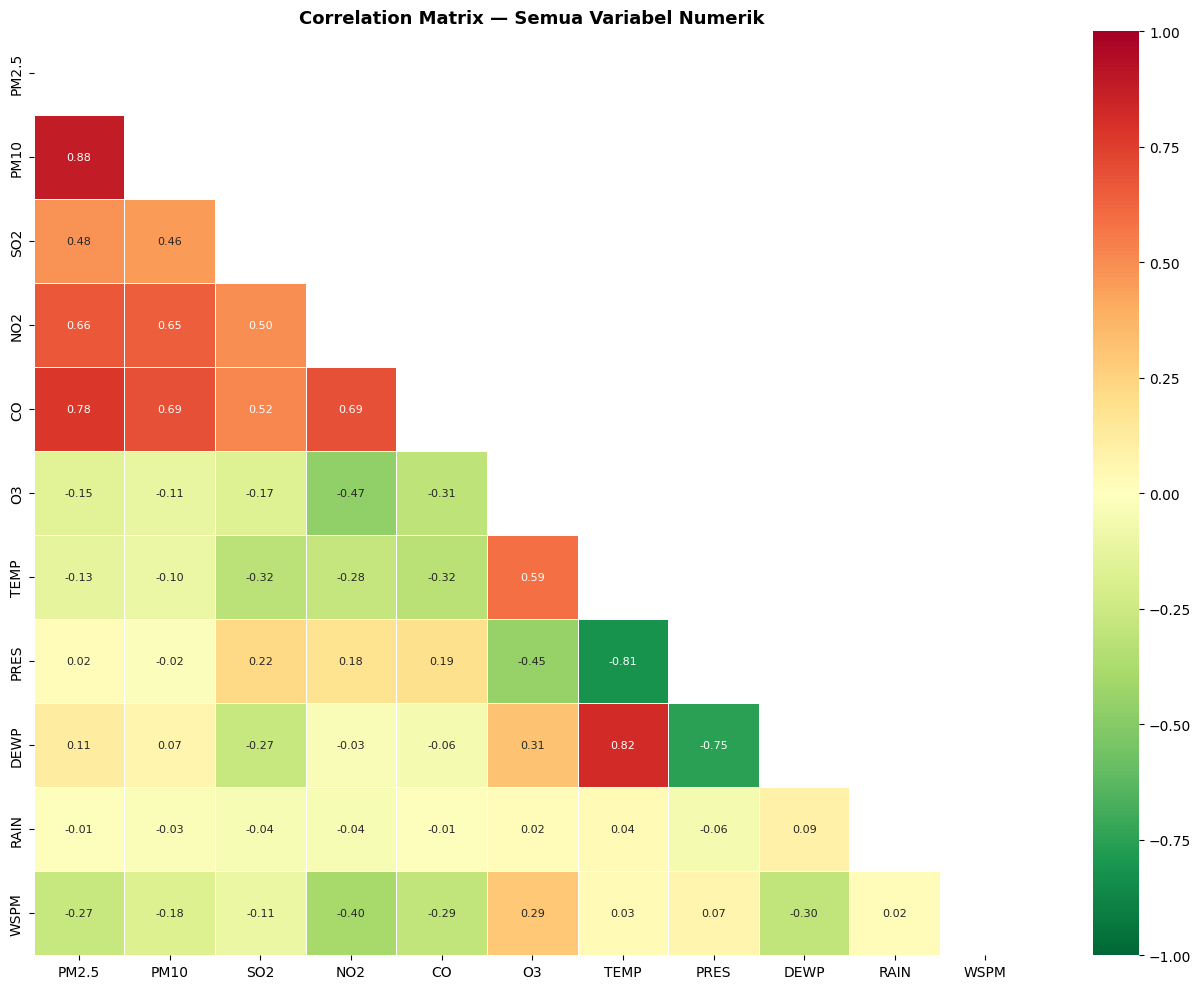

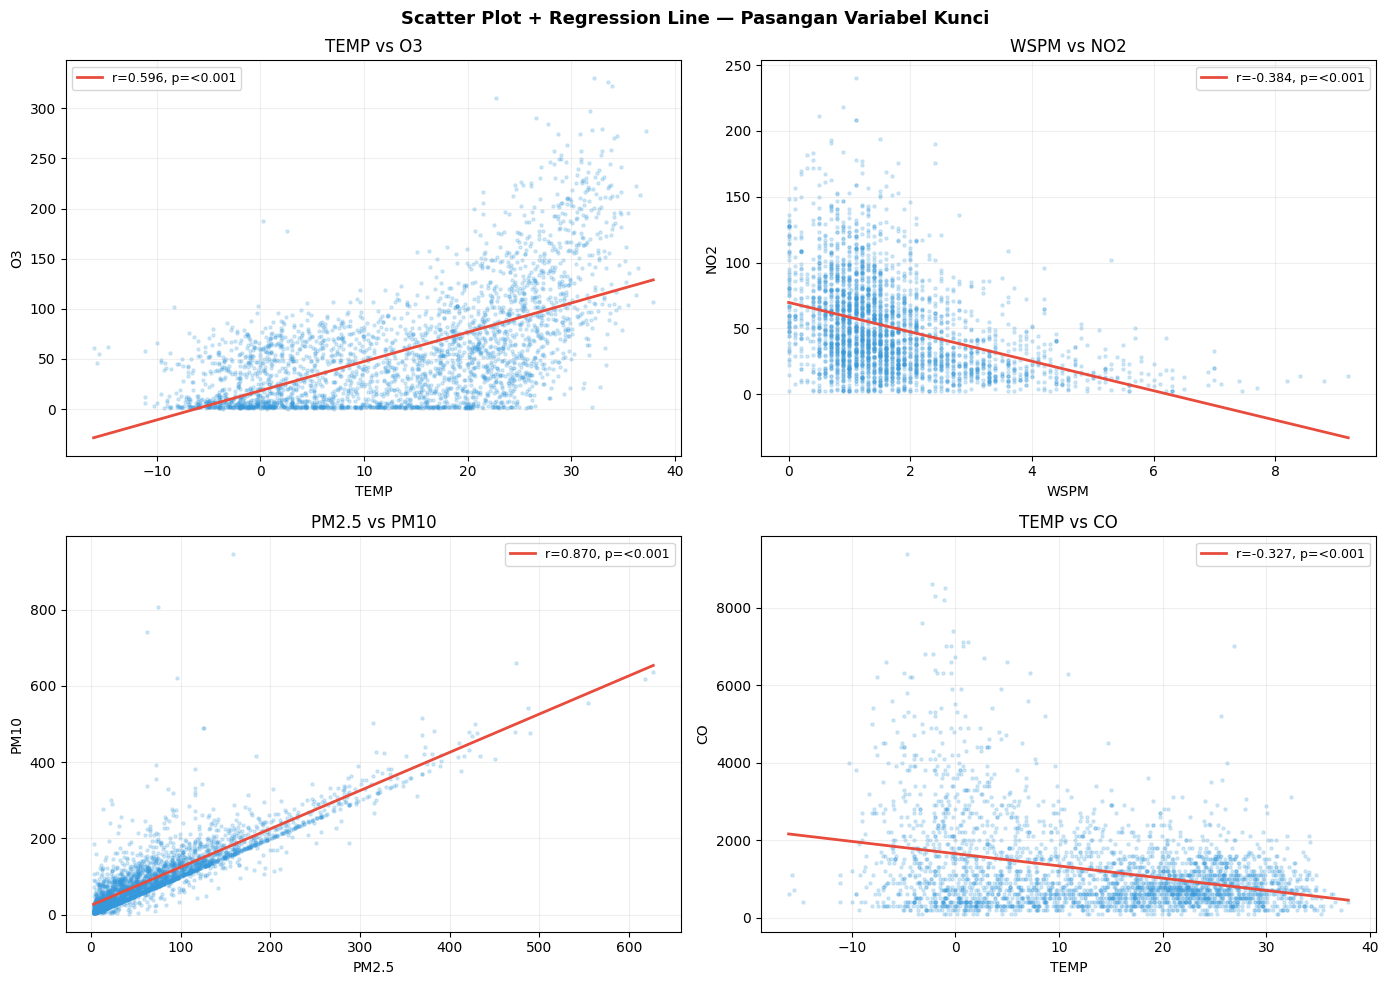

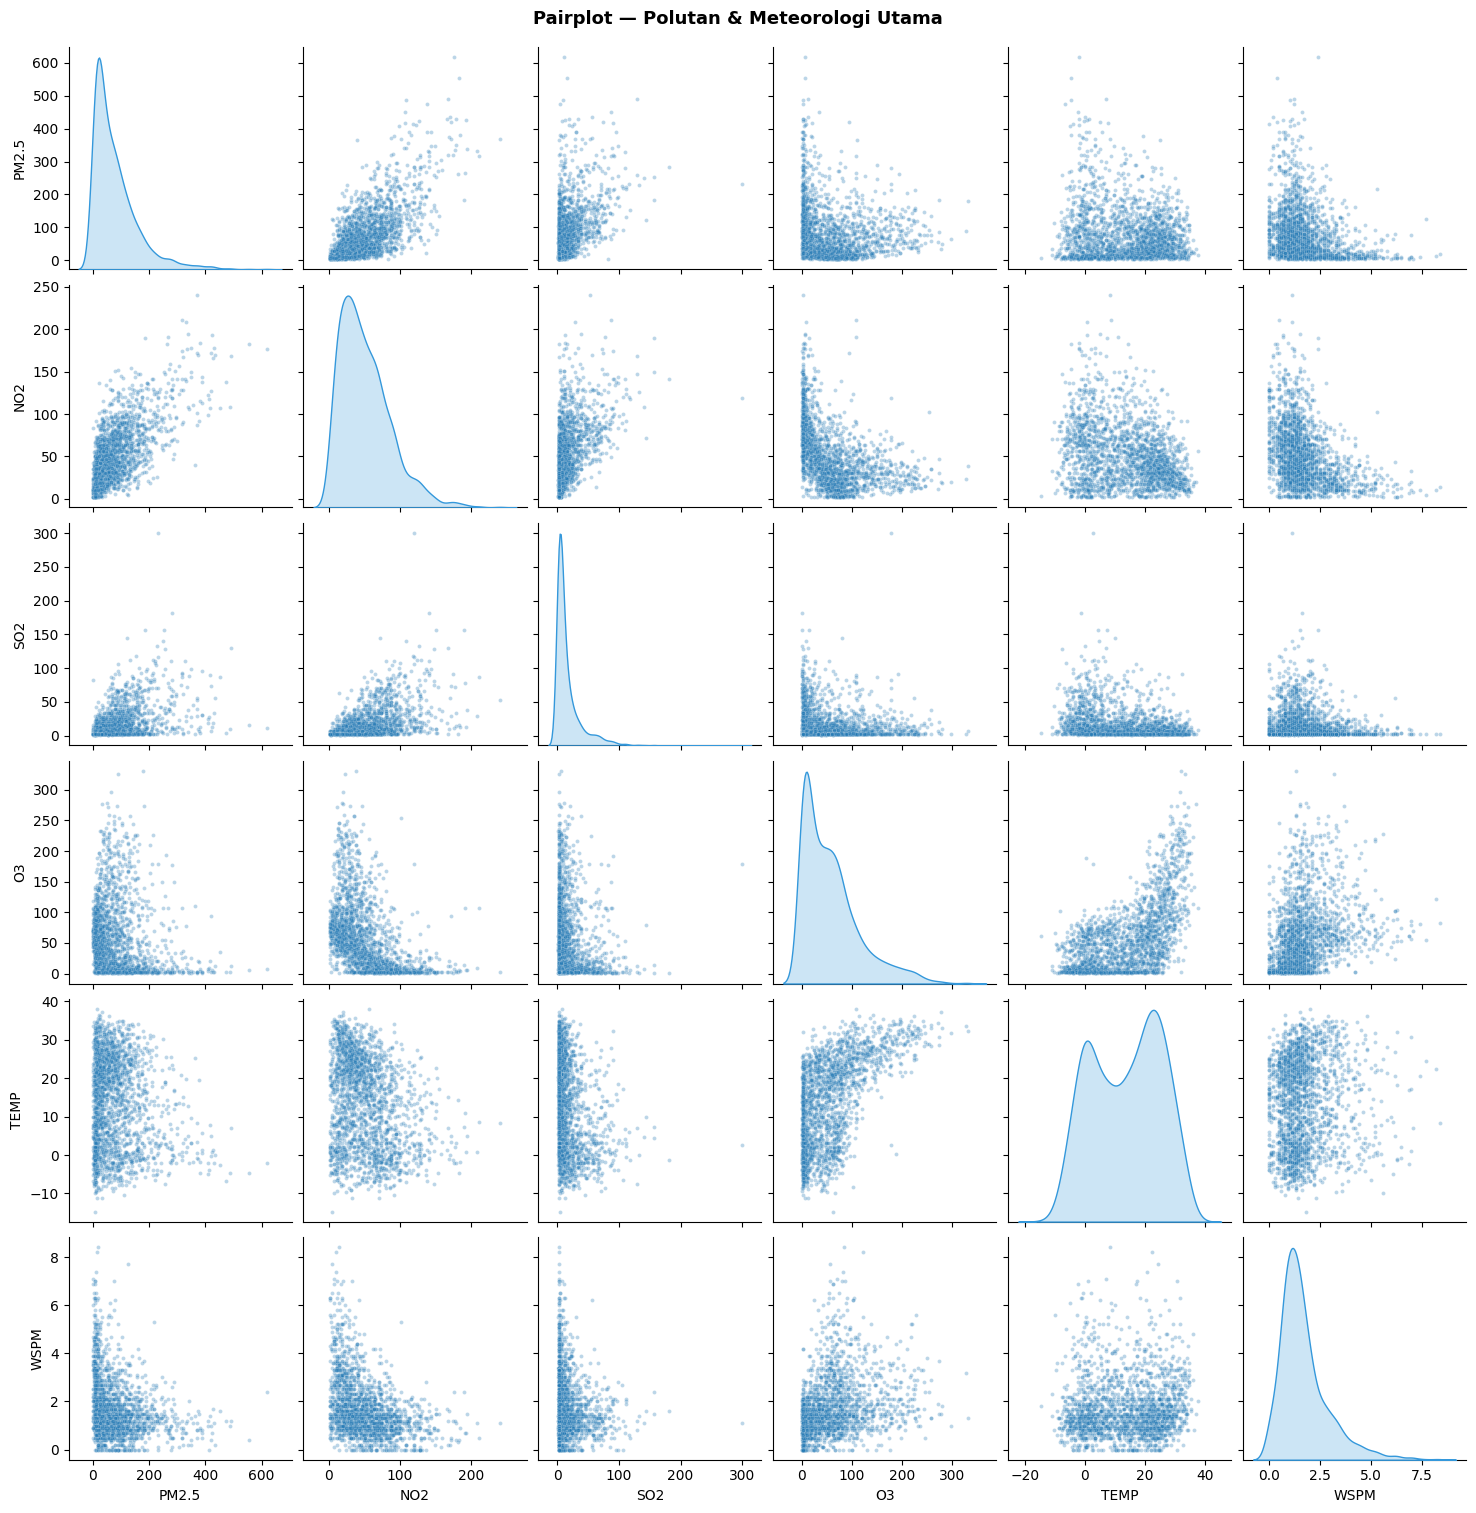

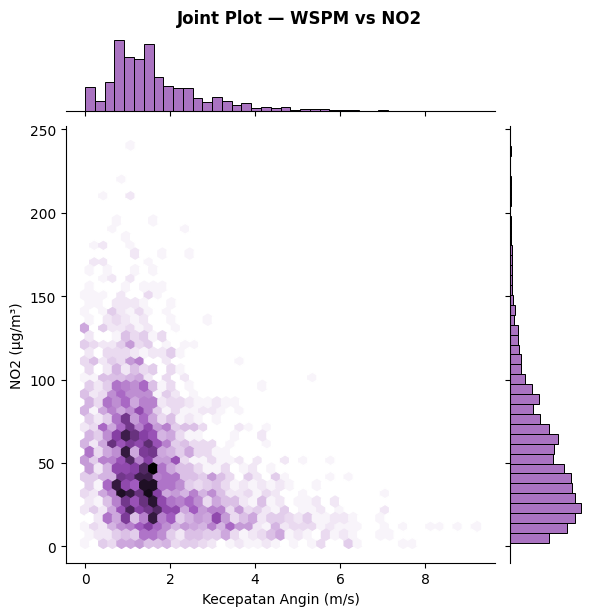

In [ ]:
# 2. Diagram tambahan MULTIVARIATE

print("\n" + "=" * 60)
print("  Diagram tambahan MULTIVARIATE")
print("=" * 60)

# 2a. Correlation Matrix Heatmap (semua numerik)
fig, ax = plt.subplots(figsize=(13, 10))
corr_full = df_all[ALL_NUM].corr()
mask = np.triu(np.ones_like(corr_full, dtype=bool))
sns.heatmap(corr_full, mask=mask, annot=True, fmt=".2f", cmap='RdYlGn_r',
            center=0, linewidths=0.4, ax=ax,
            annot_kws={'size': 8}, vmin=-1, vmax=1)
ax.set_title("Correlation Matrix — Semua Variabel Numerik", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# 2b. Scatter Plot + Regression Line (pasangan kunci) 
pairs = [('TEMP', 'O3'), ('WSPM', 'NO2'), ('PM2.5', 'PM10'), ('TEMP', 'CO')]
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Scatter Plot + Regression Line — Pasangan Variabel Kunci",
             fontsize=13, fontweight='bold')

for ax, (x_col, y_col) in zip(axes.flatten(), pairs):
    sample = df_all[[x_col, y_col]].dropna().sample(min(3000, len(df_all)), random_state=42)
    ax.scatter(sample[x_col], sample[y_col], alpha=0.2, s=5, color='#3498db')
    # Regression line
    slope, intercept, r, p, _ = stats.linregress(sample[x_col], sample[y_col])
    x_range = np.linspace(sample[x_col].min(), sample[x_col].max(), 100)
    ax.plot(x_range, slope * x_range + intercept, color='#e74c3c', linewidth=2,
            label=f'r={r:.3f}, p={"<0.001" if p < 0.001 else f"{p:.3f}"}')
    ax.set_xlabel(x_col); ax.set_ylabel(y_col)
    ax.set_title(f"{x_col} vs {y_col}")
    ax.legend(fontsize=9); ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

# 2c. Pairplot (polutan utama) 
sample_pp = df_all[['PM2.5', 'NO2', 'SO2', 'O3', 'TEMP', 'WSPM']].dropna() \
                   .sample(min(2000, len(df_all)), random_state=42)
g = sns.pairplot(sample_pp, diag_kind='kde', plot_kws={'alpha': 0.3, 's': 8},
                 diag_kws={'color': '#3498db'})
g.figure.suptitle("Pairplot — Polutan & Meteorologi Utama", y=1.01,
                   fontsize=13, fontweight='bold')
plt.show()


# 2d. Joint Plot — WSPM vs NO2 
sample_jp = df_all[['WSPM', 'NO2']].dropna().sample(min(3000, len(df_all)), random_state=42)
g2 = sns.jointplot(data=sample_jp, x='WSPM', y='NO2',
                   kind='hex', color='#8e44ad',
                   marginal_kws={'bins': 40, 'fill': True})
g2.figure.suptitle("Joint Plot — WSPM vs NO2", y=1.02, fontsize=12, fontweight='bold')
g2.set_axis_labels("Kecepatan Angin (m/s)", "NO2 (µg/m³)")
plt.show()


  Diagram tambahan NUMERIKAL

Percentile Analysis — Polutan Utama (PM2.5, NO2, SO2):

  PM2.5:
    P 5:     6.00 µg/m³
    P10:     9.00 µg/m³
    P25:    20.00 µg/m³
    P50:    55.00 µg/m³
    P75:   111.00 µg/m³
    P90:   185.00 µg/m³
    P95:   242.00 µg/m³
    P99:   372.00 µg/m³

  NO2:
    P 5:     8.00 µg/m³
    P10:    12.00 µg/m³
    P25:    23.00 µg/m³
    P50:    43.00 µg/m³
    P75:    71.00 µg/m³
    P90:    99.00 µg/m³
    P95:   117.00 µg/m³
    P99:   157.00 µg/m³

  SO2:
    P 5:     2.00 µg/m³
    P10:     2.00 µg/m³
    P25:     3.00 µg/m³
    P50:     7.00 µg/m³
    P75:    20.00 µg/m³
    P90:    42.00 µg/m³
    P95:    61.00 µg/m³
    P99:   104.00 µg/m³


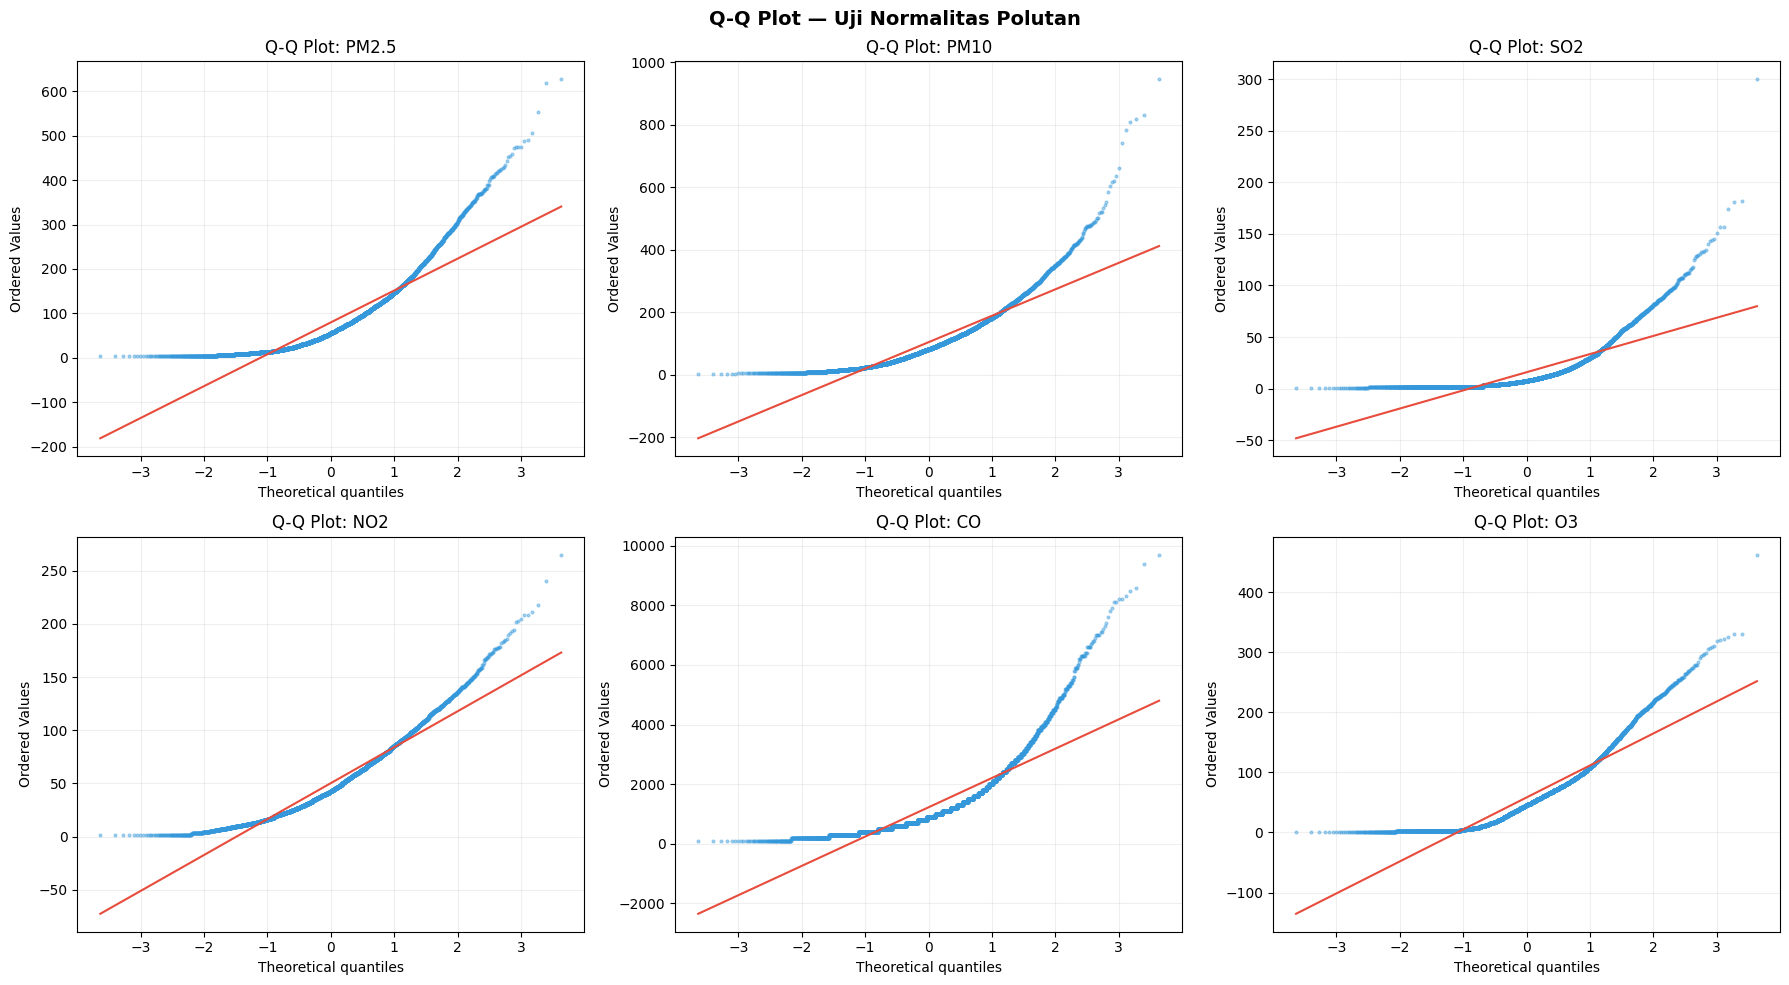


Normality Testing — Shapiro-Wilk (sample n=500):
  Variabel         W-stat      p-value Normal?        
  ────────────────────────────────────────────────────
  PM2.5            0.8098     0.000000 Tidak
  PM10             0.8434     0.000000 Tidak
  SO2              0.6692     0.000000 Tidak
  NO2              0.9138     0.000000 Tidak
  CO               0.7455     0.000000 Tidak
  O3               0.8608     0.000000 Tidak
  TEMP             0.9644     0.000000 Tidak
  WSPM             0.8980     0.000000 Tidak

Variance & Standard Deviation PM2.5 per Stasiun:
               Std Dev  Variance   Mean  CV (%)
station                                        
Nongzhanguan     86.69   7515.59  85.08   101.9
Dongsi           86.26   7440.83  86.14   100.1
Wanshouxigong    86.00   7395.95  85.07   101.1
Gucheng          82.99   6888.11  84.07    98.7
Wanliu           82.13   6744.53  83.47    98.4
Aotizhongxin     81.96   6716.85  82.54    99.3
Shunyi           81.50   6642.30  79.44   102.

In [58]:
# 3. Diagram tambahan NUMERIKAL

print("\n" + "=" * 60)
print("  Diagram tambahan NUMERIKAL")
print("=" * 60)

# 3a. Percentile Analysis
print("\nPercentile Analysis — Polutan Utama (PM2.5, NO2, SO2):")
pct_levels = [5, 10, 25, 50, 75, 90, 95, 99]
for col in ['PM2.5', 'NO2', 'SO2']:
    data = df_all[col].dropna()
    pcts = np.percentile(data, pct_levels)
    print(f"\n  {col}:")
    for lvl, val in zip(pct_levels, pcts):
        print(f"    P{lvl:>2}: {val:>8.2f} µg/m³")

# 3b. Q-Q Plot (Normality Check) 
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Q-Q Plot — Uji Normalitas Polutan", fontsize=14, fontweight='bold')

for ax, col in zip(axes.flatten(), POLLUTANTS):
    data = df_all[col].dropna().sample(min(5000, len(df_all)), random_state=42)
    stats.probplot(data, dist="norm", plot=ax)
    ax.set_title(f"Q-Q Plot: {col}")
    ax.get_lines()[0].set(markersize=2, alpha=0.4, color='#3498db')
    ax.get_lines()[1].set(color='#e74c3c', linewidth=1.5)
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

# 3c. Normality Testing (Shapiro-Wilk)
print("\nNormality Testing — Shapiro-Wilk (sample n=500):")
print(f"  {'Variabel':<12} {'W-stat':>10} {'p-value':>12} {'Normal?':<15}")
print("  " + "─" * 52)

for col in POLLUTANTS + ['TEMP', 'WSPM']:
    sample = df_all[col].dropna().sample(500, random_state=42)
    stat, p = shapiro(sample)
    normal = "Ya" if p > 0.05 else "Tidak"
    print(f"  {col:<12} {stat:>10.4f} {p:>12.6f} {normal}")

# 3d. Variance & Std per Stasiun 
print("\nVariance & Standard Deviation PM2.5 per Stasiun:")
var_stats = df_all.groupby('station')['PM2.5'].agg(['std','var','mean']).round(2)
var_stats['CV(%)'] = (var_stats['std'] / var_stats['mean'] * 100).round(1)
var_stats.columns = ['Std Dev', 'Variance', 'Mean', 'CV (%)']
print(var_stats.sort_values('Std Dev', ascending=False).to_string())

# 3e. Outlier Detection — IQR & Z-Score
print("\nOutlier Detection (IQR Method) — Polutan Utama:")
print(f"  {'Variabel':<12} {'Q1':>8} {'Q3':>8} {'IQR':>8} {'Lower':>8} {'Upper':>8} {'Outliers':>10} {'%':>6}")
print("  " + "─" * 75)

for col in POLLUTANTS:
    data = df_all[col].dropna()
    Q1, Q3 = data.quantile(0.25), data.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((data < lower) | (data > upper)).sum()
    pct   = n_out / len(data) * 100
    print(f"  {col:<12} {Q1:>8.2f} {Q3:>8.2f} {IQR:>8.2f} {lower:>8.2f} {upper:>8.2f} {n_out:>10,} {pct:>6.2f}%")



  Diagram tambahan KATEGORIKAL


C:\Users\melvi\AppData\Local\Temp\ipykernel_24064\1006575481.py:63: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(tier_count.index, rotation=15, ha='right')


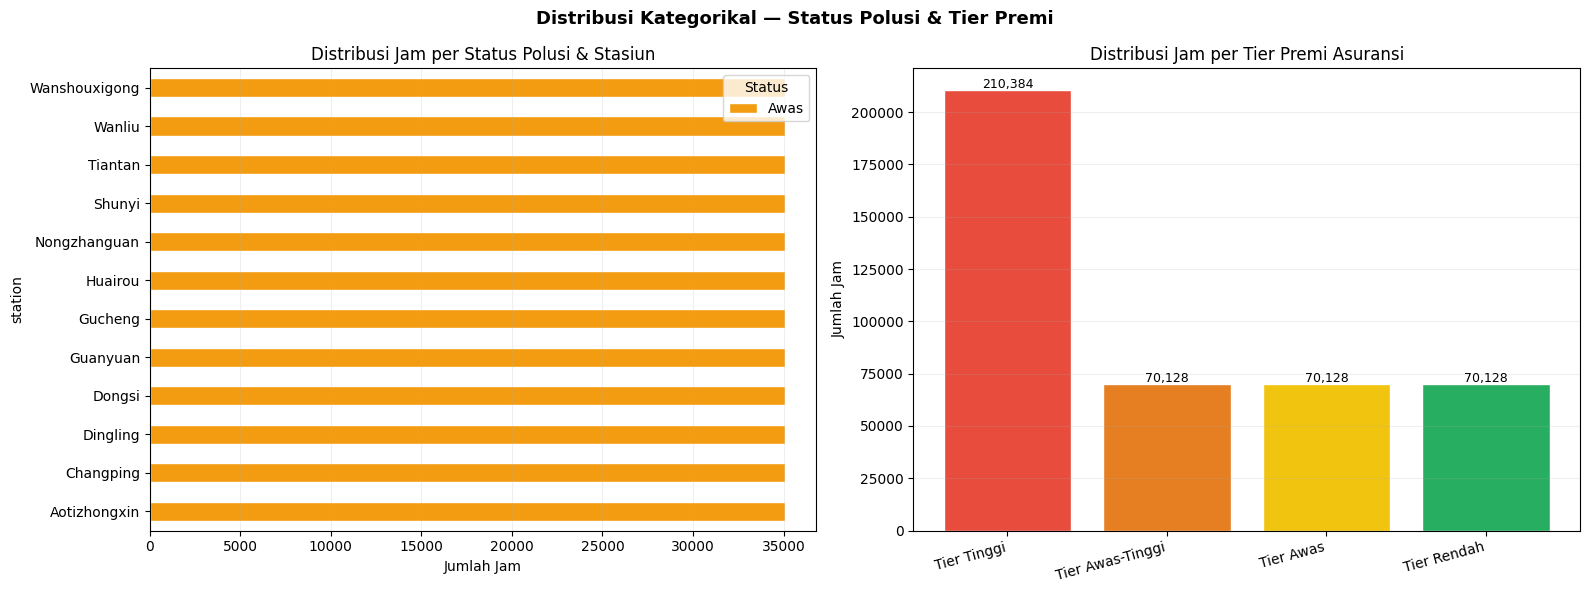

C:\Users\melvi\AppData\Local\Temp\ipykernel_24064\1006575481.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_cat, x='Status_Polusi', y='PM2.5',
C:\Users\melvi\AppData\Local\Temp\ipykernel_24064\1006575481.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_cat, x='Tier_Premi', y='NO2',
C:\Users\melvi\AppData\Local\Temp\ipykernel_24064\1006575481.py:83: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(tier_order, rotation=15, ha='right', fontsize=8)


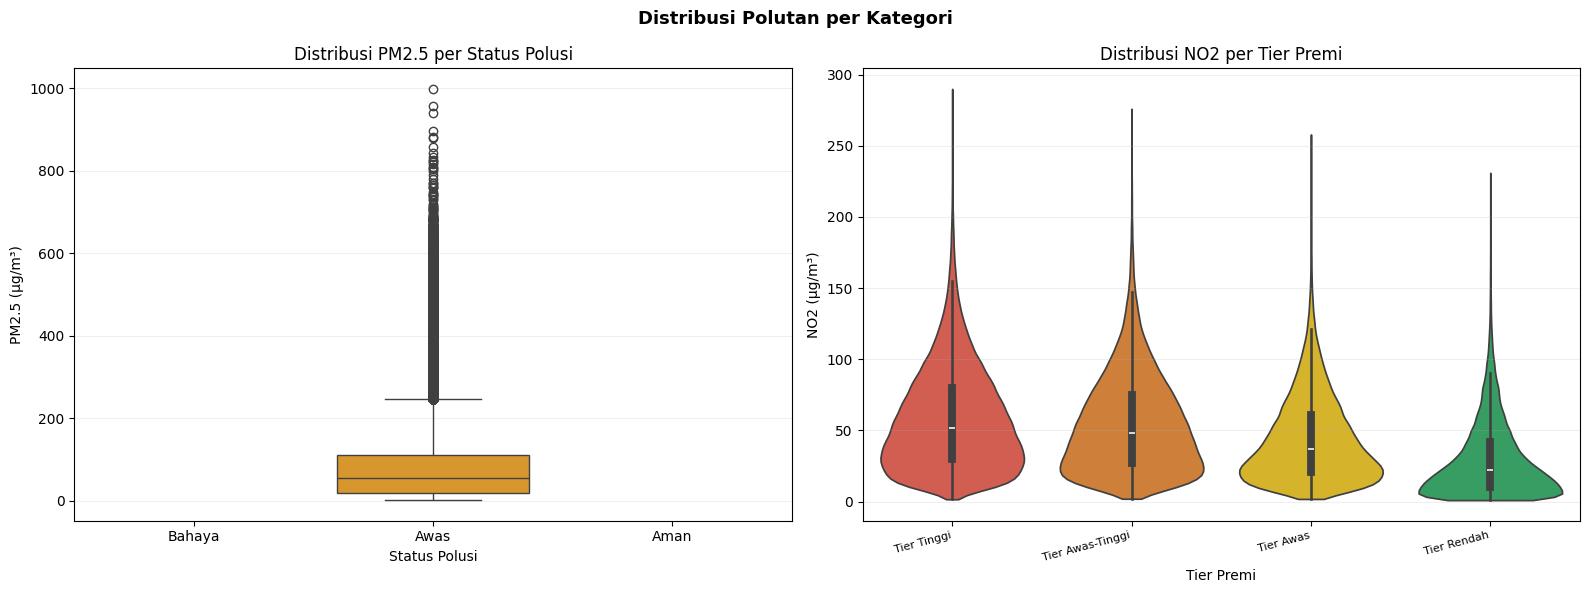


ANOVA Test — Perbedan Rata-rata PM2.5 antar Stasiun:
  F-statistic : 245.4369
  p-value     : 0.000000
  Kesimpulan  : Terdapat Perbedan signifikan antar stasiun (p < 0.05)

ANOVA Test — Perbedan Rata-rata NO2 antar Tier Premi:
  F-statistic : 14077.8984
  p-value     : 0.000000
  Kesimpulan  : Perbedan NO2 antar tier premi signifikan (p < 0.05)


In [59]:
# 4. Diagram tambahan KATEGORIKAL

print("\n" + "=" * 60)
print("  Diagram tambahan KATEGORIKAL")
print("=" * 60)

# Siapkan kolom kategori
df_cat = df_all.copy()

# Klasifikasi status polusi
def classify_zone(val):
    if val >= 100: return 'Bahaya'
    elif val >= 60: return 'Awas'
    else: return 'Aman'

station_avg_pm25 = df_cat.groupby('station')['PM2.5'].mean()
station_status   = station_avg_pm25.apply(classify_zone).to_dict()
df_cat['Status_Polusi'] = df_cat['station'].map(station_status)

# Tier premi
so2_no2_stats = df_cat.groupby('station')[['SO2','NO2']].mean()
so2_n = (so2_no2_stats['SO2'] - so2_no2_stats['SO2'].min()) / \
        (so2_no2_stats['SO2'].max() - so2_no2_stats['SO2'].min())
no2_n = (so2_no2_stats['NO2'] - so2_no2_stats['NO2'].min()) / \
        (so2_no2_stats['NO2'].max() - so2_no2_stats['NO2'].min())
risk_idx = (so2_n * 0.6 + no2_n * 0.4) * 100

def get_tier(score):
    if score >= 75:   return 'Tier Tinggi'
    elif score >= 50: return 'Tier Awas-Tinggi'
    elif score >= 25: return 'Tier Awas'
    else:             return 'Tier Rendah'

tier_map = risk_idx.apply(get_tier).to_dict()
df_cat['Tier_Premi'] = df_cat['station'].map(tier_map)

# 4a. Countplot Status Polusi per Stasiun
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Distribusi Kategorikal — Status Polusi & Tier Premi", fontsize=13, fontweight='bold')

status_order = ['Bahaya', 'Awas', 'Aman']
status_colors = {'Bahaya':'#e74c3c', 'Awas':'#f39c12', 'Aman':'#27ae60'}
status_count = df_cat.groupby(['station','Status_Polusi']).size().unstack(fill_value=0)
status_count = status_count.reindex(columns=[c for c in status_order if c in status_count.columns])
status_count.plot(kind='barh', ax=axes[0],
                  color=[status_colors[c] for c in status_count.columns],
                  edgecolor='white')
axes[0].set_title("Distribusi Jam per Status Polusi & Stasiun")
axes[0].set_xlabel("Jumlah Jam"); axes[0].legend(title='Status')
axes[0].grid(axis='x', alpha=0.2)

tier_order = ['Tier Tinggi','Tier Awas-Tinggi','Tier Awas','Tier Rendah']
tier_colors = {'Tier Tinggi':'#e74c3c','Tier Awas-Tinggi':'#e67e22',
               'Tier Awas':'#f1c40f','Tier Rendah':'#27ae60'}
tier_count = df_cat['Tier_Premi'].value_counts().reindex(tier_order, fill_value=0)
bars = axes[1].bar(tier_count.index, tier_count.values,
                   color=[tier_colors[t] for t in tier_count.index], edgecolor='white')
for bar, val in zip(bars, tier_count.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
                 f'{val:,}', ha='center', fontsize=9)
axes[1].set_title("Distribusi Jam per Tier Premi Asuransi")
axes[1].set_ylabel("Jumlah Jam")
axes[1].set_xticklabels(tier_count.index, rotation=15, ha='right')
axes[1].grid(axis='y', alpha=0.2)

plt.tight_layout()
plt.show()

# 4b. Boxplot PM2.5 per Status Polusi
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Distribusi Polutan per Kategori", fontsize=13, fontweight='bold')

sns.boxplot(data=df_cat, x='Status_Polusi', y='PM2.5',
            order=status_order, palette=status_colors, ax=axes[0])
axes[0].set_title("Distribusi PM2.5 per Status Polusi")
axes[0].set_xlabel("Status Polusi"); axes[0].set_ylabel("PM2.5 (µg/m³)")
axes[0].grid(axis='y', alpha=0.2)

sns.violinplot(data=df_cat, x='Tier_Premi', y='NO2',
               order=tier_order, palette=tier_colors, ax=axes[1], cut=0)
axes[1].set_title("Distribusi NO2 per Tier Premi")
axes[1].set_xlabel("Tier Premi"); axes[1].set_ylabel("NO2 (µg/m³)")
axes[1].set_xticklabels(tier_order, rotation=15, ha='right', fontsize=8)
axes[1].grid(axis='y', alpha=0.2)

plt.tight_layout()
plt.show()

# 4c. ANOVA Test — PM2.5 antar stasiun
print("\nANOVA Test — Perbedan Rata-rata PM2.5 antar Stasiun:")
groups = [df_cat[df_cat['station'] == s]['PM2.5'].dropna().values
          for s in df_cat['station'].unique()]
f_stat, p_val = f_oneway(*groups)
print(f"  F-statistic : {f_stat:.4f}")
print(f"  p-value     : {p_val:.6f}")
print(f"  Kesimpulan  : {'Terdapat Perbedan signifikan antar stasiun (p < 0.05)' if p_val < 0.05 else 'Tidak ada Perbedan signifikan'}")

# ANOVA antar Tier Premi
print("\nANOVA Test — Perbedan Rata-rata NO2 antar Tier Premi:")
tier_groups = [df_cat[df_cat['Tier_Premi'] == t]['NO2'].dropna().values
               for t in tier_order if t in df_cat['Tier_Premi'].unique()]
f_tier, p_tier = f_oneway(*tier_groups)
print(f"  F-statistic : {f_tier:.4f}")
print(f"  p-value     : {p_tier:.6f}")
print(f"  Kesimpulan  : {'Perbedan NO2 antar tier premi signifikan (p < 0.05)' if p_tier < 0.05 else 'Tidak signifikan'}")

## Analisis Lanjutan (Opsional)

1 : RFM-style Analysis: <br>
(Recency spike, Frequency lonjakan, Magnitude polutan) <br>
2 : Clustering Manual Grouping: <br>
(Pengelompokan stasiun berdasarkan tingkat polusi) <br>
3 : Geospatial Analysis: : <br>
(Peta distribusi polusi per stasiun — Folium) <br>
4 : Clustering Binning: <br>
(Kategorisasi level PM2.5 / AQI ke interval) <br>

In [60]:
warnings.filterwarnings('ignore')

# Output directory
OUTPUT_DIR = "./output_analisis_lanjutan"
PLOT_DIR   = os.path.join(OUTPUT_DIR, "plots")
MAP_DIR    = os.path.join(OUTPUT_DIR, "maps")
os.makedirs(PLOT_DIR, exist_ok=True)
os.makedirs(MAP_DIR,  exist_ok=True)

plt.rcParams.update({
    'figure.dpi'       : 150,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'font.size'        : 10,
})

# Koordinat geografis 12 stasiun Beijing
STATION_COORDS = {
    'Aotizhongxin' : (39.9824, 116.3976),
    'Changping'    : (40.2149, 116.2310),
    'Dingling'     : (40.2900, 116.2200),
    'Dongsi'       : (39.9290, 116.4170),
    'Guanyuan'     : (39.9290, 116.3390),
    'Gucheng'      : (39.9140, 116.1840),
    'Huairou'      : (40.3280, 116.6280),
    'Nongzhanguan' : (39.9370, 116.4610),
    'Shunyi'       : (40.1270, 116.6550),
    'Tiantan'      : (39.8860, 116.4070),
    'Wanliu'       : (39.9870, 116.2870),
    'Wanshouxigong': (39.8780, 116.3520),
}


# Opsional 1 — RFM-STYLE ANALYSIS
* Recency  : Hari sejak terakhir kali terjadi spike polutan
* Frequency: Jumlah hari dalam setahun terjadi spike PM2.5
* Magnitude: Rata-rata konsentrasi PM2.5 saat spike

In [61]:
# Analisis RFM-Style untuk data kualitas udara:
#   - Recency   : Hari sejak kejadian spike terakhir per stasiun
#   - Frequency : Jumlah hari (unik) terjadi spike PM2.5 > 150 µg/m³
#   - Magnitude : Rata-rata PM2.5 ketika spike terjadi
#   Threshold spike PM2.5 > 150 µg/m³ (kategori Tidak Sehat, WHO)

# Definisi fungsi untuk melakukan analisis RFM-Style
def modul1_rfm_analysis(df):
    """
    Analisis RFM-Style untuk data kualitas udara
    """
    SPIKE_THRESHOLD = 150  # µg/m³

    df = df.copy()
    df['datetime'] = pd.to_datetime(df[['year', 'month', 'day', 'hour']])
    df['date']     = df['datetime'].dt.date

    # Tandai baris spike
    df['is_spike'] = df['PM2.5'] > SPIKE_THRESHOLD
    spike_df       = df[df['is_spike']].copy()

    # Tanggal referensi = tanggal terakhir di dataset
    reference_date = pd.to_datetime(df['date'].max())

    rfm_list = []
    for station, grp in spike_df.groupby('station'):
        last_spike  = pd.to_datetime(grp['date'].max())
        recency     = (reference_date - last_spike).days
        frequency   = grp['date'].nunique()        # hari unik terjadi spike
        magnitude   = grp['PM2.5'].mean().round(2) # rata-rata PM2.5 saat spike

        rfm_list.append({
            'station': station,
            'Recency': recency,    # makin kecil = makin berbahaya
            'Frequency': frequency,
            'Magnitude': magnitude,
        })

    rfm = pd.DataFrame(rfm_list).set_index('station')

    # Scoring 1–3 per dimensi
    # Recency  : kecil = berbahaya → skor tinggi
    r_bins = pd.qcut(rfm['Recency'],   q=3, labels=False, duplicates='drop')
    f_bins = pd.qcut(rfm['Frequency'], q=3, labels=False, duplicates='drop')
    m_bins = pd.qcut(rfm['Magnitude'], q=3, labels=False, duplicates='drop')

    # Recency dibalik: bin rendah (recency kecil) → skor tinggi
    rfm['R_score'] = (r_bins.max() - r_bins + 1).astype(int)
    rfm['F_score'] = (f_bins + 1).astype(int)
    rfm['M_score'] = (m_bins + 1).astype(int)

    rfm['RFM_Total'] = rfm['R_score'] + rfm['F_score'] + rfm['M_score']

    # Segmentasi
    def rfm_segment(score):
        if score >= 8:
            return 'Zona Kritis'
        elif score >= 6:
            return 'Zona Berbahaya'
        elif score >= 4:
            return 'Zona Waspada'
        else:
            return 'Zona Aman'

    rfm['Segment'] = rfm['RFM_Total'].apply(rfm_segment)
    rfm_sorted = rfm.sort_values('RFM_Total', ascending=False)

    print("\n  Hasil RFM Analysis per Stasiun:")
    print(f"\n  {'Stasiun':<20} {'Recency':>8} {'Freq':>6} {'Magnitude':>10} "
          f"{'R':>3} {'F':>3} {'M':>3} {'Total':>6}  Segment")
    print("  " + "-" * 78)
    for st, row in rfm_sorted.iterrows():
        print(f"  {st:<20} {row['Recency']:>8} {row['Frequency']:>6} "
              f"{row['Magnitude']:>10.1f} {row['R_score']:>3} {row['F_score']:>3} "
              f"{row['M_score']:>3} {row['RFM_Total']:>6}  {row['Segment']}")

    # Visualisasi
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle("RFM-Style Analysis — Risiko Polusi PM2.5 per Stasiun",
              fontsize=13, fontweight='bold')

    color_map = {
        'Zona Kritis'   : '#e74c3c',
        'Zona Berbahaya': '#e67e22',
        'Zona Waspada'  : '#f1c40f',
        'Zona Aman'     : '#27ae60',
    }
    colors = [color_map[rfm_sorted.loc[s, 'Segment']] for s in rfm_sorted.index]

    metrics = [('Recency (hari)', 'Recency'), ('Frequency (hari spike)', 'Frequency'),
              ('Magnitude (µg/m³)', 'Magnitude')]
    for ax, (label, col) in zip(axes, metrics):
        ax.barh(rfm_sorted.index, rfm_sorted[col], color=colors)
        ax.set_title(label)
        ax.invert_yaxis()
        ax.grid(alpha=0.25)

    # Legend
    handles = [mpatches.Patch(color=c, label=l) for l, c in color_map.items()]
    fig.legend(handles=handles, loc='lower center', ncol=4, fontsize=9,
             bbox_to_anchor=(0.5, -0.04))

    plt.tight_layout()
    path = os.path.join(PLOT_DIR, "M1_rfm_analysis.png")
    plt.savefig(path, bbox_inches='tight')
    plt.show()
    print(f"\n  Plot disimpan: {path}")

    return rfm


# Opsional 2 — CLUSTERING MANUAL GROUPING
* Pengelompokan stasiun berdasarkan aturan domain / bisnis


  Hasil Manual Grouping per Stasiun:

  Stasiun                PM2.5     NO2     SO2  Klaster
  ───────────────────────────────────────────────────────────────────────────
  Dongsi                  86.1    54.0    18.5  Klaster B — Polusi Sedang (Urban Menengah)
  Nongzhanguan            85.1    58.1    18.8  Klaster B — Polusi Sedang (Urban Menengah)
  Wanshouxigong           85.1    55.5    17.4  Klaster B — Polusi Sedang (Urban Menengah)
  Gucheng                 84.1    55.8    15.7  Klaster B — Polusi Sedang (Urban Menengah)
  Wanliu                  83.5    65.7    18.4  Klaster A — Polusi Tinggi (Urban Padat)
  Guanyuan                82.9    58.1    17.6  Klaster B — Polusi Sedang (Urban Menengah)
  Aotizhongxin            82.5    59.1    17.5  Klaster B — Polusi Sedang (Urban Menengah)
  Tiantan                 82.0    53.3    14.5  Klaster B — Polusi Sedang (Urban Menengah)
  Shunyi                  79.4    44.1    13.4  Klaster C — Polusi Rendah-Sedang (Suburban)
  Changpin

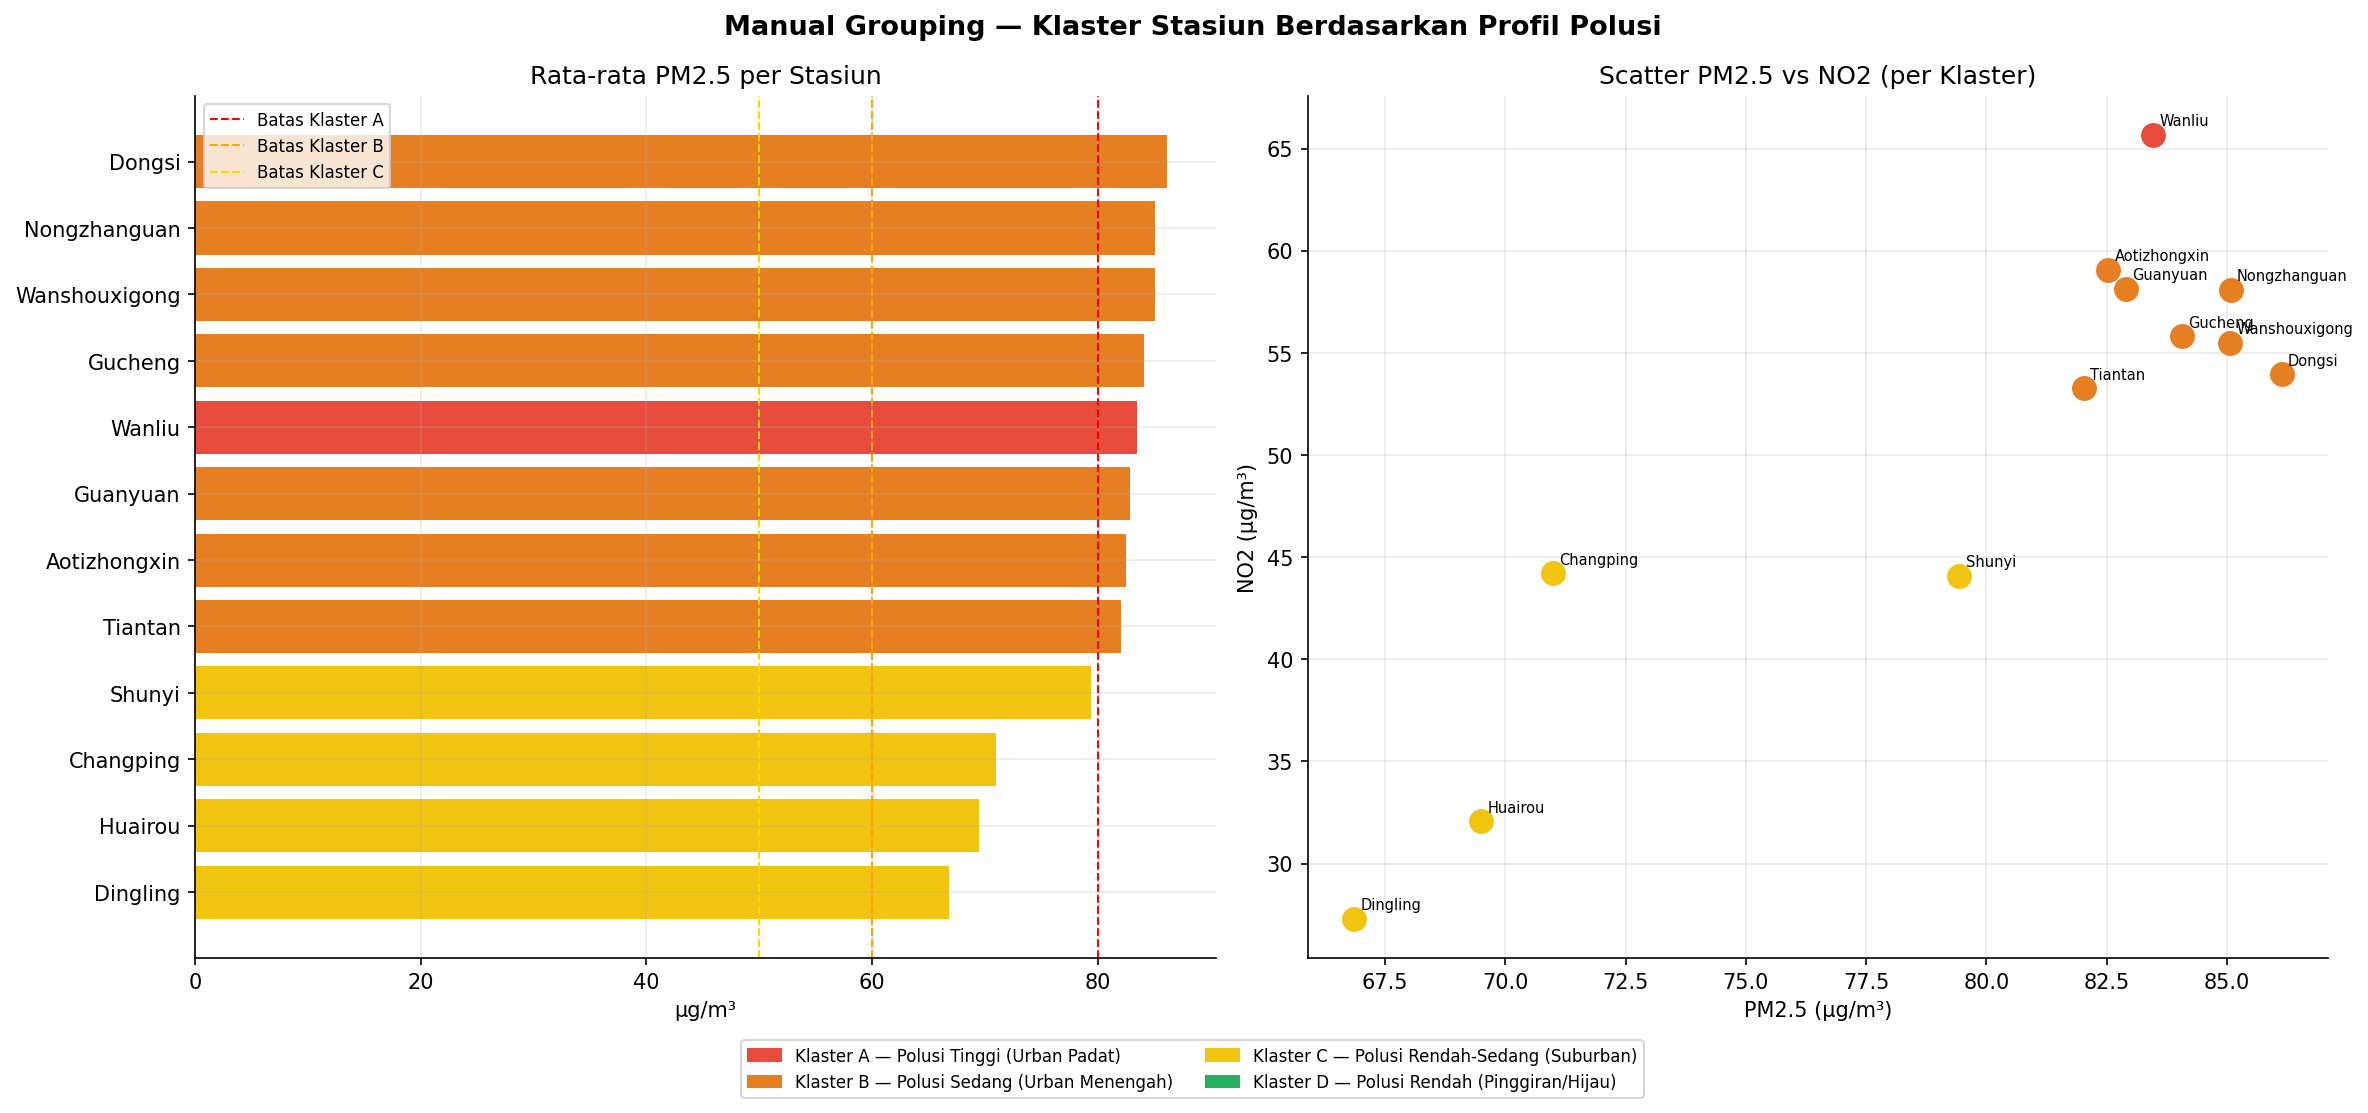


  Plot disimpan: ./output_analisis_lanjutan\plots\M2_manual_grouping.png


In [62]:
"""
Mengelompokkan stasiun ke dalam klaster berdasarkan kriteria domain / aturan bisnis:
  Profil PM2.5 (mean) × Profil NO2 (mean) × Lokasi (urban/suburban/rural)
"""
# Profil rata-rata per stasiun
# Membuatkan dataframe yang berisi profil rata-rata per stasiun
profile = df_all.groupby('station').agg(
    PM25_mean = ('PM2.5', 'mean'),  # Nilai rata-rata PM2.5 per stasiun
    PM10_mean = ('PM10', 'mean'),  # Nilai rata-rata PM10 per stasiun
    NO2_mean  = ('NO2',  'mean'),  # Nilai rata-rata NO2 per stasiun
    SO2_mean  = ('SO2',  'mean'),  # Nilai rata-rata SO2 per stasiun
    CO_mean   = ('CO',   'mean'),  # Nilai rata-rata CO per stasiun
    O3_mean   = ('O3',   'mean'),  # Nilai rata-rata O3 per stasiun
).round(2)

# Aturan pengelompokan (domain knowledge)
# Berdasarkan WHO annual guideline PM2.5 = 5 µg/m³
# Fungsi untuk mengelompokkan stasiun berdasarkan kriteria domain / aturan bisnis
def assign_group(row):
    """
    Mengelompokkan stasiun berdasarkan kriteria domain / aturan bisnis
    """
    pm25 = row['PM25_mean']
    no2  = row['NO2_mean']
    if pm25 > 80 and no2 > 60:
        # Klaster A — Polusi Tinggi (Urban Padat)
        return 'Klaster A — Polusi Tinggi (Urban Padat)'
    elif pm25 > 60 and no2 > 45:
        # Klaster B — Polusi Sedang (Urban Menengah)
        return 'Klaster B — Polusi Sedang (Urban Menengah)'
    elif pm25 > 50:
        # Klaster C — Polusi Rendah-SDiagram tambahanng (Suburban)
        return 'Klaster C — Polusi Rendah-Sedang (Suburban)'
    else:
        # Klaster D — Polusi Rendah (Pinggiran/Hijau)
        return 'Klaster D — Polusi Rendah (Pinggiran/Hijau)'

# Mengelompokkan stasiun berdasarkan kriteria domain / aturan bisnis
profile['Klaster'] = profile.apply(assign_group, axis=1)
profile_sorted = profile.sort_values('PM25_mean', ascending=False)

print("\n  Hasil Manual Grouping per Stasiun:")
print(f"\n  {'Stasiun':<20} {'PM2.5':>7} {'NO2':>7} {'SO2':>7}  Klaster")
print("  " + "─" * 75)
for st, row in profile_sorted.iterrows():
    print(f"  {st:<20} {row['PM25_mean']:>7.1f} {row['NO2_mean']:>7.1f} "
  f"{row['SO2_mean']:>7.1f}  {row['Klaster']}")

print("\n  Ringkasan per Klaster:")
# Membuatkan ringkasan per klaster
for klaster, grp in profile.groupby('Klaster'):
    members = grp.index.tolist()
    print(f"\n  {klaster}")
    print(f"    Stasiun : {', '.join(members)}")
    print(f"    PM2.5   : {grp['PM25_mean'].mean():.1f} µg/m³")
    print(f"    NO2     : {grp['NO2_mean'].mean():.1f} µg/m³")

# Visualisasi
klaster_colors = {
    'Klaster A — Polusi Tinggi (Urban Padat)'      : '#e74c3c',
    'Klaster B — Polusi Sedang (Urban Menengah)'   : '#e67e22',
    'Klaster C — Polusi Rendah-Sedang (Suburban)'  : '#f1c40f',
    'Klaster D — Polusi Rendah (Pinggiran/Hijau)'  : '#27ae60',
}
colors = [klaster_colors[profile_sorted.loc[s, 'Klaster']]
for s in profile_sorted.index]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("Manual Grouping — Klaster Stasiun Berdasarkan Profil Polusi",
     fontsize=13, fontweight='bold')

# Bar PM2.5
axes[0].barh(profile_sorted.index, profile_sorted['PM25_mean'], color=colors)
axes[0].set_title("Rata-rata PM2.5 per Stasiun")
axes[0].set_xlabel("µg/m³")
axes[0].axvline(x=80, color='red',    linestyle='--',linewidth=1, label='Batas Klaster A')
axes[0].axvline(x=60, color='orange', linestyle='--',linewidth=1, label='Batas Klaster B')
axes[0].axvline(x=50, color='gold',   linestyle='--',linewidth=1, label='Batas Klaster C')
axes[0].legend(fontsize=8)
axes[0].invert_yaxis()
axes[0].grid(alpha=0.25)

# Scatter PM2.5 vs NO2
for st, row in profile.iterrows():
    c = klaster_colors[row['Klaster']]
    axes[1].scatter(row['PM25_mean'], row['NO2_mean'], color=c, s=120, zorder=3)
    axes[1].annotate(st, (row['PM25_mean'], row['NO2_mean']),
            fontsize=7, ha='left', va='bottom',
            xytext=(3, 3), textcoords='offset points')
axes[1].set_xlabel("PM2.5 (µg/m³)")
axes[1].set_ylabel("NO2 (µg/m³)")
axes[1].set_title("Scatter PM2.5 vs NO2 (per Klaster)")
axes[1].grid(alpha=0.25)

handles = [mpatches.Patch(color=c, label=l) for l, c in klaster_colors.items()]
fig.legend(handles=handles, loc='lower center', ncol=2, fontsize=8,
   bbox_to_anchor=(0.5, -0.06))

plt.tight_layout()
path = os.path.join(PLOT_DIR, "M2_manual_grouping.png")
plt.savefig(path, bbox_inches='tight')
plt.show()
print(f"\n  Plot disimpan: {path}")


# Opsional 3 — GEOSPATIAL ANALYSIS
* Peta interaktif distribusi polusi per stasiun (Folium)


  Peta interaktif disimpan: ./output_analisis_lanjutan\maps\M3_geospatial_pm25.html
     Buka file .html di browser untuk melihat peta


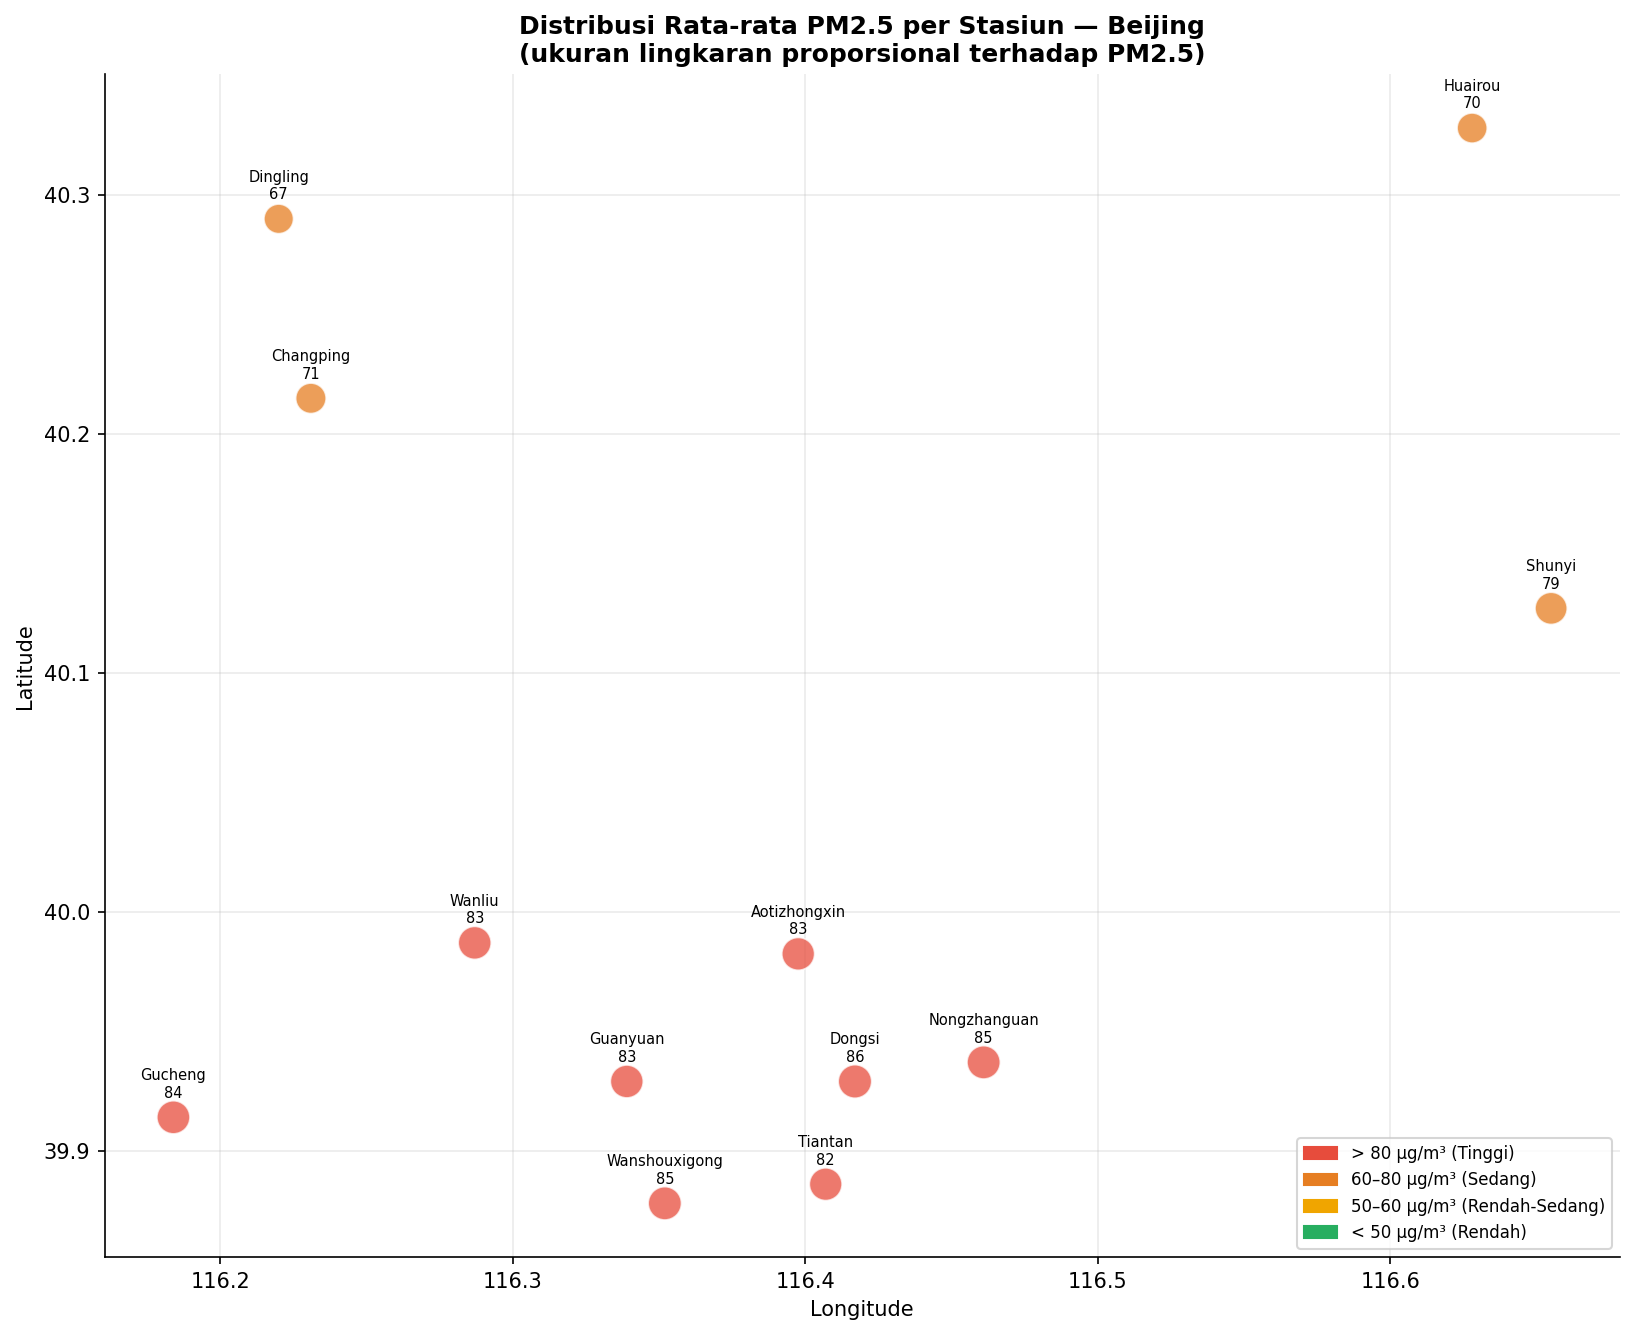

  Plot static disimpan: ./output_analisis_lanjutan\plots\M3_geospatial_static.png


In [63]:
# Fungsi untuk membuat peta interaktif berbasis data stasiun
# dengan fitur:
# 1. Marker per stasiun + popup info polusi
# 2. Heatmap distribusi PM2.5
# 3. Circle radius proporsional terhadap rata-rata PM2.5

def modul3_geospatial(df, coords):
    """
    Membuat peta interaktif berbasis data stasiun
    dengan fitur:
    1. Marker per stasiun + popup info polusi
    2. Heatmap distribusi PM2.5
    3. Circle radius proporsional terhadap rata-rata PM2.5
    """
    # Profil rata-rata per stasiun
    station_avg = df.groupby('station').agg(
        PM25=('PM2.5', 'mean'),
        PM10=('PM10', 'mean'),
        NO2=('NO2', 'mean'),
        SO2=('SO2', 'mean'),
        CO=('CO', 'mean'),
        O3=('O3', 'mean'),
    ).round(2)

    # Warna marker berdasarkan PM2.5
    def marker_color(pm25):
        if pm25 > 80:
            return 'red'
        elif pm25 > 60:
            return 'orange'
        elif pm25 > 50:
            return 'beige'
        else:
            return 'green'

    # Buat peta dasar
    center = [39.95, 116.39]
    m = folium.Map(location=center, zoom_start=10,
           tiles='CartoDBpositron')

    # Layer 1: Circle marker proporsional
    for station, row in station_avg.iterrows():
        if station not in coords:
            continue
        lat, lon = coords[station]
        color    = marker_color(row['PM25'])
        radius   = row['PM25'] * 0.4  # proporsional

        folium.CircleMarker(
            location=[lat, lon],
            radius=radius,
            color=color,
            fill=True,
            fill_color=color,
            fill_opacity=0.45,
            weight=1.5,
        ).add_to(m)

        # Layer 2: Marker dengan popup detail
        popup_html = f"""
        <div style="font-family:Arial; font-size:12px; width:200px">
          <b style="font-size:14px">{station}</b><hr>
          <table>
            <tr><td>PM2.5</td><td><b>{row['PM25']} µg/m³</b></td></tr>
            <tr><td>PM10 </td><td>{row['PM10']} µg/m³</td></tr>
            <tr><td>NO2  </td><td>{row['NO2']} µg/m³</td></tr>
            <tr><td>SO2  </td><td>{row['SO2']} µg/m³</td></tr>
            <tr><td>CO   </td><td>{row['CO']} µg/m³</td></tr>
            <tr><td>O3   </td><td>{row['O3']} µg/m³</td></tr>
          </table>
        </div>"""
        folium.Marker(
            location=[lat, lon],
            popup=folium.Popup(popup_html, max_width=220),
            tooltip=f"{station} | PM2.5: {row['PM25']:.0f} µg/m³",
            icon=folium.Icon(color=color, icon='cloud', prefix='fa'),
        ).add_to(m)

    # Layer 3: Heatmap PM2.5
    heat_data = [
        [coords[st][0], coords[st][1], station_avg.loc[st, 'PM25']]
        for st in station_avg.index if st in coords
    ]
    HeatMap(heat_data, radius=40, blur=25, min_opacity=0.3,
          gradient={0.4:'blue', 0.65:'lime', 0.85:'orange', 1.0:'red'}
    ).add_to(m)

    # Legend manual
    legend_html = """
    <div style="position:fixed; bottom:30px; left:30px; z-index:1000;
    background:white; padding:12px; border-radius:8px;
    border:1px solid #ccc; font-size:12px; font-family:Arial">
      <b>Tingkat PM2.5</b><br>
      <span style="color:#e74c3c">●</span> &gt; 80 µg/m³ — Polusi Tinggi<br>
      <span style="color:#e67e22">●</span> 60–80 µg/m³ — Polusi Sedang<br>
      <span style="color:#f0a500">●</span> 50–60 µg/m³ — Polusi Rendah-Sedang<br>
      <span style="color:#27ae60">●</span> &lt; 50 µg/m³ — Polusi Rendah
    </div>"""
    m.get_root().html.add_child(folium.Element(legend_html))

    # Simpan peta
    map_path = os.path.join(MAP_DIR, "M3_geospatial_pm25.html")
    m.save(map_path)
    print(f"\n  Peta interaktif disimpan: {map_path}")
    print("     Buka file .html di browser untuk melihat peta")

    # Static plot sebagai ringkasan
    lats   = [coords[s][0] for s in station_avg.index if s in coords]
    lons   = [coords[s][1] for s in station_avg.index if s in coords]
    pm25s  = [station_avg.loc[s, 'PM25'] for s in station_avg.index if s in coords]
    names  = [s for s in station_avg.index if s in coords]
    colors = [marker_color(p) for p in pm25s]
    color_fix = {'red':'#e74c3c','orange':'#e67e22','beige':'#f0a500','green':'#27ae60'}

    fig, ax = plt.subplots(figsize=(11, 9))
    sc = ax.scatter(lons, lats,
        s=[p * 3 for p in pm25s],
        c=[color_fix[c] for c in colors],
        alpha=0.75, zorder=3, edgecolors='white', linewidths=0.8)
    for i, name in enumerate(names):
        ax.annotate(f"{name}\n{pm25s[i]:.0f}", (lons[i], lats[i]),
              fontsize=7, ha='center', va='bottom',
              xytext=(0, 8), textcoords='offset points')

    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_title("Distribusi Rata-rata PM2.5 per Stasiun — Beijing\n(ukuran lingkaran proporsional terhadap PM2.5)",
          fontsize=12, fontweight='bold')
    ax.grid(alpha=0.25)

    handles = [
        mpatches.Patch(color='#e74c3c', label='> 80 µg/m³ (Tinggi)'),
        mpatches.Patch(color='#e67e22', label='60–80 µg/m³ (Sedang)'),
        mpatches.Patch(color='#f0a500', label='50–60 µg/m³ (Rendah-Sedang)'),
        mpatches.Patch(color='#27ae60', label='< 50 µg/m³ (Rendah)'),
    ]
    ax.legend(handles=handles, loc='lower right', fontsize=8)

    plt.tight_layout()
    static_path = os.path.join(PLOT_DIR, "M3_geospatial_static.png")
    plt.savefig(static_path, bbox_inches='tight')
    plt.show()
    print(f"  Plot static disimpan: {static_path}")

    return m

geo_map = modul3_geospatial(df_all, STATION_COORDS)



# Opsional 4 — CLUSTERING BINNING
* Kategorisasi level PM2.5 berdasarkan interval AQI



════════════════════════════════════════════════════════════
4: Clustering Binning
  Kategorisasi Level PM2.5 berdasarkan AQI Interval
════════════════════════════════════════════════════════════

  Distribusi Kategori AQI (Seluruh Dataset):

  Kategori                   Jumlah   Persentase
  ────────────────────────────────────────────────
  Good                       63,928       15.19%
  Moderate                   93,055       22.12%
  Sensitive Groups           54,482       12.95%
  Unhealthy                 145,447       34.57%
  Very Unhealthy             44,958       10.68%
  Hazardous                  18,898        4.49%

  % Kategori AQI per Stasiun (5 kolom pertama):
AQI_Category   Good  Moderate  Sensitive Groups  Unhealthy
station                                                   
Aotizhongxin   13.4      22.1              13.0       35.5
Changping      15.8      26.6              13.1       31.9
Dingling       22.6      23.7              12.6       29.2
Dongsi         14.

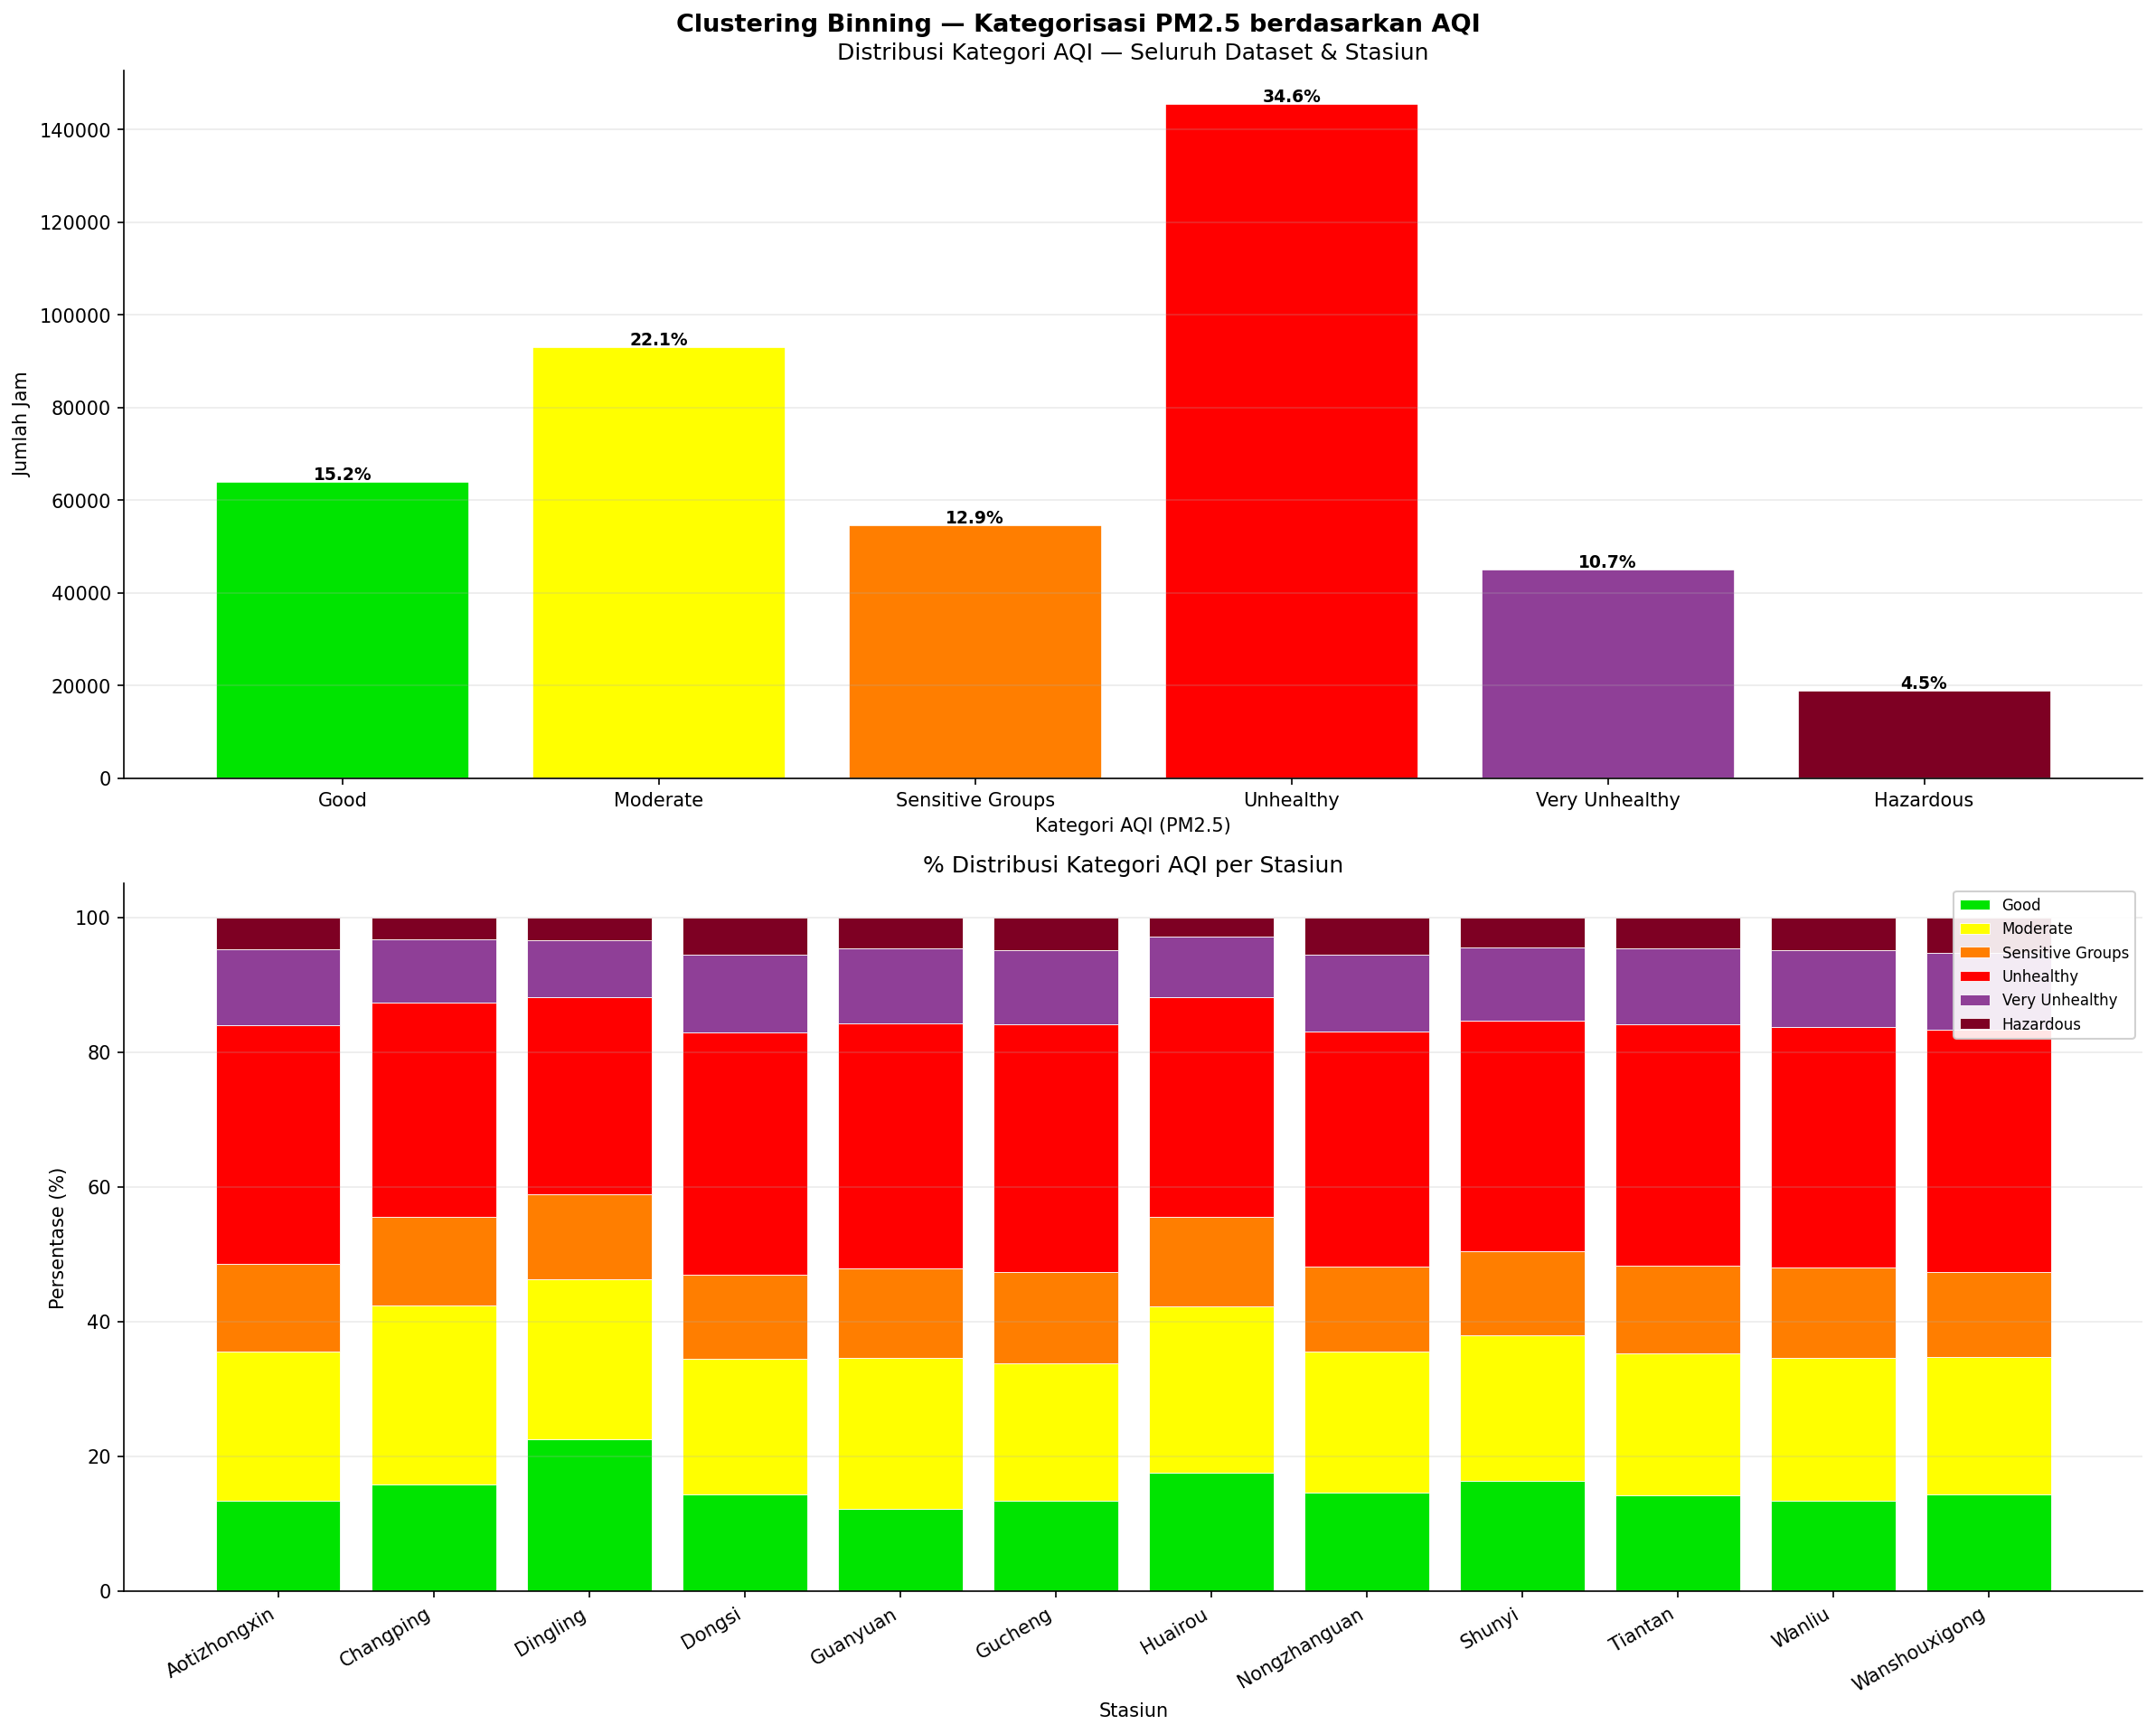


  Plot disimpan: ./output_analisis_lanjutan\plots\M4_binning_aqi.png


In [64]:
print("\n" + "═" * 60)
print("4: Clustering Binning")
print("  Kategorisasi Level PM2.5 berdasarkan AQI Interval")
print("═" * 60)

def modul4_binning(df):
    """
    Membagi konsentrasi PM2.5 ke dalam 6 kategori AQI
    menggunakan pd.cut() (binning), tanpa ML.

    Standar AQI US-EPA untuk PM2.5 (µg/m³ per 24 jam):
      0 – 12.0     : Good
      12.1 – 35.4  : Moderate
      35.5 – 55.4  : Unhealthy for Sensitive Groups
      55.5 – 150.4 : Unhealthy
      150.5 – 250.4: Very Unhealthy
      250.5+       : Hazardous
    """
    bins   = [0, 12, 35.4, 55.4, 150.4, 250.4, float('inf')]
    labels = ['Good', 'Moderate', 'Sensitive Groups',
  'Unhealthy', 'Very Unhealthy', 'Hazardous']
    aqi_colors = {
        'Good': '#00e400',
        'Moderate'        : '#ffff00',
        'Sensitive Groups': '#ff7e00',
        'Unhealthy'       : '#ff0000',
        'Very Unhealthy'  : '#8f3f97',
        'Hazardous'       : '#7e0023',
    }

    df = df.copy()
    df['AQI_Category'] = pd.cut(df['PM2.5'], bins=bins, labels=labels, right=True)

    # Distribusi global
    global_dist = df['AQI_Category'].value_counts().reindex(labels)
    global_pct  = (global_dist / global_dist.sum() * 100).round(2)

    print("\n  Distribusi Kategori AQI (Seluruh Dataset):")
    print(f"\n  {'Kategori':<22} {'Jumlah':>10} {'Persentase':>12}")
    print("  " + "─" * 48)
    for cat in labels:
        print(f"  {cat:<22} {global_dist[cat]:>10,} {global_pct[cat]:>11.2f}%")

    # Distribusi per stasiun
    station_dist = (
        df.groupby(['station', 'AQI_Category'], observed=True)
          .size()
          .unstack(fill_value=0)
          .reindex(columns=labels, fill_value=0)
    )
    station_pct = station_dist.div(station_dist.sum(axis=1), axis=0) * 100

    print("\n  % Kategori AQI per Stasiun (5 kolom pertama):")
    print(station_pct[labels[:4]].round(1).to_string())

    # Visualisasi
    fig, axes = plt.subplots(2, 1, figsize=(16, 13))
    fig.suptitle("Clustering Binning — Kategorisasi PM2.5 berdasarkan AQI",
     fontsize=13, fontweight='bold')

    # Plot 1: Distribusi global (pie + bar)
    bar_colors = [aqi_colors[l] for l in labels]
    axes[0].bar(labels, global_dist.values, color=bar_colors,
    edgecolor='white', linewidth=0.8)
    axes[0].set_title("Distribusi Kategori AQI — Seluruh Dataset & Stasiun")
    axes[0].set_ylabel("Jumlah Jam")
    axes[0].set_xlabel("Kategori AQI (PM2.5)")
    for i, (val, pct) in enumerate(zip(global_dist.values, global_pct.values)):
        axes[0].text(i, val + 500, f"{pct:.1f}%", ha='center', fontsize=9, fontweight='bold')
    axes[0].grid(axis='y', alpha=0.25)

    # Plot 2: Stacked bar per stasiun
    bottom = np.zeros(len(station_pct))
    for cat in labels:
        vals = station_pct[cat].values
        axes[1].bar(station_pct.index, vals, bottom=bottom,
        color=aqi_colors[cat], label=cat,
        edgecolor='white', linewidth=0.4)
        bottom += vals
    axes[1].set_title("% Distribusi Kategori AQI per Stasiun")
    axes[1].set_ylabel("Persentase (%)")
    axes[1].set_xlabel("Stasiun")
    axes[1].set_xticklabels(station_pct.index, rotation=30, ha='right')
    axes[1].legend(loc='upper right', fontsize=8, framealpha=0.9)
    axes[1].grid(axis='y', alpha=0.25)

    plt.tight_layout()
    path = os.path.join(PLOT_DIR, "M4_binning_aqi.png")
    plt.savefig(path, bbox_inches='tight')
    plt.show()
    print(f"\n  Plot disimpan: {path}")

    return df, station_pct


df_binned, aqi_by_station = modul4_binning(df_all)

## Conclusion

- Conclusion Pertanyaan 1
Bagaimana cara mengintegrasikan data historis konsentrasi PM2.5 dan PM10 ke dalam sistem manajemen lalu lintas untuk membatasi volume kendaraan di zona dengan tingkat polusi tinggi?<br>

Berdasarkan analisis klasifikasi zona polusi menggunakan rata-rata PM2.5 dan PM10 dari seluruh stasiun pemantauan (Maret 2013 – Februari 2017), ditemukan bahwa:<br>

- Gucheng adalah satu-satunya stasiun yang masuk 🔴 Zona Merah dengan rata-rata partikulat 101.67 µg/m³, melampaui ambang batas kritis (≥ 100 µg/m³).<br>
- Stasiun ini memerlukan kebijakan pembatasan kendaraan paling ketat, seperti sistem ganjil-genap dan larangan truk besar.<br>
- 11 stasiun lainnya (Wanshouxigong, Dongsi, Nongzhanguan, Wanliu, Aotizhongxin, Guanyuan, Tiantan, Shunyi, Changping, Huairou, Dingling) berada di 🟡 Zona Kuning (60–100 µg/m³), yang memerlukan pemantauan real-time dan kesiagaan pengalihan lalu lintas.<br>
- Analisis pola jam menunjukkan bahwa polusi paling tinggi terjadi pada jam 20.00 – 01.00 dini hari, yang merupakan waktu operasional kendaraan berat dan truk logistik. Pembatasan kendaraan berat pada jam-jam ini dapat menjadi intervensi paling efektif.<br>

Rekomendasi: Integrasikan data PM2.5 dan PM10 secara real-time ke sistem manajemen lalu lintas dengan ambang batas otomatis — ketika konsentrasi partikulat melebihi 100 µg/m³, sistem secara otomatis mengaktifkan kebijakan pembatasan kendaraan di zona tersebut.

- Conclusion Pertanyaan 2<br>
Bagaimana cara mengukur korelasi antara variabel meteorologi dan tingkat polusi udara untuk mengalihkan rute pengiriman guna menekan paparan polutan terhadap pekerja lapangan? <br>

Berdasarkan analisis matriks korelasi antara variabel meteorologi (TEMP, PRES, DEWP, RAIN, WSPM) dan polutan (PM2.5, PM10, SO2, NO2, CO, O3), ditemukan bahwa: <br>

- Kecepatan angin (WSPM) berkorelasi negatif signifikan dengan NO2 (r = -0.396), artinya semakin kencang angin, kadar NO2 semakin rendah karena terdispersi.
- WSPM juga menekan CO (r = -0.290) dan PM2.5 (r = -0.271). <br>
- Suhu (TEMP) berkorelasi negatif dengan SO2 (r = -0.320) dan CO (r = -0.324), namun positif kuat dengan O3 (r = 0.592) — suhu tinggi justru memicu pembentukan ozon. <br>
- Tekanan udara (PRES) berkorelasi negatif dengan O3 (r = -0.447), menunjukkan tekanan tinggi menekan konsentrasi ozon. <br>
- Analisis Risk Score per jam menunjukkan jam paling aman untuk pengiriman adalah pukul 12.00 – 16.00 (siang hari), ketika suhu tinggi dan angin aktif membantu mendispersi polutan. Sebaliknya, jam paling berisiko adalah pukul 20.00 – 01.00. <br>
- Dari sisi lokasi, Dingling (Risk Score: 158.4) dan Huairou (167.6) adalah rute paling aman, sementara Gucheng (473.4) dan Wanliu (356.3) adalah yang paling berbahaya bagi pekerja lapangan. <br>

Rekomendasi: Jadwalkan pengiriman pada pukul 12.00–16.00 dan prioritaskan rute melalui Dingling, Huairou, dan Changping. Pantau kondisi angin secara real-time — ketika WSPM < 1 m/s, tunda pengiriman ke zona Gucheng dan Wanliu, dan wajibkan APD pernapasan bagi pekerja di zona tersebut. <br>

- Conclusion Pertayaan 3 <br>
Bagaimana cara menganalisis fluktuasi SO2 dan NO2 untuk memodelkan potensi lonjakan klaim penyakit pernapasan dan merancang struktur premi berdasarkan lokasi pemukiman nasabah?<br>
Berdasarkan analisis statistik deskriptif, deteksi spike, dan pemodelan Risk Index SO2 & NO2 di 12 stasiun pemantauan, ditemukan bahwa:

- Wanliu mencatatkan frekuensi lonjakan polutan tertinggi dengan 4.277 kejadian spike (12.20%),diikuti Nongzhanguan (11.58%) dan Aotizhongxin (11.04%). Ketiga wilayah ini memiliki risiko klaim penyakit pernapasan yang paling tinggi secara konsisten. <br>
- Berdasarkan Risk Index gabungan SO2 (bobot 60%) dan NO2 (bobot 40%), terbentuk 4 tier premi:<br>
🔴 Tier Tinggi (Rp 1.000.000/bulan): Wanliu, Nongzhanguan, Dongsi, Guanyuan, Aotizhongxin, Wanshouxigong — Risk Index ≥ 75 <br>
🟠 Tier Sedang-Tinggi (Rp 750.000/bulan): Gucheng, Tiantan — Risk Index 50–75 <br>
🟡 Tier Sedanng (Rp 600.000/bulan): Changping, Shunyi — Risk Index 25–50 <br>
🟢 Tier Rendah (Rp 500.000/bulan): Huairou, Dingling — Risk Index < 25<br>

- Analisis tren bulanan menunjukkan musim dingin dan peralihan (Jan, Feb, Mar, Okt, Nov, Des) adalah periode risiko klaim tertinggi, yang berkorelasi dengan meningkatnya pembakaran bahan bakar untuk pemanas ruangan yang melepaskan SO2 dan NO2 lebih besar. <br>
- Dingling (Risk Index: 0.0) dan Huairou (10.6) adalah wilayah paling aman dengan konsentrasi SO2 dan NO2 terendah secara keseluruhan, sehingga layak mendapatkan premi paling rendah.

Rekomendasi: Terapkan struktur premi berbasis lokasi dengan 4 tier di atas, dan siapkan cadangan klaim 20–30% lebih besar pada bulan Oktober–Maret untuk mengantisipasi lonjakan klaim musiman penyakit pernapasan di wilayah-wilayah berisiko tinggi seperti Wanliu, Nongzhanguan, dan Aotizhongxin.